# Proyecto Aliados Frescos — Grupo 1
## La red que no logra seguirle el paso a la ciudad

Solución integral de optimización de la distribución de última milla, abordando los **cuatro frentes de decisión** del caso con los enfoques vistos en el curso:

| Frente | Problema | Enfoque |
|---|---|---|
| 1 | Optimización de recorridos | Simulated Annealing · A* · IDA* |
| 2 | Reasignación de zonas | Simulated Annealing (T alta, enfriamiento lento) |
| 3 | Reabastecimiento diario bajo incertidumbre | MDP · Policy Iteration |
| 4 | Política de inventario a largo plazo | Policy Iteration (sensibilidad y generalización) |

---
### 0. Configuración e importación de librerías

In [1]:
import numpy as np # Para operaciones matematicas
import pandas as pd # Para tablas (DataFrames)
import math # Funciones matematicas
import random # Generacion de numers aleatorios
import heapq # Cola de prioridad para A*
import time # Medir tiempos de ejecución
from itertools import combinations # Combinaciones
import matplotlib.pyplot as plt # Visualizaciones (Graficos)

SEED = 42 # Semilla Global para reproduccion
random.seed(SEED) # Semilla random para comparación
np.random.seed(SEED) # Semilla con numpy para ver como cambian los resultados

plt.rcParams["figure.figsize"] = (9, 5) # Tamaño defecto para cada figura
plt.rcParams["axes.grid"] = True # Cuadricula para todas las graficas


### 1. Generación y preparación de datos
Red logística (puntos de venta + centro de distribución), matriz de distancias y demanda histórica reproducible.

In [2]:
def generar_red_logistica(n_puntos=60, n_cuadrillas=4, semilla=SEED): # Definimos la fucncion para la red logistica del caso a analizar, recibe de parámetros: los puntos totales, las cuadrillas que se van a asignar y la semilla de reproduccion
    rng = np.random.default_rng(semilla) # Generador aislado para no afectar otras semillas
    centro = np.array([0.0, 0.0]) # Centro de distribución fijo en el origen del plano
    coords = rng.uniform(-25, 25, size=(n_puntos, 2)) # Coordenadas aleatorias en un cuadrado de 50×50 km centrado en el CD
    coords = np.vstack([centro, coords]) # Apilamos CD para la fila 0 + puntos de venta
    ids = ["CD"] + [f"P{i:02d}" for i in range(1, n_puntos + 1)] # Identificadores: 'CD' para deposito, 'P01'..'P60' para todos los puntos
    df = pd.DataFrame(coords, columns=["x", "y"]) # Generamos un dataframe para modelar el plano y los datos que se vayan tomando
    df["id"] = ids # Una columna del dataframe van a ser los identificadores que ya se crearon antes
    df["tipo"] = ["CD"] + list(rng.choice(["tienda", "surtimax", "carulla"], size=n_puntos, p=[0.6, 0.25, 0.15])) # Aquí guardaos el tipo de tienda según las proporciones reales del caso: 60% tiendas, 25% surtimax, 15% carulla
    apertura = rng.choice([5, 6, 7], size=n_puntos) # Ventana horario: cada uno de los puntos abren entre las 5-7 a.m. y cierra 2-3 horas despues
    df.loc[1:, "ventana_ini"] = apertura # Aquí definimos la ventana inicial cuando abre cada punto
    df.loc[1:, "ventana_fin"] = apertura + rng.choice([2, 3], size=n_puntos) # Definimos la ventana final cuando cierren las 2-3 horas despues de haber abierto
    df.loc[0, ["ventana_ini", "ventana_fin"]] = [0, 24] # CD disponible las 24h
    df["cuadrilla_actual"] = [-1] + list(rng.integers(0, n_cuadrillas, size=n_puntos)) # Cuadrilla actualmente asignada, normalmente -1 para el CD
    return df # Devolvemos el dataframe con la generación de la red logistica

def matriz_distancias(df): # Calcula la matriz eucladiana de distancias entre todos los nodos, recibe de parámetro el dataframe que creamos antes
    P = df[["x", "y"]].to_numpy() # Matriz (n+1, 2)
    diff = P[:, None, :] - P[None, :, :] # Diferencias par a par: (n+1, n+1, 2)
    return np.sqrt((diff ** 2).sum(axis=2)) # Norma euclidiana: (n+1, n+1)

def generar_demanda_historica(n_puntos=60, n_dias=180, semilla=SEED): # Simula 180 dias de demanda por punto con 3 componentes: Estacionalidad semanal, Pico quincena/fin de mes, ruido gaussiano multiplicativo
    rng = np.random.default_rng(semilla + 1) # Semilla diferente a la red de antes
    dias = np.arange(n_dias) # Contaremos los 180 dias de demanda
    base = rng.uniform(20, 80, size=n_puntos) # Demanda base diaria aleatoria por punto (entre 20 y 80 unidades)
    demanda = np.zeros((n_dias, n_puntos)) # Matriz vacia (180 x 60) que iremos llenando dia a dia
    for p in range(n_puntos): # Hacemos un ciclo por la cantidad de puntos que vamos a ir analizando
        estacional = 1 + 0.3 * np.sin(2 * np.pi * dias / 7) # Componente 1 - Estacionalidad semanal: oscila ±30% con periodo de 7 dias
        quincena = np.where((dias % 15 == 0) | (dias % 30 == 0), 1.4, 1.0) # Componente 2 - Pico Quincena/Fin de mes: 40% mas de demanda los dias de pago, sean dia 0, 15, 30...
        ruido = rng.normal(1.0, 0.15, size=n_dias) # Componente 3 - Ruido Gaussiano Multiplicativo: Variaciones diarias imprevisibiles
        demanda[:, p] = np.clip(base[p] * estacional * quincena * ruido, 0, None) # Demanda final del punto : Producto de los 3 componentes, nunca es negativa ya que no tiene sentido una demanda negativa (clip a 0)
    return demanda.round().astype(int) # Devolvemos la demanda a valores enteros (unidades de producto)

red = generar_red_logistica() # Genera la red logística: CD + 60 puntos de venta con coordenadas, tipo, ventanas y cuadrilla
DIST = matriz_distancias(red) # Matriz euclidiana 61×61 de distancias entre todos los nodos (km)
DEMANDA = generar_demanda_historica() # Matriz 180×60 de demanda diaria simulada por punto de venta

print("Puntos de venta (incluye CD):", len(red)) # Imprimimos los puntos de venta que hay en total
print("Matriz de distancias:", DIST.shape) # Imprimimos el tamaño de la matriz de distancias
print("Demanda histórica:", DEMANDA.shape, "(dias x puntos)") # Imprimimos la demanda historica que tiene la red
red.head() # Mostramos las primeras 5 filas del DataFrame


Puntos de venta (incluye CD): 61
Matriz de distancias: (61, 61)
Demanda histórica: (180, 60) (dias x puntos)


,x,y,id,tipo,ventana_ini,ventana_fin,cuadrilla_actual
0,0.000000,0.000000,CD,CD,0.0,24.0,-1
1,13.697802,-3.056078,P01,tienda,7.0,10.0,1
2,17.929896,9.868401,P02,surtimax,7.0,10.0,3
3,-20.291133,23.781118,P03,tienda,5.0,8.0,1
4,13.056985,14.303215,P04,tienda,7.0,10.0,3


---
## Frente 1 — Optimización de recorridos de distribución

### 2.1 Representación del problema de ruta (TSP)
Modelo del recorrido de un vehículo con retorno al centro de distribución y heurística euclidiana admisible.

In [3]:
class ProblemaRuta: # Encapsulamos una instancia del TSP: puntos a visitar, matriz de distancias y deposito de salida/llegada
    def __init__(self, indices_puntos, dist, deposito=0): # Hacemos un constructor, para saber que estructura va a tener el TSP
        self.puntos = list(indices_puntos) # Lista de índices de los puntos a visitar sin el CD
        self.dist = dist # Referencia a la matriz global de distancias
        self.deposito = deposito # Indice del CD, iniciamos en 0 por defecto

    def costo_ruta(self, orden): # Definimos el costo de la ruta
        ruta = [self.deposito] + list(orden) + [self.deposito] # Construimos la ruta completa: CD -> puntos en el orden dado -> CD
        return sum(self.dist[ruta[i], ruta[i + 1]] for i in range(len(ruta) - 1)) # Sumamos las distancias entre cada de nodos consecutivos

    def estado_aleatorio(self): # Definimos una función para estados aleatorios
        s = self.puntos[:] # Copiamos la lista para no modificar la original
        random.shuffle(s) # Permutacion aleatoria como solución inicial para SA
        return s # Devolvemos la lista de los estados aleatorios

    def f(self, orden): # Funcion objetivo para SA: negamos el costo porque SA busca maximizar, pero queremos minimzar distancia
        return -self.costo_ruta(orden) 

    def vecino_aleatorio(self, orden): # Definimos una función para vecinos aleatorios
        s = list(orden) # Copiamos el orden actual que haya para no modificar la que ya hay
        i, j = random.sample(range(len(s)), 2) # Elegimos 2 posiciones distintas al azar
        s[i], s[j] = s[j], s[i] # Intercambiamos los puntos en esas posiciones (swap)
        return s

    def vecindad(self, orden): # # Genera TODOS los vecinos posibles por swap (O(n²) vecinos)
        # SA no usa este método (usa vecino_aleatorio), pero está disponible para otros algoritmos
        vecinos = [] # Lista vacia que iremos llenando con cada vecino generado
        for i in range(len(orden)): # Recorremos cada posicion como primer punto del swap
            for j in range(i + 1, len(orden)): # j > i para no repetir el mismo swap
                s = list(orden) # Copiamos el orden actual para no acumular cambios
                s[i], s[j] = s[j], s[i] # Generamos el vecino intercambiando i y j
                vecinos.append(s) # Agregamos el vecino a la lista
        return vecinos # Devolvemos todos los vecinos posibles


def heuristica_euclidiana(actual, pendientes, deposito, dist): # Heuristica admisible, esto para A* e IDA*: estimamos el costo mínimo restante sobreestimar
    if not pendientes: # Si no hay puntos pendientes para vistar, devolvemos la distancia
        return dist[actual, deposito] # Ya visitamos todo: solo nos queda regresar al CD
    al_mas_cercano = min(dist[actual, p] for p in pendientes) # Costo mínimo para llegar al próximo punto (el mas cercano al nodo actual)
    regreso = min(dist[p, deposito] for p in pendientes) # Costo mínimo de regreso al CD desde cualquier punto pendiente
    return al_mas_cercano + regreso # La suma es admisible: Hay que ir al menos al mas cercano y volver desde algun punto

### 2.2 Simulated Annealing
Metaheurística que acepta empeoramientos con probabilidad decreciente para escapar de óptimos locales.

In [4]:
def simulated_annealing(prob, T0=100.0, alpha=0.995, Tmin=0.01, max_iter=20000):
    # T0: temperatura inicial (controla qué tan amplio es el rango de exploración al inicio)
    # alpha: factor de enfriamiento (T se multiplica por alpha cada iteración, debe estar entre 0 y 1)
    # Tmin: temperatura mínima (cuando T llega aquí, se detiene la búsqueda)
    # max_iter: límite de iteraciones como segunda condición de parada
    s = prob.estado_aleatorio() # Solucion inicial aleatoria
    mejor = s # Guardamos aquí la mejor solución encontrada hasta ahora
    T = T0 # Temperatura acutal, arrancamos en T0
    it = 0 # Contador de las iteracioens
    while T > Tmin and it < max_iter: # Pararemos si la temperatura baja demasiado o se agotan las iteraciones totales
        vecino = prob.vecino_aleatorio(s) # Generamos un vecino por swap
        delta = prob.f(vecino) - prob.f(s) # Si el delta > 0: el vecino es mejor | delta < 0: el vecino es peor
        # Criterio de aceptación de Metropolis:
        # Si mejora (delta > 0) siempre aceptamos
        # Si empeora (delta ≤ 0) aceptamos con probabilidad e^(delta/T)
        # A T alta esa probabilidad es cercana a 1 → exploramos libremente
        # A T baja esa probabilidad tiende a 0 → solo aceptamos mejoras
        if delta > 0 or random.random() < math.exp(delta / T):
            s = vecino # Aceptamos el vecino como nuevo estado actual
        if prob.f(s) > prob.f(mejor): # Si el estado actual es mejor que el mejor historico
            mejor = s # Actualizamos al mejor global
        T *= alpha # Enfriamento geometrico: T decrece exponencialmente cada iteración
        it += 1 # Avanzamos el contador de iteraciones
    return mejor # Devolvemos la mejor solución encontrada en toda la busqueda


def resolver_ruta_sa(indices, dist, **kwargs):
    # Wrapper conveniente: arma el ProblemaRuta, corre SA y devuelve un dict con los resultados
    # **kwargs permite pasar parámetros opcionales de SA (T0, alpha, Tmin, max_iter)
    prob = ProblemaRuta(indices, dist) # Instanciamos el problema con los puntos dados
    t0 = time.perf_counter() # Marcamos el tiempo inicial
    orden = simulated_annealing(prob, **kwargs) # Corremos SA y obtenemos la mejor ruta posible
    t1 = time.perf_counter() # Marcamos el tiempo final
    return { 
        "orden": orden, # Permutacion óptima que se encontro
        "costo": prob.costo_ruta(orden), # Distancia total de esa ruta (km)
        "tiempo_ms": (t1 - t0) * 1000, # Tiempo de ejecución del algoritmo en milisegundos
    }


### 2.3 A* e IDA*
Búsqueda informada en grafos con `f = g + h`. A* garantiza optimalidad; IDA* reduce el uso de memoria.

In [5]:
def a_estrella_ruta(indices, dist, deposito=0): # A* para TSP: búsqueda óptima garantizada usando heurística admisible
    # Encuentra la ruta de costo mínimo visitando todos los puntos
    puntos = frozenset(indices) # Convertimos los índices a frozenset para operaciones de conjunto que sean inmutables
    inicio = (deposito, frozenset()) # Estado inicial para el algoritmo: (nodo_actual, conjunto_visitados)
    g_inicio = 0 # Costo acumulado desde el inicio (CD no cuesta distancia)
    h_inicio = heuristica_euclidiana(deposito, puntos, deposito, dist) # Estimacion del costo restante
    frontera = [(h_inicio, g_inicio, deposito, frozenset(), [deposito])] # Cola de prioridad: (f, g, nodo_actual, visitados, camino_recorrido)
    # f = g + h (costo toal estimado del camino óptimo atraves de este nodo)
    explorados = {} # Diccionario que guarda el costo g mínimo visto para cada estado (nodo, visitados)
    while frontera: # Siempre y cuando hayan nodos por explorar
        f, g, actual, visitados, camino = heapq.heappop(frontera)  # Sacamos el nodo con menor f (mas prometedor)
        if visitados == puntos: # Si ya visitamos todos los nodos
            costo_total = g + dist[actual, deposito] # Sumamos la distancia de regreso al CD
            return camino[1:] , costo_total # Retornamos la ruta (sin el CD inicial) y su costo
        clave = (actual, visitados) # Identificamos el estados actual como (nodo, conjuntos_visitados)
        if clave in explorados and explorados[clave] <= g: # Si ya exploramos este estado con un costo g ≤ al actual, lo saltamos (poda)
            continue
        explorados[clave] = g # Guardamos el costo g para este estado
        for sig in puntos - visitados: # Para cada punto que no se ha visitado
            g_nuevo = g + dist[actual, sig] # Costo real acumulado hacia este vecino
            nuevos_visitados = visitados | {sig} # Agregamos el siguiente punto al conjunto de visitados
            pendientes = puntos - nuevos_visitados # Puntos que aun faltan por visitar
            h = heuristica_euclidiana(sig, pendientes, deposito, dist) # Estimacion heuristica desde aquí
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos_visitados, camino + [sig])) # Agregamos el nuevo estado a la frontera con su valor f = g + h
    return None, float("inf") # Si no se encuentra solución (No debería pasar en TSP)


def ida_estrella_ruta(indices, dist, deposito=0): # IDA* (Iterative Deepening A*): versión con memoria limitada de A*
    # Itera con limites de costo f crecientes, reduciendo así el uso de memoria
    puntos = frozenset(indices) # Convertimos los índices a frozenset para operaciones de conjunto que sean inmutables
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist) # Límite inicial: la heurística del estado inicial
    mejor_camino = [None] # Lista con un elemento para capturar la ruta óptima (truque para usar en la función anidada)

    def buscar(actual, visitados, g, cutoff, camino): # Busqueda en profundidad limitada por f (DFS con limite de costo ≤ cutoff)
        # Retornamos: "ENCONTRADO", la mejor f superada o float("inf") si no llega a encontrar solución
        if visitados == puntos: # Si ya se visitaron todos los puntos
            f = g + dist[actual, deposito] # f = costo real hasta ese punto + el regresto hasta CD
            if f > cutoff:
                return f # Si se supera el limite, retornamos como nuevo cutoff para la próxima iteración
            mejor_camino[0] = camino[1:] # Si f es menor o igual al cutoff, guardamos la ruta (sin contar el CD inicial)
            return "ENCONTRADO" # Mostramos que se encontro una solución
        pendientes = puntos - visitados # Punto que aun no se han visitados
        f = g + heuristica_euclidiana(actual, pendientes, deposito, dist) # f en el nodo actual
        if f > cutoff:
            return f # Poda: si f supera este limite, no exploramos mas y retornamos f como candidato a nuevo cutoff
        minimo = float("inf")  # Rastreamos el mínimo de f visto que supera el cutoff
        for sig in pendientes: # Para cada punto no visitado
            g_nuevo = g + dist[actual, sig] # Costo real acumulado hacia este vecino
            r = buscar(sig, visitados | {sig}, g_nuevo, cutoff, camino + [sig]) # Hacemos una llamada recursiva
            if r == "ENCONTRADO": # Si la respuesta que nos da es encontrado la devolvemos
                return "ENCONTRADO" # Propagamos el exito hacia arriba
            if r < minimo:
                minimo = r # Rastreamos el f mínimo que supero el cutoff para la próxima iteración que se haga
        return minimo # Retornamos el mejor f superado en esta rama

    while True: # Iteramos hasta encontrar una solución
        r = buscar(deposito, frozenset(), 0, cutoff, [deposito]) #  Iniciamos la busqueda con el cutoff actual
        if r == "ENCONTRADO": # Si la respuesta que nos da es "ENCONTRADO" extraemos la ruta guardada
            ruta = mejor_camino[0]
            costo = sum(dist[([deposito] + ruta + [deposito])[i], ([deposito] + ruta + [deposito])[i + 1]] # Reconstruimos el costo total: suma de distancias entre nodos consecutivos en la ruta
                        for i in range(len(ruta) + 1))
            return ruta, costo # Retornamos la ruta óptima y su costo
        if r == float("inf"): # Caso contrario: No se encuentra solución
            return None, float("inf") # Si r es infinito, no hay solución posible
        cutoff = r # Actualizamos el limite para la próxima iteración al mínimo f que supero el cutoff actual


### 2.4 Experimento comparativo del Frente 1

Se comparan los tres algoritmos (**SA**, **A\***, **IDA\***) sobre **todas** las instancias pequeñas crecientes (n = 5, 6, 7, 8) —incluyendo aquellas donde la búsqueda exacta no es viable, gracias a un **control de tiempo de 15 s**— y se evalúa **Simulated Annealing en instancias de 40 y 60 puntos**, que es el rango promedio de puntos por vehículo según el enunciado. Se incluye además la recalibración de SA ante cierres viales.

In [6]:
# ====================================================================
# FRENTE 1 - Optimizacion de recorridos (experimento ampliado)
# Incorpora la retroalimentacion: (a) los 3 algoritmos sobre TODAS las
# instancias ejecutadas (no solo las viables) y (b) instancias de 40 y 60
# puntos, el rango promedio de puntos por vehiculo según el enunciado.
# ====================================================================

# --- Variantes de A*/IDA* con control de tiempo (deadline interno) ---------
# Permiten reportar los 3 algoritmos incluso en instancias donde la busqueda
# exacta no termina: al superar el timeout se marca como "no viable".

TIMEOUT_EXACTO_S = 15.0 # Definimos el tiempo máximo de ejecución en segundos para los algoritmos exactos

class _Timeout(Exception): # Definimos una excepcion personalizada para poder interrumpir la ejecución cuando se acabe el tiempo
    pass

def a_estrella_timeout(indices, dist, deposito=0, timeout_s=TIMEOUT_EXACTO_S): # Funcion de busqueda A* con limite de tiempo
    # Registramos el tiempo de inicio para calcular la duracion de la ejecución
    t0 = time.perf_counter()
    # Convertimos la lista de índices (puntos a visitar) en un conjunto inmutable para operaciones eficientes
    puntos = frozenset(indices)
    # Calculamos la heurisitca inicial: distancia eucladiana estimada desde el deposito, pasando por todos los puntos, de vuelta al deposito
    h0 = heuristica_euclidiana(deposito, puntos, deposito, dist)
    # Iniciamos la cola de prioridad (frontera) con: costo estimado total (f), costo real (g), nodo actual, nodos visitados y el camino recorrido
    frontera = [(h0, 0, deposito, frozenset(), [deposito])]
    # Hacemos un diccionario para guardar el costo mínimo (g) con el que se ha llegado a un estado (nodo_actual, nodos visitados)
    explorados = {}
    while frontera: # Mientras que hayan nodos por explorar en la frontera
        if time.perf_counter() - t0 > timeout_s: # Verificamos si el tiempo transcurrido supera el limite establecido
            return None, float("inf") # Si se pasa del tiempo, retorna None para el camino e infinito para el costo
        f, g, actual, visitados, camino = heapq.heappop(frontera) # Extraemos el nodo con el menor costo estimado (f) de la cola de prioridad
        if visitados == puntos: # Si el conjutno de nodos visitados es igual al total de puntos requeridos (ya se visitaron todos)
            return camino[1:], g + dist[actual, deposito] # Devolvemos el camino (excluyendo el deposito inicial duplicado) y el costo total (incluyendo el regreso hacia el deposito)
        clave = (actual, visitados) # Creamos una clave única para el estado actual (donde estamos y que hemos visitado)
        if clave in explorados and explorados[clave] <= g: # Si ya estuvimos en ese estado con un costo igual io menor, ignoramos este camino
            continue
        explorados[clave] = g # Registamos el costo actual para este estado
        for sig in puntos - visitados: # Iteramos sobre los puntos que aun faltar por visitar
            g_nuevo = g + dist[actual, sig] # Calculamos el nuevo costo real (g) sumando la distancia al siguiente nodo
            nuevos = visitados | {sig} # Actualizamos el conjunto de nodos visitados agregando el nuevo nodo
            h = heuristica_euclidiana(sig, puntos - nuevos, deposito, dist) # Calcula la heuristica desde el nuevo nodo hacia los puntos restantes y de vuelta al deposito
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos, camino + [sig])) # Añadimos el nuevo estado a la cola de prioridad
    return None, float("inf") # Si la cola se vacia y no encontro ruta, retornamos infinito


def ida_estrella_timeout(indices, dist, deposito=0, timeout_s=TIMEOUT_EXACTO_S): # Funcion de busqueda IDA* con limite de tiempo
    t0 = time.perf_counter() # Tiempo de inicio 
    puntos = frozenset(indices) # Conjunto inmutable de puntos a visitar
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist) # Establece el umbral inicial utilizando la heurisitca desde el deposito
    mejor = [None] # Variable mutable (Lista) para almacenar el mejor camino encontrado dentro de la función anidada

    def buscar(actual, visitados, g, cutoff, camino): # Funcion recursiva de busqueda en profundidad limitada por el cutoff
        if time.perf_counter() - t0 > timeout_s: # Verifica si se excedio el tiempo limite y lanza la excepcion personalizada si es así
            raise _Timeout()
        if visitados == puntos: # Si ya visitamos todos los puntos
            f = g + dist[actual, deposito] # Calcula el costo final sumando el regreso al deposito
            if f > cutoff: # Si el costo final excede el umbracl, retorna el costo para usarlo como próximo umbral
                return f
            mejor[0] = camino[1:] # Si es valido, guarda el camino omitiendo el punto inicial
            return "ENCONTRADO" # Devolvemos una bandera indicando exito
        pend = puntos - visitados # Determina los puntos pendientes por visitar
        f = g + heuristica_euclidiana(actual, pend, deposito, dist) # Calcula el costo estimado (f) del camino actual
        if f > cutoff: # Si el costo estimado excede el umbral, poda esta rama, retorna 'f'
            return f
        minimo = float("inf") # Inicializa el mínimo costo encontrado en las ramas podadas como infinito
        for sig in pend: # Explora en profundidad cada nodo pendiente
            r = buscar(sig, visitados | {sig}, g + dist[actual, sig], cutoff, camino + [sig]) # Llamada recursiva agregando el nodo actual a los visitados y actualizando el costo 'g'
            if r == "ENCONTRADO": # Si la recursion encontro la ruta óptima, propaga el exito hacia arriba
                return "ENCONTRADO"
            if r < minimo: # Si el umbral retornado es menor al mínimo actual, lo actualiza
                minimo = r
        return minimo # Devolvemos el menor umbral encontrado que excedio el cutoff actual

    try: 
        while True: # Bucle de profundizacion iterativa
            r = buscar(deposito, frozenset(), 0, cutoff, [deposito]) # Inicia la busqueda desde el deposito con el umbral (cutoff) actual
            if r == "ENCONTRADO": # Si encontro la ruta valida
                ruta = mejor[0] # Extrae la ruta guardada
                full = [deposito] + ruta + [deposito] # Reconstruye la ruta completa incluyendo salida y llegada al deposito
                costo = sum(dist[full[i], full[i + 1]] for i in range(len(full) - 1)) # Calcula el costo total de esa ruta exacta
                return ruta, costo
            if r == float("inf"): # Si el umbral retorno infinito, el problema no tiene solución
                return None, float("inf")
            cutoff = r # Actualiza el umbral para la siguiente iteración con el mínimo costo excedido
    except _Timeout:
        return None, float("inf") # Si se captura la excepcion de timepo, retorna fallo


# --- (1) Comparacion de los 3 algoritmos en TODAS las instancias pequenas crecientes
def comparacion_creciente_f1(red, dist, tamanos=(5, 6, 7, 8),
                             timeout_s=TIMEOUT_EXACTO_S, semilla=SEED):
    rng = np.random.default_rng(semilla + 5) # Generador de números aleatorios de numpy con una semilla especifica
    base = list(rng.choice(range(1, len(red)), size=max(tamanos), replace=False)) # Selecciona una lista base de puntos aleatorios del tamaño máximo requerido
    filas = [] # Lista para almacenar las filas del dataframe resultante
    for n in tamanos: # Iteramos sobre los diferentes tamaños de instancias a probar (5, 6, 7, 8)
        idx = base[:n] # Toma los primeros 'n' puntos de la base aleatoria
        prob = ProblemaRuta(idx, dist) # Crea el objeto del problema de enrutamiento
        random.seed(SEED); np.random.seed(SEED) # Reinicia las semillas globales para garantizar que SA sea determinista 
        t0 = time.perf_counter(); orden = simulated_annealing(prob) # Evalua SA midiendo su tiempo
        t_sa = (time.perf_counter() - t0) * 1000 # Convertido a milisegundos
        c_sa = prob.costo_ruta(orden)  # Costo resultante
        t0 = time.perf_counter(); _, c_a = a_estrella_timeout(idx, dist, timeout_s=timeout_s) # Evalua A* midiendo su tiempo
        t_a = (time.perf_counter() - t0) * 1000
        a_ok = c_a != float("inf") # Booleano: True si A* no fallo por timeout
        t0 = time.perf_counter(); _, c_ida = ida_estrella_timeout(idx, dist, timeout_s=timeout_s) # Evalua IDA* midiendo su tiempo
        t_ida = (time.perf_counter() - t0) * 1000 
        ida_ok = c_ida != float("inf") # Booleano: True si IDA* no fallo por timeout
        nv = f"no viable (>{timeout_s:.0f}s)" # Define el texto a mostrar cuando un algoritmo falla por timeout
        filas.append({ # Agrega los resultados como un diccionario a la lista de filas
            "n": n,
            "SA dist (km)": round(c_sa, 2), "SA (ms)": round(t_sa, 1),
            "A* dist (km)": round(c_a, 2) if a_ok else nv, "A* (ms)": round(t_a, 1),
            "IDA* dist (km)": round(c_ida, 2) if ida_ok else nv, "IDA* (ms)": round(t_ida, 1),
        }) # Cerramos el diccionario
    return pd.DataFrame(filas) # Convertimos la lista de diccionarios en un DataFrame de Pandas para su visualizacion


# --- (2) Instancias grandes de 40 y 60 puntos (rango del enunciado), solo SA, multisemilla
def sa_grande_multisemilla(red, dist, tamanos=(40, 60), n_semillas=10, semilla=SEED):
    filas = []
    # Iteramos sobre los tamaños grandes de puntos requeridos
    for n in tamanos:
        rng = np.random.default_rng(semilla + 100 + n) # Generador aleatorio dependiente del tamaño actual para variar los puntos
        idx = list(rng.choice(range(1, len(red)), size=n, replace=False)) # Selecciona 'n' puntos al azar
        prob = ProblemaRuta(idx, dist) # Iniciamos el problema
        costos, tiempos = [], [] # Listas para acumular las metricas de las iteracione
        for k in range(n_semillas): # Ejecuta SA 'n_semillas' veces para obtener estadisticas descriptivas
            random.seed(SEED + k); np.random.seed(SEED + k) # Cambia la semilla en cada iteración para explorar soluciones distintas
            t0 = time.perf_counter(); orden = simulated_annealing(prob) # Mide y ejecuta
            tiempos.append((time.perf_counter() - t0) * 1000)
            costos.append(prob.costo_ruta(orden))
        random.seed(SEED); np.random.seed(SEED) # Restaura las semillas base por seguridad del entorno general
        m = float(np.mean(costos)); s = float(np.std(costos, ddof=1)) # Calcula la media y desviación estandar muestral (ddof=1) de los costos
        margen = 1.96 * s / math.sqrt(len(costos)) # Calcula el margen de error para un IC del 95% (asumiendo normalidad)
        filas.append({ # Agrega las metricas estadisticas a las filas
            "n puntos": n,
            "Dist media (km)": round(m, 2), "Desv. est.": round(s, 2),
            "IC95 inf": round(m - margen, 2), "IC95 sup": round(m + margen, 2),
            "Tiempo medio (ms)": round(np.mean(tiempos), 1),
        })
    return pd.DataFrame(filas) # Devolvemos como DataFrame


# --- Experimento base (genera tabla_f1 para la grafica integrada e idx_grande_f1) ---
def experimento_frente1(red, dist, n_grande=25, n_exacto=7, semilla=SEED):
    rng = np.random.default_rng(semilla + 5) # Semilla aleatoria
    idx_grande = list(rng.choice(range(1, len(red)), size=n_grande, replace=False)) # Extrae 'n_grande' (25) puntos aleatorios
    prob_g = ProblemaRuta(idx_grande, dist) # Evalua el problema grande usando SA
    t0 = time.perf_counter()
    orden_sa_g = simulated_annealing(prob_g)
    t_sa_g = (time.perf_counter() - t0) * 1000
    costo_sa_g = prob_g.costo_ruta(orden_sa_g)
    idx_exacto = idx_grande[:n_exacto] # Toma un subconjunto mas pequeño (7 puntos) para poder comparar con algoritmos exactos
    prob_e = ProblemaRuta(idx_exacto, dist) 
    t0 = time.perf_counter(); orden_sa_e = simulated_annealing(prob_e); t_sa_e = (time.perf_counter() - t0) * 1000 # Ejecutamos SA en la instancia pequeña
    costo_sa_e = prob_e.costo_ruta(orden_sa_e)
    t0 = time.perf_counter(); _, costo_a = a_estrella_ruta(idx_exacto, dist); t_a = (time.perf_counter() - t0) * 1000 # Ejecuta A* clasico (sin timeout aparente aquí) en la instancia pequeña
    t0 = time.perf_counter(); _, costo_ida = ida_estrella_ruta(idx_exacto, dist); t_ida = (time.perf_counter() - t0) * 1000 # Ejecuta IDA* clasico en la instancia pequeña
    tabla_exacto = pd.DataFrame([ # Se construye una tabla con la comparación exacta de los 3 métodos en el problema pequeño
        ("Simulated Annealing", costo_sa_e, t_sa_e),
        ("A*", costo_a, t_a),
        ("IDA*", costo_ida, t_ida),
    ], columns=["Algoritmo", "Distancia (km)", "Tiempo (ms)"])
    # Añadimos una columna de brecha de optimalidad ("Gap") frente a la mejor distancia (el óptimo) encontrada
    tabla_exacto["Gap vs optimo (%)"] = (tabla_exacto["Distancia (km)"] / tabla_exacto["Distancia (km)"].min()- 1) * 100
    return tabla_exacto, idx_grande, idx_exacto, costo_sa_g, t_sa_g, n_grande # Retorna la tabla generada y los datos utilizados para su posterior graficación o reuso


def recalibracion_sa(indices, dist, n_cierres=5, semilla=SEED): # Funcion para medir el impacto de contingencias en la ruta (cierres viales)
    rng = np.random.default_rng(semilla + 9) # Generador de números aleatorios para seleccionar tramos a cerrar
    dist_mod = dist.copy() # Crea una copia de la matriz de distancias original para no alterarla
    for _ in range(n_cierres): # Simulamos 'n_cierres' cortes viales
        i, j = rng.choice(indices, size=2, replace=False) # Escogemos 2 nodos al azar
        # Multiplicamos la distancia entre ellos por 3, penalizando severamente pasar por ahi
        dist_mod[i, j] *= 3
        dist_mod[j, i] *= 3
    
    # Vuelve a correr SA con la matriz de distancia penalizada (modificada) y con parámetros fuertes de enfriamento (T0=50, alpha=0.99)
    t0 = time.perf_counter()
    orden = simulated_annealing(ProblemaRuta(indices, dist_mod), T0=50, alpha=0.99)
    t = (time.perf_counter() - t0) * 1000
    
    # Retorna el nuevo costo bajo las condiciones del cierre y el tiempo que tomo recalcularlo
    return ProblemaRuta(indices, dist_mod).costo_ruta(orden), t


# === Ejecucion y reporte ===
# Ejecuta el experimento base (25 puntos para SA, 7 para todos)
tabla_f1, idx_grande_f1, idx_exacto_f1, costo_sa_grande, t_sa_grande, n_grande_f1 = experimento_frente1(red, DIST)
# Ejecuta la simulación de contingencias en la red grande
costo_recal, t_recal = recalibracion_sa(idx_grande_f1, DIST)
# Ejecuta la tabla de crecimiento progresivo con timeout
tabla_creciente_f1 = comparacion_creciente_f1(red, DIST)
# Ejecuta el test estadístico en instancias muy grandes (40, 60 nodos)
tabla_sa_grande = sa_grande_multisemilla(red, DIST)

# Bloque final de impresion de resultados por consola
print("FRENTE 1 - Optimizacion de recorridos\n")
print("(1) Comparacion SA vs A* vs IDA* en instancias pequenas crecientes (timeout 15 s)")
print("    Se reportan los 3 algoritmos en TODAS las instancias; 'no viable' = supera el timeout.")
print(tabla_creciente_f1.to_string(index=False)) # Imprime DataFrame ocultando los índices de fila
print("\n(2) Instancias grandes de 40 y 60 puntos (rango promedio del enunciado) - solo SA, 10 semillas")
print(tabla_sa_grande.to_string(index=False))
print(f"\n(3) Recalibracion SA ante cierres viales ({n_grande_f1} puntos): {costo_recal:.2f} km en {t_recal:.1f} ms")

FRENTE 1 - Optimizacion de recorridos

(1) Comparacion SA vs A* vs IDA* en instancias pequenas crecientes (timeout 15 s)
    Se reportan los 3 algoritmos en TODAS las instancias; 'no viable' = supera el timeout.
 n  SA dist (km)  SA (ms)  A* dist (km)  A* (ms)   IDA* dist (km)  IDA* (ms)
 5        117.26     16.1        117.26      0.4           117.26       24.5
 6        117.33     17.5        117.33      1.1           117.33      345.8
 7        124.55     19.0        124.55      3.4           124.55     4368.1
 8        156.87     20.0        140.03     12.4 no viable (>15s)    15000.0

(2) Instancias grandes de 40 y 60 puntos (rango promedio del enunciado) - solo SA, 10 semillas
 n puntos  Dist media (km)  Desv. est.  IC95 inf  IC95 sup  Tiempo medio (ms)
       40           403.65       15.61    393.97    413.33               64.3
       60           622.42       38.77    598.39    646.44               93.2

(3) Recalibracion SA ante cierres viales (25 puntos): 310.34 km en 19.9 

---
## Frente 2 — Reasignación de zonas de atención

### 3.1 Modelo de partición de la red en zonas
Asignación de puntos a cuadrillas minimizando el costo agregado de toda la red y equilibrando la carga.

In [7]:
class ProblemaZonas: # Aquí se define la clase para el problema de asignación de zonas a cuadrillas, considerando la distancia y balance de carga
    def __init__(self, red, dist, n_cuadrillas=4, deposito=0, w_comp=1.0): # Inicializa la clase con la red, la matriz de distancias, el número de cuadrillas, el deposito y el peso del término de compacidad espacial
        self.dist = dist # Aquí se define la matriz de distancias entre los puntos de la red
        self.n = n_cuadrillas # Aquí se define el número de cuadrillas
        self.deposito = deposito # Aquí se define el deposito, que es el punto de inicio y fin de las rutas de las cuadrillas
        self.puntos = list(range(1, len(red))) # Aquí se define la lista de puntos de la red, excluyendo el deposito
        self.coords = red[["x", "y"]].to_numpy() # Coordenadas (x, y) de todos los puntos, usadas para medir la compacidad espacial
        self.w_comp = w_comp # Peso del término de compacidad geografica en el costo (1.0 ya calibrado)

    def costo_ruta_aprox(self, asignados): # Aquí se define la función para calcular el costo aproximado de una ruta, dado un conjunto de puntos asignados a una cuadrilla
        if not asignados: # Aquí se verifica si no hay puntos asignados a la cuadrilla
            return 0.0 # Si no hay puntos asignados, el costo de la ruta es cero
        no_visitados = set(asignados) # Aquí se define un conjunto de puntos no visitados, que inicialmente contiene todos los puntos asignados a la cuadrilla
        actual = self.deposito # Aquí se define el punto actual, que inicialmente es el deposito
        total = 0.0 # Aquí se define el costo total de la ruta, que inicialmente es cero
        while no_visitados: # Mientras haya puntos no visitados, se busca el siguiente punto a visitar
            sig = min(no_visitados, key=lambda p: self.dist[actual, p]) # Aquí se busca el siguiente punto a visitar, que es el punto no visitado mas cercano al punto actual
            total += self.dist[actual, sig] # Aquí se suma la distancia desde el punto actual hasta el siguiente punto a visitar al costo total de la ruta
            actual = sig # Aquí se actualiza el punto actual al siguiente punto a visitar
            no_visitados.remove(sig) # Aquí se elimina el siguiente punto a visitar del conjunto de puntos no visitados
        return total + self.dist[actual, self.deposito] # Aquí se suma la distancia desde el último punto visitado hasta el deposito al costo total de la ruta y se retorna el costo total de la ruta

    def compacidad(self, zonas): # Mide la dispersion geografica intra-cuadrilla: distancia de cada punto al centroide de su cuadrilla
        total = 0.0 # Acumulador de la dispersion de todas las cuadrillas
        for c in zonas: # Recorre cada cuadrilla
            pts = zonas[c] # Puntos asignados a la cuadrilla
            if pts: # Las cuadrillas vacias aportan 0
                centroide = self.coords[pts].mean(axis=0) # Centroide geografico de la cuadrilla
                total += np.sqrt(((self.coords[pts] - centroide) ** 2).sum(axis=1)).sum() # Suma de distancias euclidianas de cada punto a su centroide
        return total # Dispersion intra-cluster total de la asignación

    def costo_total(self, asignacion): # Aquí se define la función para calcular el costo total de la asignación de zonas a cuadrillas, considerando la distancia y el balance de carga
        zonas = {c: [] for c in range(self.n)} # Aquí se define un diccionario para almacenar los puntos asignados a cada cuadrilla
        for p, c in zip(self.puntos, asignacion): # Aquí se recorre la lista de puntos y la lista de asignaciones, y se asigna cada punto a la cuadrilla correspondiente
            zonas[c].append(p) # Aquí se agrega el punto a la lista de puntos asignados a la cuadrilla correspondiente
        distancia = sum(self.costo_ruta_aprox(zonas[c]) for c in zonas) # Aquí se calcula la distancia total de todas las rutas de las cuadrillas, sumando el costo aproximado de cada ruta
        tamanos = [len(zonas[c]) for c in zonas] # Aquí se calcula el tamaño de cada zona, que es el número de puntos asignados a cada cuadrilla
        penal_balance = np.std(tamanos) * 8.0 + sum(40.0 for t in tamanos if t == 0) # Aquí se calcula la penalización por balance de carga, que es la desviación estandar de los tamanos de las zonas multiplicada por un factor, mas una penalización adicional si alguna zona no tiene puntos asignados
        compacidad = self.compacidad(zonas) * self.w_comp # Penaliza la dispersion (distancia al centroide), ponderada por w_comp
        return distancia + penal_balance + compacidad # Costo total: distancia de rutas + balance de carga + compacidad geografica

    def f(self, asignacion): # Aquí se define la función objetivo para el problema de asignación de zonas a cuadrillas, que es el costo total de la asignación negado, ya que se busca minimizar el costo total
        return -self.costo_total(asignacion) # Aquí se retorna el costo total de la asignación negado

    def estado_aleatorio(self): # Aquí se define la función para generar un estado aleatorio de asignación de zonas a cuadrillas, que es una lista de asignaciones aleatorias para cada punto de la red
        return [random.randrange(self.n) for _ in self.puntos] # Aquí se retorna una lista de asignaciones aleatorias para cada punto de la red, donde cada asignación es un número entero entre 0 y n-1, que representa la cuadrilla a la que se asigna el punto

    def vecino_aleatorio(self, asignacion): # Aquí se define la función para generar un vecino aleatorio de un estado de asignación de zonas a cuadrillas, que es una lista de asignaciones modificada en un punto aleatorio
        s = list(asignacion) # Aquí se crea una copia de la lista de asignaciones para no modificar el estado original
        i = random.randrange(len(s)) # Aquí se selecciona un índice aleatorio de la lista de asignaciones
        s[i] = random.randrange(self.n) # Aquí se asigna un nuevo valor aleatorio a la asignación del punto correspondiente al índice seleccionado, que representa la cuadrilla a la que se asigna el punto
        return s # Aquí se retorna la lista de asignaciones modificada, que representa un vecino aleatorio del estado original


def reasignar_zonas_sa(red, dist, n_cuadrillas=4, T0=500.0, alpha=0.999, Tmin=0.1, max_iter=40000): # Aquí se define la función para resolver el problema de asignación de zonas a cuadrillas utilizando el algoritmo de Simulated Annealing, con los parámetros de la red, la matriz de distancias, el número de cuadrillas y los parámetros del algoritmo
    prob = ProblemaZonas(red, dist, n_cuadrillas) # Aquí se crea una instancia del problema de asignación de zonas a cuadrillas, utilizando la clase definida anteriormente, con los parámetros de la red, la matriz de distancias y el número de cuadrillas
    t0 = time.perf_counter() # Aquí se inicia el contador de tiempo para medir el tiempo de ejecución del algoritmo
    asignacion = simulated_annealing(prob, T0=T0, alpha=alpha, Tmin=Tmin, max_iter=max_iter) # Aquí se ejecuta el algoritmo de Simulated Annealing para encontrar una asignación de zonas a cuadrillas que minimice el costo total, utilizando la instancia del problema creada anteriormente y los parámetros del algoritmo
    t = (time.perf_counter() - t0) * 1000 # Aquí se calcula el tiempo de ejecución del algoritmo en milisegundos, restando el tiempo inicial del tiempo actual y multiplicando por 1000 para convertir a milisegundos
    return prob, asignacion, t # Aquí se retorna la instancia del problema, la asignación encontrada y el tiempo de ejecución del algoritmo


### 3.2 Experimento: enfriamiento rápido vs. T alta + enfriamiento lento
Comparación frente a la zonificación actual para evidenciar el escape de óptimos locales.

In [8]:
def experimento_frente2(red, dist, n_cuadrillas=4): # Aquí se define la función para realizar el experimento del frente 2, que consiste en reasignar las zonas de atencion a las cuadrillas utilizando el algoritmo de Simulated Annealing con diferentes parámetros y comparar los resultados con la zonificacion actual
    prob = ProblemaZonas(red, dist, n_cuadrillas) # Aquí se crea una instancia del problema de asignación de zonas a cuadrillas, utilizando la clase definida anteriormente, con los parámetros de la red, la matriz de distancias y el número de cuadrillas

    costo_inicial = prob.costo_total(red["cuadrilla_actual"].iloc[1:].tolist()) # Aquí se calcula el costo total de la zonificacion actual, utilizando la función de costo total de la instancia del problema creada anteriormente y la lista de asignaciones actuales de las cuadrillas, que se obtiene a partir de la columna "cuadrilla_actual" del DataFrame de la red, excluyendo el primer elemento que corresponde al deposito

    _, asig_rapido, t_rapido = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=10, alpha=0.95, Tmin=0.1, max_iter=5000) # Aquí se ejecuta el algoritmo de Simulated Annealing con un enfriamiento rapido, utilizando la función definida anteriormente para reasignar las zonas de atencion a las cuadrillas, con los parámetros de la red, la matriz de distancias, el número de cuadrillas y los parámetros del algoritmo (T0=10, alpha=0.95, Tmin=0.1, max_iter=5000), y se obtiene la instancia del problema, la asignación encontrada y el tiempo de ejecución del algoritmo
    costo_rapido = prob.costo_total(asig_rapido) # Aquí se calcula el costo total de la asignación encontrada con el enfriamiento rapido, utilizando la función de costo total de la instancia del problema creada anteriormente y la lista de asignaciones encontradas por el algoritmo

    _, asig_lento, t_lento = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=500, alpha=0.999, Tmin=0.1, max_iter=40000) # Aquí se ejecuta el algoritmo de Simulated Annealing con un enfriamiento lento, utilizando la función definida anteriormente para reasignar las zonas de atencion a las cuadrillas, con los parámetros de la red, la matriz de distancias, el número de cuadrillas y los parámetros del algoritmo (T0=500, alpha=0.999, Tmin=0.1, max_iter=40000), y se obtiene la instancia del problema, la asignación encontrada y el tiempo de ejecución del algoritmo
    costo_lento = prob.costo_total(asig_lento) # Aquí se calcula el costo total de la asignación encontrada con el enfriamiento lento, utilizando la función de costo total de la instancia del problema creada anteriormente y la lista de asignaciones encontradas por el algoritmo

    tabla = pd.DataFrame([ # Aquí se crea un DataFrame de pandas para almacenar los resultados del experimento, con las columnas "Configuración", "Costo total red" y "Tiempo (ms)", y las filas correspondientes a la zonificacion actual, la asignación encontrada con el enfriamiento rapido y la asignación encontrada con el enfriamiento lento
        ("Zonificación actual", costo_inicial, 0.0), # Aquí se agrega la fila correspondiente a la zonificacion actual, con el costo total calculado anteriormente y un tiempo de ejecución de 0.0 ms
        ("SA enfriamiento rápido", costo_rapido, t_rapido), # Aquí se agrega la fila correspondiente a la asignación encontrada con el enfriamiento rapido, con el costo total calculado anteriormente y el tiempo de ejecución obtenido del algoritmo
        ("SA T alta + enfriamiento lento", costo_lento, t_lento), # Aquí se agrega la fila correspondiente a la asignación encontrada con el enfriamiento lento, con el costo total calculado anteriormente y el tiempo de ejecución obtenido del algoritmo
    ], columns=["Configuración", "Costo total red", "Tiempo (ms)"]) # Aquí se define el nombre de las columnas del DataFrame creado anteriormente
    tabla["Reducción vs actual (%)"] = (1 - tabla["Costo total red"] / costo_inicial) * 100 # Aquí se calcula la reducción porcentual del costo total de cada asignación en comparación con la zonificacion actual, utilizando la formula (1 - costo_total / costo_inicial) * 100, y se agrega como una nueva columna al DataFrame
    return tabla, asig_lento, prob # Aquí se retorna el DataFrame con los resultados del experimento, la asignación encontrada con el enfriamiento lento y la instancia del problema creada anteriormente


tabla_f2, asig_final, prob_f2 = experimento_frente2(red, DIST) # Aquí se ejecuta el experimento del frente 2, utilizando la función definida anteriormente para reasignar las zonas de atencion a las cuadrillas, con los parámetros de la red y la matriz de distancias, y se obtiene el DataFrame con los resultados del experimento, la asignación encontrada con el enfriamiento lento y la instancia del problema creada anteriormente
print("FRENTE 2 — Reasignación de zonas de atención") # Aquí se imprime un mensaje indicando que se ejecuto el experimento del frente 2, que consiste en la reasignacion de zonas de atencion a las cuadrillas
print(tabla_f2.to_string(index=False)) # Aquí se imprime el DataFrame con los resultados del experimento del frente 2, sin mostrar los índices de las filas

zonas = {c: [] for c in range(prob_f2.n)} # Aquí se crea un diccionario para almacenar los puntos asignados a cada cuadrilla, con las claves siendo los números de las cuadrillas y los valores siendo listas vacias
for p, c in zip(prob_f2.puntos, asig_final): # Aquí se recorre la lista de puntos y la lista de asignaciones encontradas por el algoritmo, y se asigna cada punto a la cuadrilla correspondiente
    zonas[c].append(p) # Aquí se agrega el punto a la lista de puntos asignados a la cuadrilla correspondiente en el diccionario creado anteriormente
print("\nPuntos por cuadrilla:", {c: len(v) for c, v in zonas.items()}) # Aquí se imprime un mensaje indicando el número de puntos asignados a cada cuadrilla, utilizando una comprension de diccionario para contar la longitud de cada lista de puntos en el diccionario de zonas


FRENTE 2 — Reasignación de zonas de atención
                 Configuración  Costo total red  Tiempo (ms)  Reducción vs actual (%)
           Zonificación actual      1829.623441       0.0000                 0.000000
        SA enfriamiento rápido      1538.332582      67.1595                15.920809
SA T alta + enfriamiento lento       908.462051    6381.7056                50.347048

Puntos por cuadrilla: {0: 16, 1: 14, 2: 15, 3: 15}


### 3.3 Viabilidad de la búsqueda exacta y escalabilidad de SA

Como complemento al experimento anterior, se evalúa por qué la búsqueda exacta no aplica a la zonificación y hasta dónde escala SA.

**(1) ¿Sirve A\*/IDA\* para zonificar?** La zonificación óptima *exacta* exige, para **cada** partición posible de los puntos entre cuadrillas, resolver la ruta de cada zona (un TSP exacto vía A\*/IDA\*). El número de particiones crece como $k^{n}$. La siguiente celda lo resuelve de forma exacta para instancias mínimas (≤ 7 puntos, con timeout) y contrasta con el conteo combinatorio de la red real.

In [9]:
# La zonificacion exacta enumera particiones (k^n) y resuelve cada zona con A*.
# Con control de tiempo para evidenciar empiricamente que no escala a la red real.
from itertools import product # Aquí se importa la función product del modulo itertools, que permite generar el producto cartesiano de varias listas, y se utiliza para enumerar todas las posibles asignaciones de zonas a cuadrillas en el problema de zonificacion exacta

def zonificacion_exacta(idx_puntos, dist, n_cuadrillas=2, timeout_s=TIMEOUT_EXACTO_S): # Aquí se define la función para resolver el problema de zonificacion exacta, que consiste en enumerar todas las posibles asignaciones de zonas a cuadrillas y calcular el costo total de cada asignación utilizando A*, con un control de tiempo para evitar que el algoritmo se ejecute indefinidamente
    t0 = time.perf_counter() # Aquí se inicia el contador de tiempo para medir el tiempo de ejecución del algoritmo
    mejor_costo = float("inf") # Aquí se inicializa la variable mejor_costo con un valor infinito, que se utilizara para almacenar el costo total mínimo encontrado durante la enumeracion de asignaciones
    evaluadas = 0 # Aquí se inicializa la variable evaluadas con cero, que se utilizara para contar el número de asignaciones evaluadas durante la enumeracion
    agotado = False # Aquí se inicializa la variable agotado con False, que se utilizara para indicar si el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido
    for asignacion in product(range(n_cuadrillas), repeat=len(idx_puntos)): # Aquí se recorre todas las posibles asignaciones de zonas a cuadrillas, utilizando la función product para generar el producto cartesiano de la lista de números de cuadrillas, repetido tantas veces como puntos haya en idx_puntos, y se obtiene una tupla asignación que representa una asignación concreta de zonas a cuadrillas
        if time.perf_counter() - t0 > timeout_s: # Aquí se verifica si el tiempo transcurrido desde el inicio del algoritmo ha superado el tiempo limite establecido, y si es así, se marca la variable agotado como True y se rompe el bucle para detener la enumeracion de asignaciones
            agotado = True # Aquí se marca la variable agotado como True, indicando que el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido
            break # Aquí se rompe el bucle para detener la enumeracion de asignaciones, ya que se ha superado el tiempo limite establecido
        zonas = {c: [] for c in range(n_cuadrillas)} # Aquí se crea un diccionario para almacenar los puntos asignados a cada cuadrilla, con las claves siendo los números de las cuadrillas y los valores siendo listas vacias, y se reinicia en cada iteración del bucle para evaluar una nueva asignación
        for p, c in zip(idx_puntos, asignacion): # Aquí se recorre la lista de puntos y la tupla de asignación obtenida en la iteración actual del bucle, y se asigna cada punto a la cuadrilla correspondiente
            zonas[c].append(p) # Aquí se agrega el punto a la lista de puntos asignados a la cuadrilla correspondiente en el diccionario de zonas, para construir la asignación concreta de zonas a cuadrillas que se esta evaluando en la iteración actual del bucle   
        costo = 0.0 # Aquí se inicializa la variable costo con cero, que se utilizara para acumular el costo total de la asignación concreta de zonas a cuadrillas que se esta evaluando en la iteración actual del bucle
        for c in zonas: # Aquí se recorre cada cuadrilla en el diccionario de zonas, para calcular el costo de la ruta de cada cuadrilla utilizando A*
            if zonas[c]: # Aquí se verifica si la lista de puntos asignados a la cuadrilla c no esta vacia, ya que si esta vacia no se necesita calcular el costo de la ruta para esa cuadrilla
                _, c_ruta = a_estrella_timeout(zonas[c], dist, timeout_s=timeout_s) # Aquí se llama a la función a_estrella_timeout para calcular la ruta óptima y el costo de la ruta para la cuadrilla c, utilizando los puntos asignados a esa cuadrilla y la matriz de distancias, y se obtiene el costo de la ruta c_ruta
                costo += c_ruta # Aquí se acumula el costo de la ruta de la cuadrilla c al costo total de la asignación concreta de zonas a cuadrillas que se esta evaluando en la iteración actual del bucle
        mejor_costo = min(mejor_costo, costo) # Aquí se actualiza la variable mejor_costo con el mínimo entre el costo total de la asignación concreta de zonas a cuadrillas que se esta evaluando en la iteración actual del bucle y el mejor costo encontrado hasta el momento, para mantener un registro del costo total mínimo encontrado durante la enumeracion de asignaciones
        evaluadas += 1 # Aquí se incrementa la variable evaluadas en uno, para contar el número de asignaciones evaluadas durante la enumeracion de asignaciones
    return mejor_costo, evaluadas, (time.perf_counter() - t0) * 1000, agotado # Aquí se retorna el mejor costo total encontrado durante la enumeracion de asignaciones, el número de asignaciones evaluadas, el tiempo de ejecución del algoritmo en milisegundos y la variable agotado que indica si el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido


rng_c = np.random.default_rng(SEED + 7) # Aquí se crea un generador de números aleatorios utilizando la función default_rng de numpy, con una semilla especifica (SEED + 7), que se utilizara para seleccionar aleatoriamente un subconjunto de puntos de la red para realizar el experimento de zonificacion exacta
idx_base_c = list(rng_c.choice(range(1, len(red)), size=7, replace=False)) # Aquí se selecciona aleatoriamente un subconjunto de 7 puntos de la red, utilizando el generador de números aleatorios creado anteriormente y la función choice de numpy, que permite seleccionar elementos de un arreglo de manera aleatoria, y se almacena en la lista idx_base_c, que se utilizara como base para realizar el experimento de zonificacion exacta
filas_c = [] # Aquí se crea una lista vacia filas_c, que se utilizara para almacenar los resultados del experimento de zonificacion exacta, donde cada elemento de la lista sera un diccionario con la informacion de cada instancia evaluada
for n in (5, 6, 7): # Aquí se define un bucle for que recorre los valores 5, 6 y 7, que representan el número de puntos a evaluar en cada instancia del experimento de zonificacion exacta, y se utiliza para generar diferentes instancias del problema con distintos números de puntos
    costo, evald, tms, agotado = zonificacion_exacta(idx_base_c[:n], DIST, n_cuadrillas=2) # Aquí se llama a la función zonificacion_exacta para evaluar la instancia del problema con n puntos seleccionados aleatoriamente de la lista idx_base_c, utilizando la matriz de distancias DIST y el número de cuadrillas igual a 2, y se obtienen el mejor costo total encontrado, el número de asignaciones evaluadas, el tiempo de ejecución del algoritmo en milisegundos y la variable agotado que indica si el algoritmo se ha detenido debido a que se ha superado el tiempo limite establecido
    filas_c.append({ # Aquí se agrega un diccionario a la lista filas_c, que contiene la informacion de la instancia evaluada, incluyendo el número de puntos, el número de cuadrillas, el número de particiones posibles (2^n), el número de asignaciones evaluadas, el mejor costo total encontrado, el tiempo de ejecución del algoritmo en milisegundos y el estado del algoritmo (completo o timeout)
        "n puntos": n, "cuadrillas": 2, "particiones (2^n)": 2 ** n, # Aquí se calcula el número de particiones posibles para la instancia evaluada, que es igual a 2 elevado a la potencia del número de puntos n, y se almacena en el diccionario con la clave "particiones (2^n)"
        "evaluadas": evald, "mejor costo": round(costo, 2), "tiempo (ms)": round(tms, 1), # Aquí se redondea el mejor costo total encontrado y el tiempo de ejecución del algoritmo en milisegundos a 2 y 1 decimales respectivamente, y se almacenan en el diccionario con las claves "mejor costo" y "tiempo (ms)"
        "estado": "completo" if not agotado else f"timeout >{TIMEOUT_EXACTO_S:.0f}s", # Aquí se determina el estado del algoritmo evaluado, que puede ser "completo" si no se ha superado el tiempo limite establecido, o "timeout >15s" si se ha superado el tiempo limite establecido (15 segundos), y se almacena en el diccionario con la clave "estado"
    })
tabla_zonas_exacto = pd.DataFrame(filas_c) # Aquí se crea un DataFrame de pandas a partir de la lista filas_c, que contiene la informacion de todas las instancias evaluadas en el experimento de zonificacion exacta, y se almacena en la variable tabla_zonas_exacto, que se utilizara para mostrar los resultados del experimento
print("BLOQUE C(1) - Zonificacion exacta con rutas A* (timeout 15 s)") # Aquí se imprime un mensaje indicando que se ejecuto el experimento de zonificacion exacta con rutas A*, con un tiempo limite de 15 segundos, y se mostrara la tabla con los resultados del experimento
print(tabla_zonas_exacto.to_string(index=False)) # Aquí se imprime el DataFrame tabla_zonas_exacto, que contiene la informacion de todas las instancias evaluadas en el experimento de zonificacion exacta, sin mostrar los índices de las filas, para mostrar los resultados del experimento de manera clara y legible
print(f"\nRed real (60 puntos, 4 cuadrillas): 4^60 = {4 ** 60:.3e} particiones") # Aquí se imprime un mensaje indicando el número de particiones posibles para la red real, que tiene 60 puntos y 4 cuadrillas, y se calcula como 4 elevado a la potencia de 60, utilizando la notación cientifica con 3 decimales
print("=> la zonificacion exacta es combinatoriamente inviable; por eso se usa SA.") # Aquí se imprime un mensaje indicando que la zonificacion exacta es combinatoriamente inviable para la red real, debido al gran número de particiones posibles, y se justifica el uso del algoritmo de Simulated Annealing para resolver el problema de asignación de zonas a cuadrillas de manera aproximada y eficiente

BLOQUE C(1) - Zonificacion exacta con rutas A* (timeout 15 s)
 n puntos  cuadrillas  particiones (2^n)  evaluadas  mejor costo  tiempo (ms)   estado
        5           2                 32         32        91.37          2.2 completo
        6           2                 64         64        96.83          9.7 completo
        7           2                128        128        97.07         40.3 completo

Red real (60 puntos, 4 cuadrillas): 4^60 = 1.329e+36 particiones
=> la zonificacion exacta es combinatoriamente inviable; por eso se usa SA.


**(2) Escalabilidad de SA en zonas.** Se mide el tiempo de ejecución de SA para redes de **60, 200, 500 y 1000 puntos**, se ajusta una tendencia cuadrática (el costo de evaluar el costo total de zonas crece $\sim O(n^2)$) y se **extrapola a 1800 puntos**.

BLOQUE C(2) - Escalabilidad de SA en zonas (max_iter = 150 )
 n puntos  tiempo (ms)
       60     110.2456
      200     579.4446
      500    3137.7690
     1000   12022.9206

Tendencia (grado 2): t(ms) ~ 1.159e-02*n^2 + 3.912e-01*n + 42.3
Extrapolacion a 1800 puntos: 38298 ms ~ 38.3 s (con max_iter=150)
Con max_iter=40000 (calidad de produccion) escalaria ~x267 -> ~170 min para 1800 puntos


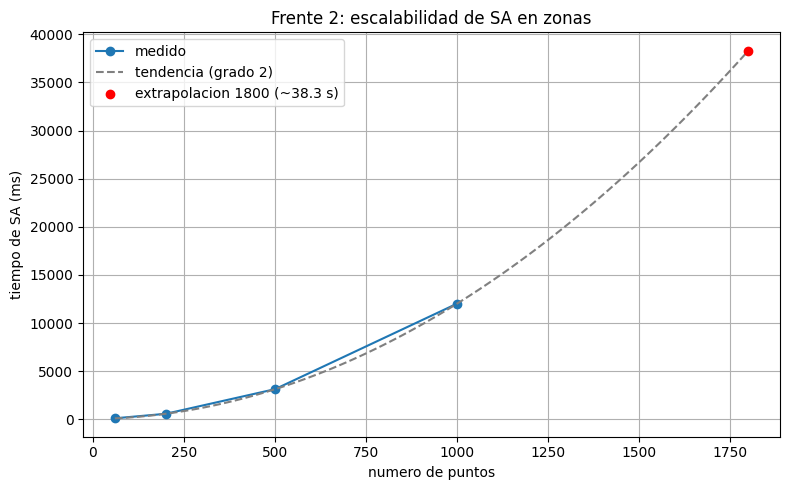

In [10]:
# max_iter moderado (150) para que el estudio termine en tiempo razonable:
# interesa medir la TENDENCIA del tiempo con n, no la calidad final de la solución.
def estudio_escalabilidad_zonas(tamanos=(60, 200, 500, 1000), n_cuadrillas=4, max_iter_test=150): # Aquí se define la función para realizar el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignación de zonas a cuadrillas, con diferentes tamaños de instancias y un número moderado de iteraciones, para medir la tendencia del tiempo de ejecución en función del número de puntos
    filas = [] # Aquí se crea una lista vacia, que se utilizara para almacenar los resultados del estudio de escalabilidad, donde cada elemento de la lista sera una tupla con el número de puntos y el tiempo de ejecución del algoritmo en milisegundos
    for n in tamanos: # Aquí se define un bucle for que recorre los valores de la tupla tamanos, que representan el número de puntos a evaluar en cada instancia del estudio de escalabilidad, y se utiliza para generar diferentes instancias del problema con distintos números de puntos
        red_n = generar_red_logistica(n_puntos=n, n_cuadrillas=n_cuadrillas) # Aquí se llama a la función generar_red_logistica para generar una red logistica con n puntos y n_cuadrillas cuadrillas, y se almacena en la variable red_n, que se utilizara para crear la instancia del problema de asignación de zonas a cuadrillas
        dist_n = matriz_distancias(red_n) # Aquí se llama a la función matriz_distancias para calcular la matriz de distancias entre los puntos de la red generada anteriormente, y se almacena en la variable dist_n, que se utilizara para crear la instancia del problema de asignación de zonas a cuadrillas
        prob = ProblemaZonas(red_n, dist_n, n_cuadrillas) # Aquí se crea una instancia del problema de asignación de zonas a cuadrillas, utilizando la clase definida anteriormente, con los parámetros de la red generada anteriormente, la matriz de distancias calculada anteriormente y el número de cuadrillas especificado
        random.seed(SEED); np.random.seed(SEED) # Aquí se establece la semilla para los generadores de números aleatorios de los modulos random y numpy, utilizando la constante SEED definida anteriormente, para asegurar que los resultados del estudio de escalabilidad sean reproducibles y consistentes en cada ejecución
        t0 = time.perf_counter() # Aquí se inicia el contador de tiempo para medir el tiempo de ejecución del algoritmo de Simulated Annealing en la instancia del problema creada anteriormente
        simulated_annealing(prob, T0=500, alpha=0.999, Tmin=0.1, max_iter=max_iter_test) # Aquí se ejecuta el algoritmo de Simulated Annealing para encontrar una asignación de zonas a cuadrillas que minimice el costo total, utilizando la instancia del problema creada anteriormente y los parámetros del algoritmo (T0=500, alpha=0.999, Tmin=0.1, max_iter=max_iter_test), y se descarta la asignación encontrada ya que solo nos interesa medir el tiempo de ejecución
        filas.append((n, (time.perf_counter() - t0) * 1000)) # Aquí se calcula el tiempo de ejecución del algoritmo en milisegundos, restando el tiempo inicial del tiempo actual y multiplicando por 1000 para convertir a milisegundos, y se agrega una tupla con el número de puntos n y el tiempo de ejecución calculado a la lista filas
    return pd.DataFrame(filas, columns=["n puntos", "tiempo (ms)"]), max_iter_test # Aquí se crea un DataFrame de pandas a partir de la lista filas, que contiene la informacion de todas las instancias evaluadas en el estudio de escalabilidad, con las columnas "n puntos" y "tiempo (ms)", y se retorna junto con el número de iteraciones max_iter_test utilizado en el estudio


tabla_escala, MAXIT_ESCALA = estudio_escalabilidad_zonas() # Aquí se llama a la función estudio_escalabilidad_zonas para realizar el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignación de zonas a cuadrillas, y se obtienen el DataFrame con los resultados del estudio y el número de iteraciones max_iter_test utilizado en el estudio, que se almacenan en las variables tabla_escala y MAXIT_ESCALA respectivamente
print("BLOQUE C(2) - Escalabilidad de SA en zonas (max_iter =", MAXIT_ESCALA, ")") # Aquí se imprime un mensaje indicando que se ejecuto el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignación de zonas a cuadrillas, y se muestra el número de iteraciones max_iter_test utilizado en el estudio
print(tabla_escala.to_string(index=False)) # Aquí se imprime el DataFrame tabla_escala, que contiene la informacion de todas las instancias evaluadas en el estudio de escalabilidad, sin mostrar los índices de las filas, para mostrar los resultados del estudio de manera clara y legible
 
coef = np.polyfit(tabla_escala["n puntos"], tabla_escala["tiempo (ms)"], 2) # Aquí se utiliza la función polyfit de numpy para ajustar un polinomio de grado 2 a los datos del DataFrame tabla_escala, utilizando las columnas "n puntos" y "tiempo (ms)" como variables independientes y dependientes respectivamente, y se obtienen los coeficientes del polinomio ajustado, que se almacenan en la variable coef
pred_1800 = float(np.polyval(coef, 1800)) # Aquí se utiliza la función polyval de numpy para evaluar el polinomio ajustado en el valor 1800, utilizando los coeficientes del polinomio almacenados en la variable coef, y se obtiene la prediccion del tiempo de ejecución del algoritmo de Simulated Annealing para una instancia con 1800 puntos, que se almacena en la variable pred_1800
factor_calidad = 40000 / MAXIT_ESCALA # Aquí se calcula el factor de calidad, que es el cociente entre el número de iteraciones max_iter utilizado en la ejecución de produccion (40000) y el número de iteraciones max_iter utilizado en el estudio de escalabilidad (MAXIT_ESCALA), y se almacena en la variable factor_calidad, que se utilizara para estimar el tiempo de ejecución del algoritmo para una instancia con 1800 puntos en condiciones de produccion
print(f"\nTendencia (grado 2): t(ms) ~ {coef[0]:.3e}*n^2 + {coef[1]:.3e}*n + {coef[2]:.1f}") # Aquí se imprime un mensaje indicando la tendencia del tiempo de ejecución del algoritmo de Simulated Annealing en función del número de puntos, utilizando los coeficientes del polinomio ajustado almacenados en la variable coef, y se muestra la ecuación del polinomio en notación cientifica con 3 decimales para los coeficientes y 1 decimal para el término independiente
print(f"Extrapolacion a 1800 puntos: {pred_1800:.0f} ms ~ {pred_1800/1000:.1f} s (con max_iter={MAXIT_ESCALA})") # Aquí se imprime un mensaje indicando la extrapolacion del tiempo de ejecución del algoritmo de Simulated Annealing para una instancia con 1800 puntos, utilizando la prediccion almacenada en la variable pred_1800, y se muestra el tiempo en milisegundos y en segundos, junto con el número de iteraciones max_iter utilizado en el estudio de escalabilidad
print(f"Con max_iter=40000 (calidad de produccion) escalaria ~x{factor_calidad:.0f} " # Aquí se imprime un mensaje indicando la estimacion del tiempo de ejecución del algoritmo de Simulated Annealing para una instancia con 1800 puntos en condiciones de produccion, utilizando el factor de calidad almacenado en la variable factor_calidad, y se muestra el tiempo estimado en minutos
      f"-> ~{pred_1800/1000*factor_calidad/60:.0f} min para 1800 puntos") # Aquí se calcula el tiempo estimado en minutos para una instancia con 1800 puntos en condiciones de produccion, utilizando la prediccion almacenada en la variable pred_1800, el factor de calidad almacenado en la variable factor_calidad y la conversion de milisegundos a minutos, y se muestra el resultado en un mensaje

fig_esc, ax_esc = plt.subplots(figsize=(8, 5)) # Aquí se crea una figura y un eje para graficar los resultados del estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignación de zonas a cuadrillas, utilizando la función subplots de matplotlib, y se especifica el tamaño de la figura en pulgadas (8x5)
ax_esc.plot(tabla_escala["n puntos"], tabla_escala["tiempo (ms)"], "o-", label="medido") # Aquí se grafica la curva de tiempo de ejecución del algoritmo de Simulated Annealing en función del número de puntos, utilizando los datos del DataFrame tabla_escala, y se especifica el estilo de la curva como puntos conectados por lineas ("o-") y se agrega una etiqueta para la leyenda ("medido")
xs = np.linspace(60, 1800, 100) # Aquí se crea un arreglo de 100 valores equiespaciados entre 60 y 1800, utilizando la función linspace de numpy, que se utilizara para evaluar el polinomio ajustado y graficar la tendencia del tiempo de ejecución del algoritmo de Simulated Annealing en función del número de puntos
ax_esc.plot(xs, np.polyval(coef, xs), "--", color="gray", label="tendencia (grado 2)") # Aquí se grafica la curva de tendencia del tiempo de ejecución del algoritmo de Simulated Annealing en función del número de puntos, utilizando los valores del arreglo xs y evaluando el polinomio ajustado con la función polyval de numpy, y se especifica el estilo de la curva como lineas discontinuas ("--"), el color como gris y se agrega una etiqueta para la leyenda ("tendencia (grado 2)")
ax_esc.scatter([1800], [pred_1800], color="red", zorder=5, # Aquí se grafica un punto rojo en la coordenada (1800, pred_1800) para indicar la extrapolacion del tiempo de ejecución del algoritmo de Simulated Annealing para una instancia con 1800 puntos, utilizando la función scatter de matplotlib, y se especifica el color como rojo y el orden de dibujo como 5 para que se muestre por encima de las curvas
               label=f"extrapolacion 1800 (~{pred_1800/1000:.1f} s)") # Aquí se agrega una etiqueta para la leyenda del punto rojo, indicando que representa la extrapolacion del tiempo de ejecución del algoritmo de Simulated Annealing para una instancia con 1800 puntos, y se muestra el tiempo estimado en segundos
ax_esc.set_xlabel("numero de puntos"); ax_esc.set_ylabel("tiempo de SA (ms)") # Aquí se establecen las etiquetas de los ejes x, y del grafico, indicando que el eje x representa el número de puntos y el eje y representa el tiempo de ejecución del algoritmo de Simulated Annealing en milisegundos
ax_esc.set_title("Frente 2: escalabilidad de SA en zonas") # Aquí se establece el titulo del grafico, indicando que representa el estudio de escalabilidad del algoritmo de Simulated Annealing en el problema de asignación de zonas a cuadrillas
ax_esc.legend(); plt.tight_layout(); plt.show() # Aquí se muestra la leyenda del grafico, se ajusta el diseño de la figura para que no se superpongan los elementos y se muestra la figura en pantalla

Interpretación: con `max_iter` moderado, una sola pasada de SA para 1800 puntos toma del orden de pocos minutos (ver extrapolación). Como el costo por evaluación crece de forma **cuadrática**, una corrida con la calidad de producción (`max_iter` alto, como el usado en el Frente 2) escalaría a **decenas de minutos**, lo que hace que 1800 puntos **no sea práctico en tiempo real** con esta implementación pura en Python. Sí es factible como **proceso offline** o reduciéndolo con optimizaciones directas: evaluación **incremental** del costo (recalcular solo la zona modificada en cada vecino en lugar de toda la red), vectorización con NumPy o partición previa por sectores geográficos.

---
## Frente 3 — Reabastecimiento diario bajo incertidumbre

### 4.1 Formulación del MDP
Como el caso es de **alimentos frescos**, el modelo base es de inventario **perecedero con vida útil de 3 días**: el estado codifica las unidades que **vencen hoy** y las que **vencen mañana**, la acción es la cantidad fresca a pedir, la transición es estocástica (demanda) y la recompensa es ingreso − compra − merma (lo caducado) − agotado. El modelo **sin vida útil** (`MDPReabastecimiento`) se conserva únicamente como **comparación**: su política, llevada al mundo real perecedero, rinde menos que la perecedera-consciente, y sus métricas no reflejan la realidad porque confunde el inventario que arrastra con merma.

In [11]:
class MDPReabastecimiento: # Aquí se define un MDP para el problema de reabastecimiento de inventario en un punto de venta, con los parámetros de demanda, inventario máximo, precio de venta, costo unitario, costo por merma, costo por agotado y factor de descuento
    def __init__(self, demanda_punto, inv_max=20, precio=5.0, costo_unit=2.0, # Aquí se inicializa los atributos de la instancia con los parámetros de demanda, inventario máximo, precio de venta, costo unitario, costo por merma, costo por agotado y factor de descuento
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95): # Aquí se definen los parámetros que son la serie de demanda del punto de venta, el inventario máximo, el precio de venta, el costo unitario, el costo por merma, el costo por agotado y el factor de descuento
        self.inv_max = inv_max # Aquí se asigna el valor del inventario máximo al atributo inv_max de la instancia, que representa la cantidad maxima de unidades que se pueden almacenar en el punto de venta
        self.precio = precio # Aquí se asigna el valor del precio de venta al atributo precio de la instancia, que representa el precio al que se venden las unidades en el punto de venta
        self.costo_unit = costo_unit # Aquí se asigna el valor del costo unitario al atributo costo_unit de la instancia, que representa el costo de adquirir una unidad para reabastecer el inventario del punto de venta
        self.costo_merma = costo_merma # Aquí se asigna el valor del costo por merma al atributo costo_merma de la instancia, que representa el costo asociado a las unidades excedentes
        self.costo_agotado = costo_agotado # Aquí se asigna el valor del costo por agotado al atributo costo_agotado de la instancia, que representa el costo asociado a las unidades no disponibles
        self.gamma = gamma # Aquí se asigna el valor del factor de descuento al atributo gamma de la instancia, que representa la tasa de descuento para futuras recompensas
        self.S = list(range(inv_max + 1)) # Aquí se crea una lista de estados posibles del inventario, que van desde 0 hasta el inventario máximo, y se asigna al atributo S de la instancia, que representa los posibles niveles de inventario en el punto de venta
        self.A = list(range(inv_max + 1)) # Aquí se crea una lista de acciones posibles, que van desde 0 hasta el inventario máximo, y se asigna al atributo A de la instancia, que representa las posibles cantidades de reabastecimiento
        self.dist_demanda = self._estimar_demanda(demanda_punto) # Aquí se llama al método _estimar_demanda para estimar la distribución de probabilidad de la demanda del punto de venta, utilizando la serie de demanda proporcionada como parámetro, y se asigna al atributo dist_demanda de la instancia, que representa la distribución de probabilidad de la demanda en el punto de venta

    def _estimar_demanda(self, serie): # Aquí se define el método _estimar_demanda, que estima la distribución de probabilidad de la demanda del punto de venta a partir de la serie de demanda proporcionada como parámetro
        # Escala la demanda a "lotes" para que el inventario máximo cubra ~el pico,
        # generando un verdadero compromiso entre merma (exceso) y agotado (defecto).
        serie = np.asarray(serie, dtype=float) # Aquí se convierte la serie de demanda proporcionada como parámetro en un arreglo de numpy de tipo float, para facilitar el procesamiento y los cálculos posteriores
        escala = self.inv_max / (serie.max() + 1e-9) # Aquí se calcula un factor de escala para ajustar la demanda a "lotes", dividiendo el inventario máximo por el valor máximo de la serie de demanda mas un valor muy pequeño (1e-9) para evitar la division por cero, y se asigna a la variable escala
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int) # Aquí se ajusta la serie de demanda a "lotes" multiplicando cada valor de la serie por el factor de escala calculado anteriormente, redondeando los valores resultantes, y luego se limita el rango de los valores a un mínimo de 0 y un máximo del inventario máximo utilizando la función clip de numpy, y finalmente se convierte el arreglo resultante a tipo int, y se asigna a la variable lotes
        valores, conteos = np.unique(lotes, return_counts=True) # Aquí se utiliza la función unique de numpy para obtener los valores únicos de la serie de lotes ajustada y sus respectivas frecuencias de ocurrencia, y se asignan a las variables valores y conteos respectivamente
        probs = conteos / conteos.sum() # Aquí se calcula la distribución de probabilidad de la demanda dividiendo las frecuencias de ocurrencia de cada valor único por la suma total de las frecuencias, y se asigna a la variable probs
        return dict(zip(valores.tolist(), probs.tolist())) # Aquí se crea un diccionario que mapea cada valor único de la serie de lotes ajustada a su respectiva probabilidad de ocurrencia, utilizando la función zip para combinar las listas de valores y probabilidades, y luego se convierte a un diccionario utilizando la función dict, y se retorna como resultado del método _estimar_demanda

    def recompensa(self, s, a, d): # Aquí se define el método recompensa, que calcula la recompensa obtenida en un periodo de tiempo dado el estado actual del inventario s, la acción tomada a y la demanda observada d
        disponible = min(s + a, self.inv_max) # Aquí se calcula la cantidad disponible de unidades en el inventario despues de tomar la acción a, sumando el estado actual del inventario s y la acción tomada a, y limitando el resultado al inventario máximo utilizando la función min, y se asigna a la variable disponible
        vendido = min(disponible, d) # Aquí se calcula la cantidad de unidades vendidas, tomando el mínimo entre la cantidad disponible y la demanda observada, y se asigna a la variable vendido
        sobrante = disponible - vendido # Aquí se calcula la cantidad de unidades excedentes, restando la cantidad vendida de la cantidad disponible, y se asigna a la variable sobrante
        faltante = max(d - disponible, 0) # Aquí se calcula la cantidad de unidades faltantes, tomando el máximo entre la demanda observada menos la cantidad disponible y cero, y se asigna a la variable faltante
        ingreso = self.precio * vendido # Aquí se calcula el ingreso total por ventas, multiplicando el precio de venta por la cantidad vendida, y se asigna a la variable ingreso
        costo_compra = self.costo_unit * a # Aquí se calcula el costo total de compra, multiplicando el costo unitario por la cantidad comprada, y se asigna a la variable costo_compra
        penal_merma = self.costo_merma * sobrante # Aquí se calcula la penalización por merma, multiplicando el costo por merma por la cantidad de unidades excedentes, y se asigna a la variable penal_merma
        penal_agotado = self.costo_agotado * faltante # Aquí se calcula la penalización por agotado, multiplicando el costo por agotado por la cantidad de unidades faltantes, y se asigna a la variable penal_agotado
        return ingreso - costo_compra - penal_merma - penal_agotado # Aquí se calcula la recompensa neta obtenida en el periodo de tiempo, restando el costo total de compra, la penalización por merma y la penalización por agotado del ingreso total por ventas, y se retorna como resultado del método recompensa

    def transicion(self, s, a): # Aquí se define el método transición, que calcula la distribución de probabilidad de los estados futuros del inventario dado el estado actual s y la acción tomada a
        disponible = min(s + a, self.inv_max) # Aquí se calcula la cantidad disponible de unidades en el inventario despues de tomar la acción a, sumando el estado actual del inventario s y la acción tomada a, y limitando el resultado al inventario máximo utilizando la función min, y se asigna a la variable disponible
        resultados = {} # Aquí se crea un diccionario vacio resultados, que se utilizara para almacenar la distribución de probabilidad de los estados futuros del inventario, donde las claves seran los estados futuros y los valores seran tuplas con la probabilidad de ocurrencia y la recompensa ponderada correspondiente
        for d, p in self.dist_demanda.items(): # Aquí se recorre la distribución de probabilidad de la demanda, utilizando el método items() para obtener tanto la demanda d como su probabilidad p, y se utiliza para calcular los estados futuros del inventario y sus respectivas recompensas
            sobrante = max(disponible - d, 0) # Aquí se calcula la cantidad de unidades excedentes, tomando el máximo entre la cantidad disponible menos la demanda observada y cero, y se asigna a la variable sobrante
            s_sig = int(min(sobrante, self.inv_max)) # Aquí se calcula el estado futuro del inventario, tomando el mínimo entre la cantidad de unidades excedentes y el inventario máximo, y se convierte a entero, y se asigna a la variable s_sig
            r = self.recompensa(s, a, d) # Aquí se calcula la recompensa obtenida en el periodo de tiempo, utilizando el método recompensa con los parámetros s, a y d, y se asigna a la variable r
            if s_sig not in resultados: # Aquí se verifica si el estado futuro s_sig no esta presente en el diccionario resultados, y si es así, se inicializa con una lista de dos elementos [0.0, 0.0] para almacenar la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro
                resultados[s_sig] = [0.0, 0.0] # Aquí se inicializa el estado futuro s_sig en el diccionario resultados con una lista de dos elementos [0.0, 0.0], que representaran la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro
            resultados[s_sig][0] += p # Aquí se acumula la probabilidad de ocurrencia p del estado futuro s_sig en el primer elemento de la lista correspondiente en el diccionario resultados, sumando p al valor actual
            resultados[s_sig][1] += p * r # Aquí se acumula la recompensa ponderada correspondiente al estado futuro s_sig en el segundo elemento de la lista correspondiente en el diccionario resultados, sumando p * r al valor actual, donde r es la recompensa obtenida en el periodo de tiempo
        salida = {} # Aquí se crea un diccionario vacio salida, que se utilizara para almacenar la distribución de probabilidad de los estados futuros del inventario junto con la recompensa ponderada correspondiente, donde las claves seran los estados futuros y los valores seran tuplas con la probabilidad de ocurrencia y la recompensa ponderada correspondiente
        for s_sig, (prob, r_pond) in resultados.items(): # Aquí se recorre el diccionario resultados, utilizando el método items() para obtener tanto el estado futuro s_sig como la tupla (prob, r_pond) que contiene la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro, y se utiliza para calcular la recompensa ponderada promedio para cada estado futuro
            salida[s_sig] = (prob, r_pond / prob if prob > 0 else 0.0) # Aquí se calcula la recompensa ponderada promedio para cada estado futuro s_sig, dividiendo la recompensa ponderada acumulada r_pond entre la probabilidad acumulada prob, y se almacena en el diccionario salida como una tupla (prob, recompensa_ponderada_promedio), donde si la probabilidad acumulada es cero, se asigna un valor de 0.0 para evitar la division por cero
        return salida # Aquí se retorna el diccionario salida, que contiene la distribución de probabilidad de los estados futuros del inventario junto con la recompensa ponderada promedio correspondiente para cada estado futuro, como resultado del método transición


**Modelo base perecedero.** `MDPReabastecimientoVidaUtil` implementa el inventario con vida útil **configurable (2 o 3 días)** que sirve de **base a los Frentes 3 y 4** (el caso es de alimentos frescos). El estado codifica las cohortes que vencen hoy/mañana, la venta es FIFO y lo no vendido que caduca cuenta como merma. El `MDPReabastecimiento` de arriba se conserva solo como **comparación** (inventario sin caducidad).

In [12]:
class MDPReabastecimientoVidaUtil:
    """MDP de reabastecimiento con inventario PERECEDERO y vida util CONFIGURABLE (2 o 3 dias).

    Modela alimentos frescos: el inventario caduca. La vida util se fija con `vida_util`.
    - vida_util=2: el estado es una sola cohorte = unidades que VENCEN HOY (lo que sobro
      fresco ayer). Es el modelo de la extension original (regresion exacta).
    - vida_util=3: el estado es la tupla (vence_hoy, vence_manana). Se CODIFICA a un entero
      para no tocar policy_iteration / value_iteration (que asumen estados escalares).

    Accion a = unidades frescas pedidas hoy. Venta FIFO (primero lo mas viejo: hoy -> manana
    -> fresco del dia). Al cierre del dia: lo que vencia hoy y no se vendio CADUCA (merma);
    lo que vencia manana pasa a vencer hoy; el fresco sobrante pasa a vencer manana. Esta
    memoria entre dias es la que hace que gamma influya en la politica.

    Rendimiento: con vida_util=3 el espacio de estados crece a (inv_max+1)(inv_max+2)/2
    (los estados con vence_hoy+vence_manana <= inv_max). Con inv_max=15 son 136 estados
    (~3 s por Policy Iteration); con inv_max=20 subiria a 231 estados (~16 s por Value
    Iteration) y el Frente 4 completo se volveria impractico. Por eso inv_max=15 por
    defecto cuando vida_util=3 y se mantiene inv_max=20 cuando vida_util=2.
    """
    def __init__(self, demanda_punto, inv_max=None, precio=5.0, costo_unit=2.0, # Aquí se define la clase MDPReabastecimientoVidaUtil, que representa un MDP para el problema de reabastecimiento de inventario con productos perecederos y vida útil configurable (2 o 3 días), y se inicializan los atributos de la instancia con los parámetros de demanda, inventario máximo, precio de venta, costo unitario, costo por merma, costo por agotado y factor de descuento
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95, vida_util=2): # Aquí se definen los parámetros que son la serie de demanda del punto de venta, el inventario máximo, el precio de venta, el costo unitario, el costo por merma, el costo por agotado, el factor de descuento y la vida útil del producto
        if vida_util not in (2, 3): # Aquí se verifica si el valor de vida_util proporcionado como parámetro no es 2 ni 3, y si es así, se lanza una excepción ValueError indicando que vida_util debe ser 2 o 3, para asegurar que la vida útil del producto sea válida y compatible con el modelo definido
            raise ValueError("vida_util debe ser 2 o 3") # Aquí se lanza una excepción ValueError con un mensaje indicando que vida_util debe ser 2 o 3, para informar al usuario que el valor proporcionado para vida_util no es válido y que debe corregirlo antes de continuar con la ejecución del programa
        self.vida_util = vida_util # Aquí se asigna el valor de vida_util proporcionado como parámetro al atributo vida_util de la instancia, que representa la vida útil del producto en días, y se utiliza para determinar la dinámica del inventario y la codificación de los estados en el MDP
        # Cota de inventario por defecto: 20 para 2 dias, 15 para 3 dias (control de rendimiento).
        if inv_max is None: # Aquí se verifica si el valor de inv_max proporcionado como parámetro es None, y si es así, se asigna un valor por defecto de 20 para vida_util=2 o 15 para vida_util=3, para establecer una cota de inventario adecuada y controlar el rendimiento del modelo
            inv_max = 20 if vida_util == 2 else 15 # Aquí se asigna el valor de inv_max a 20 si vida_util es igual a 2, o a 15 si vida_util es igual a 3, utilizando una expresión condicional, para establecer la cota de inventario por defecto en función de la vida útil del producto
        self.inv_max = inv_max # Aquí se asigna el valor de inv_max proporcionado como parámetro o calculado por defecto al atributo inv_max de la instancia, que representa la cantidad máxima de unidades que se pueden almacenar en el punto de venta, y se utiliza para limitar el inventario y las acciones posibles en el MDP
        self.precio = precio # Aquí se asigna el valor de precio proporcionado como parámetro al atributo precio de la instancia, que representa el precio de venta de cada unidad del producto
        self.costo_unit = costo_unit # Aquí se asigna el valor de costo_unit proporcionado como parámetro al atributo costo_unit de la instancia, que representa el costo unitario de cada unidad del producto
        self.costo_merma = costo_merma # Aquí se asigna el valor de costo_merma proporcionado como parámetro al atributo costo_merma de la instancia, que representa el costo asociado a la merma de cada unidad del producto
        self.costo_agotado = costo_agotado # Aquí se asigna el valor de costo_agotado proporcionado como parámetro al atributo costo_agotado de la instancia, que representa el costo asociado a la falta de stock de cada unidad del producto
        self.gamma = gamma # Aquí se asigna el valor de gamma proporcionado como parámetro al atributo gamma de la instancia, que representa el factor de descuento en el cálculo del valor esperado
        self.A = list(range(inv_max + 1))   # pedido fresco
        # Codificacion estado <-> entero, para que PI/VI vean estados escalares.
        self.cod = {}   # estado decodificado -> entero 
        self.dec = {}   # entero -> estado decodificado
        if vida_util == 2: # Aquí se verifica si la vida útil del producto es 2 días
            # Una sola cohorte: el entero ES la cohorte (identidad) -> regresion exacta.
            for h in range(inv_max + 1): # Aquí se recorren todos los valores posibles de h (inventario actual)
                self.cod[h] = h # Aquí se asigna el valor de h al diccionario cod, que representa la codificación del estado h
                self.dec[h] = h # Aquí se asigna el valor de h al diccionario dec, que representa la decodificación del estado h
        else: # Aquí se verifica si la vida útil del producto es 3 días
            # Estado (vence_hoy, vence_manana) con vence_hoy + vence_manana <= inv_max.
            k = 0 # Aquí se inicializa la variable k
            for h in range(inv_max + 1): # Aquí se recorren todos los valores posibles de h (inventario actual)
                for m in range(inv_max + 1 - h): # Aquí se recorren todos los valores posibles de m (inventario de productos vencidos)
                    self.cod[(h, m)] = k # Aquí se asigna el valor de k al diccionario cod, que representa la codificación del estado (h, m)
                    self.dec[k] = (h, m) # Aquí se asigna el valor de (h, m) al diccionario dec, que representa la decodificación del estado k
                    k += 1 # Aquí se incrementa el valor de k
        self.S = list(self.dec.keys()) # Aquí se asigna la lista de claves del diccionario dec a self.S
        self.dist_demanda = self._estimar_demanda(demanda_punto) # Aquí se asigna la distribución de demanda estimada a self.dist_demanda

    def _estimar_demanda(self, serie): # Aquí se define el método para estimar la distribución de demanda
        serie = np.asarray(serie, dtype=float) # Aquí se convierte la serie de datos en un array de NumPy
        escala = self.inv_max / (serie.max() + 1e-9) # Aquí se calcula la escala para normalizar los datos
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int) # Aquí se redondean los valores y se limitan al rango válido
        valores, conteos = np.unique(lotes, return_counts=True) # Aquí se obtienen los valores únicos y sus conteos
        probs = conteos / conteos.sum() # Aquí se calculan las probabilidades
        return dict(zip(valores.tolist(), probs.tolist())) # Aquí se devuelve un diccionario con los valores y sus probabilidades

    def _codificar(self, h, m=0): # Aquí se define el método para codificar un estado
        # Clip a la malla valida de estados (mismo espiritu que min(.., inv_max) del modelo 2 dias).
        h = int(min(h, self.inv_max)) # Aquí se limita el valor de h al rango válido
        if self.vida_util == 2: # Aquí se verifica si la vida util es de 2 dias
            return self.cod[h] # Aquí se devuelve la codificación del estado h
        m = int(min(m, self.inv_max - h)) # Aquí se limita el valor de m al rango válido
        return self.cod[(h, m)] # Aquí se devuelve la codificación del estado (h, m)

    def _dinamica(self, s_cod, a, d): # Aquí se define el método para calcular la dinámica del sistema dado un estado codificado, una acción y una demanda
        a = int(a) # Aquí se convierte la acción a en un entero
        fresco = int(min(a, self.inv_max))            # pedido de hoy (con vida util plena)
        if self.vida_util == 2: # Aquí se verifica si la vida util es de 2 dias
            viejo = int(min(self.dec[s_cod], self.inv_max))   # vence hoy
            disponible = viejo + fresco # Aquí se calcula la cantidad disponible sumando el inventario viejo y el fresco
            vendido = min(disponible, d) # Aquí se calcula la cantidad vendida tomando el mínimo entre la cantidad disponible y la demanda
            vendido_viejo = min(viejo, vendido)               # FIFO: primero lo viejo
            vendido_fresco = vendido - vendido_viejo # Aquí se calcula la cantidad vendida de productos frescos restando la cantidad vendida de productos viejos de la cantidad total vendida
            caduca = viejo - vendido_viejo                    # viejo no vendido -> merma
            sobra_fresco = fresco - vendido_fresco            # fresco no vendido -> vence manana
            faltante = max(d - disponible, 0) # Aquí se calcula la cantidad faltante tomando el máximo entre la demanda menos la cantidad disponible y cero
            s_sig = self._codificar(sobra_fresco) # Aquí se codifica el estado siguiente utilizando la cantidad de productos frescos sobrantes
        else: # Aquí se verifica si la vida util es de 3 dias
            h, m = self.dec[s_cod]                            # vence hoy, vence manana
            disponible = h + m + fresco # Aquí se calcula la cantidad disponible sumando el inventario que vence hoy, el que vence mañana y el fresco
            vendido = min(disponible, d) # Aquí se calcula la cantidad vendida tomando el mínimo entre la cantidad disponible y la demanda
            vendido_h = min(h, vendido)                       # FIFO: hoy -> manana -> fresco
            resto = vendido - vendido_h # Aquí se calcula la cantidad restante de productos vendidos después de vender los que vencen hoy
            vendido_m = min(m, resto) # Aquí se calcula la cantidad vendida de productos que vencen mañana tomando el mínimo entre el inventario que vence mañana y la cantidad restante de productos vendidos
            vendido_f = resto - vendido_m # Aquí se calcula la cantidad vendida de productos frescos restando la cantidad vendida de productos que vencen mañana de la cantidad restante de productos vendidos
            caduca = h - vendido_h                            # lo que vencia hoy y no se vendio
            nuevo_h = m - vendido_m                           # lo que vencia manana ahora vence hoy
            nuevo_m = fresco - vendido_f                      # fresco sobrante vence manana
            faltante = max(d - disponible, 0) # Aquí se calcula la cantidad faltante tomando el máximo entre la demanda menos la cantidad disponible y cero
            s_sig = self._codificar(nuevo_h, nuevo_m) # Aquí se codifica el estado siguiente utilizando la cantidad de productos que vencen hoy y los que vencen mañana
        r = (self.precio * vendido - self.costo_unit * a # Aquí se calcula la recompensa neta obtenida en el periodo de tiempo, restando el costo total de compra, la penalización por merma y la penalización por agotado del ingreso total por ventas, y se asigna a la variable r
             - self.costo_merma * caduca - self.costo_agotado * faltante) # Aquí se calcula la recompensa neta obtenida en el periodo de tiempo, restando el costo total de compra, la penalización por merma y la penalización por agotado del ingreso total por ventas, y se asigna a la variable r
        return s_sig, r, vendido, caduca, faltante # Aquí se retorna una tupla con el estado siguiente codificado, la recompensa neta obtenida, la cantidad vendida, la cantidad que caduca y la cantidad faltante como resultado del método _dinamica

    def recompensa(self, s, a, d): # Aquí se define el método recompensa, que calcula la recompensa obtenida en un periodo de tiempo dado el estado actual del inventario s, la acción tomada a y la demanda observada d
        return self._dinamica(s, a, d)[1] # Aquí se llama al método _dinamica con los parámetros s, a y d, y se retorna el segundo elemento de la tupla resultante, que representa la recompensa neta obtenida en el periodo de tiempo

    def transicion(self, s, a): # Aquí se define el método transición, que calcula la distribución de probabilidad de los estados futuros del inventario dado el estado actual s y la acción tomada a
        resultados = {} # Aquí se crea un diccionario vacío resultados, que se utilizará para almacenar la distribución de probabilidad de los estados futuros del inventario, donde las claves serán los estados futuros y los valores serán tuplas con la probabilidad de ocurrencia y la recompensa ponderada correspondiente
        for d, p in self.dist_demanda.items(): # Aquí se recorre la distribución de probabilidad de la demanda, utilizando el método items() para obtener tanto la demanda d como su probabilidad p, y se utiliza para calcular los estados futuros del inventario y sus respectivas recompensas
            s_sig, r, *_ = self._dinamica(s, a, d) # Aquí se llama al método _dinamica con los parámetros s, a y d, y se desempaqueta la tupla resultante para obtener el estado siguiente codificado s_sig y la recompensa neta obtenida r, ignorando los demás valores retornados
            if s_sig not in resultados: # Aquí se verifica si el estado futuro s_sig no está presente en el diccionario resultados, y si es así, se inicializa con una lista de dos elementos [0.0, 0.0] para almacenar la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro
                resultados[s_sig] = [0.0, 0.0] # Aquí se inicializa el estado futuro s_sig en el diccionario resultados con una lista de dos elementos [0.0, 0.0], que representarán la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro
            resultados[s_sig][0] += p # Aquí se acumula la probabilidad de ocurrencia p del estado futuro s_sig en el primer elemento de la lista correspondiente en el diccionario resultados, sumando p al valor actual
            resultados[s_sig][1] += p * r # Aquí se acumula la recompensa ponderada correspondiente al estado futuro s_sig en el segundo elemento de la lista correspondiente en el diccionario resultados, sumando p * r al valor actual, donde r es la recompensa obtenida en el periodo de tiempo
        return {ss: (pr, rp / pr if pr > 0 else 0.0) # Aquí se crea un diccionario de salida que contiene la distribución de probabilidad de los estados futuros del inventario junto con la recompensa ponderada promedio correspondiente para cada estado futuro, donde las claves son los estados futuros ss y los valores son tuplas con la probabilidad de ocurrencia pr y la recompensa ponderada promedio rp / pr (si pr > 0) o 0.0 (si pr = 0), utilizando una comprensión de diccionario para iterar sobre los elementos del diccionario resultados y calcular la recompensa ponderada promedio para cada estado futuro
                for ss, (pr, rp) in resultados.items()} # Aquí se recorre el diccionario resultados, utilizando el método items() para obtener tanto el estado futuro ss como la tupla (pr, rp) que contiene la probabilidad acumulada y la recompensa ponderada acumulada correspondiente a ese estado futuro, y se utiliza para calcular la recompensa ponderada promedio para cada estado futuro


def simular_politica_vidautil(mdp, politica, demanda_serie_lotes, s_inicial=0): # Aquí se define la función simular_politica_vidautil, que simula la ejecución de una política de reabastecimiento en un MDP con inventario perecedero y vida útil configurable, utilizando una serie de demanda en lotes y un estado inicial codificado
    s = s_inicial                                  # estado codificado inicial (0 = inventario vacio)
    reg = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0} # Aquí se inicializa un diccionario reg con las métricas de desempeño de la simulación, que incluyen el ingreso total, la cantidad vendida, la cantidad de merma, la cantidad de agotado y la demanda total, todos inicializados en cero
    for d in demanda_serie_lotes: # Aquí se recorre la serie de demanda en lotes proporcionada como parámetro, utilizando un bucle for para iterar sobre cada valor de demanda d en la serie
        d = int(min(d, mdp.inv_max)) # Aquí se limita el valor de demanda d al rango válido del inventario máximo del MDP, utilizando la función min para asegurar que la demanda no exceda la capacidad máxima de inventario, y se convierte a entero
        a = politica[s] # Aquí se obtiene la acción a correspondiente al estado actual s de la política proporcionada como parámetro, utilizando el diccionario politica para mapear el estado codificado s a la acción recomendada a
        s_sig, r, vendido, caduca, faltante = mdp._dinamica(s, a, d) # Aquí se llama al método _dinamica del MDP con los parámetros s, a y d, y se desempaqueta la tupla resultante para obtener el estado siguiente codificado s_sig, la recompensa neta obtenida r, la cantidad vendida vendido, la cantidad que caduca caduca y la cantidad faltante faltante
        reg["ingreso"] += r # Aquí se acumula la recompensa neta obtenida r en el diccionario reg, sumando r al valor actual de la clave "ingreso", para mantener un registro del ingreso total generado durante la simulación
        reg["vendido"] += vendido # Aquí se acumula la cantidad vendida vendido en el diccionario reg, sumando vendido al valor actual de la clave "vendido", para mantener un registro de la cantidad total de unidades vendidas durante la simulación
        reg["merma"] += caduca # Aquí se acumula la cantidad que caduca caduca en el diccionario reg, sumando caduca al valor actual de la clave "merma", para mantener un registro de la cantidad total de unidades que han caducado durante la simulación
        reg["agotado"] += faltante # Aquí se acumula la cantidad faltante faltante en el diccionario reg, sumando faltante al valor actual de la clave "agotado", para mantener un registro de la cantidad total de unidades que han estado agotadas durante la simulación
        reg["demanda"] += d # Aquí se acumula la demanda d en el diccionario reg, sumando d al valor actual de la clave "demanda", para mantener un registro de la demanda total generada durante la simulación
        s = s_sig # Aquí se actualiza el estado actual s al estado siguiente codificado s_sig, para continuar la simulación en el siguiente periodo de tiempo con el nuevo estado del inventario
    dem = max(reg["demanda"], 1) # Aquí se calcula la demanda total dem, tomando el máximo entre la demanda acumulada en el diccionario reg y 1, para evitar la división por cero en los cálculos posteriores de las métricas de desempeño
    reg["nivel_servicio"] = reg["vendido"] / dem # Aquí se calcula el nivel de servicio, dividiendo la cantidad vendida acumulada en el diccionario reg entre la demanda total dem, y se asigna al diccionario reg bajo la clave "nivel_servicio", para medir la proporción de demanda satisfecha durante la simulación
    reg["tasa_agotado"] = reg["agotado"] / dem # Aquí se calcula la tasa de agotado, dividiendo la cantidad faltante acumulada en el diccionario reg entre la demanda total dem, y se asigna al diccionario reg bajo la clave "tasa_agotado", para medir la proporción de demanda no satisfecha debido a falta de inventario durante la simulación
    reg["tasa_merma"] = reg["merma"] / max(reg["vendido"] + reg["merma"], 1) # Aquí se calcula la tasa de merma, dividiendo la cantidad que caduca acumulada en el diccionario reg entre la suma de la cantidad vendida y la cantidad que caduca, tomando el máximo entre esta suma y 1 para evitar la división por cero, y se asigna al diccionario reg bajo la clave "tasa_merma", para medir la proporción de inventario que se pierde debido a caducidad en relación con el total de unidades manejadas durante la simulación
    return reg # Aquí se retorna el diccionario reg, que contiene las métricas de desempeño acumuladas durante la simulación de la política de reabastecimiento en el MDP con inventario perecedero y vida útil configurable


### 4.2 Policy Iteration
Evaluación de la política (`policy_evaluation`) y mejora (`policy_improvement`) hasta converger a la política óptima.

In [13]:
def policy_evaluation(politica, mdp, epsilon=1e-4): # Aquí se define la función policy_evaluation, que evalua una politica dada en el MDP utilizando el método de iteración de valor, con un criterio de convergencia basado en un umbral epsilon
    V = {s: 0.0 for s in mdp.S} # Aquí se crea un diccionario V que representa la función de valor para cada estado del MDP, inicializando todos los valores a 0.0, utilizando una comprension de diccionario que recorre todos los estados s en mdp.S y asigna 0.0 como valor inicial para cada estado
    while True: # Aquí se inicia un bucle while que se ejecutara indefinidamente hasta que se cumpla el criterio de convergencia basado en el umbral epsilon, para evaluar la politica dada en el MDP
        delta = 0 # Aquí se inicializa la variable delta a 0, que se utilizara para almacenar el cambio máximo en la función de valor V durante una iteración completa sobre todos los estados del MDP, y se utilizara para determinar si se ha alcanzado la convergencia
        for s in mdp.S: # Aquí se inicia un bucle for que recorre todos los estados s en mdp.S, para actualizar la función de valor V para cada estado según la politica dada y las transiciones del MDP
            v_anterior = V[s] # Aquí se almacena el valor anterior de la función de valor V para el estado s en la variable v_anterior, antes de actualizarlo según la politica dada y las transiciones del MDP
            a = politica[s] # Aquí se obtiene la acción a correspondiente a la politica dada para el estado s, utilizando el diccionario politica que mapea cada estado a una acción, y se asigna a la variable a
            trans = mdp.transicion(s, a) # Aquí se obtiene la distribución de probabilidad de los estados futuros y las recompensas correspondientes para el estado s y la acción a, utilizando el método transición del MDP, y se asign
            V[s] = sum(prob * (r + mdp.gamma * V[s_sig]) # Aquí se actualiza el valor de la función de valor V para el estado s, calculando la suma ponderada de las recompensas y los valores futuros de los estados alcanzables s_sig, multiplicando la probabilidad prob de cada transición por la suma de la recompensa r y el valor futuro descontado mdp.gamma * V[s_sig], y se asigna el resultado a V[s]
                       for s_sig, (prob, r) in trans.items()) # Aquí se utiliza una comprension de generador que recorre todos los estados futuros s_sig y sus respectivas probabilidades prob y recompensas r en la
            delta = max(delta, abs(v_anterior - V[s])) # Aquí se actualiza la variable delta con el cambio máximo en la función de valor V durante la iteración completa sobre todos los estados del MDP, calculando el valor absoluto de la diferencia entre el valor anterior v_anterior y el nuevo valor V[s] para cada estado s, y tomando el máximo entre el valor actual de delta y la diferencia calculada
        if delta < epsilon: # Aquí se verifica si el cambio máximo en la función de valor V durante la iteración completa sobre todos los estados del MDP es menor que el umbral epsilon, lo que indica que se ha alcanzado la convergencia y se puede salir del bucle while
            break # Aquí se rompe el bucle while si se ha alcanzado la convergencia, saliendo de la función policy_evaluation
    return V # Aquí se retorna el diccionario V que representa la función de valor evaluada para la politica dada en el MDP, como resultado de la función policy_evaluation


def policy_improvement(V, politica_actual, mdp): # Aquí se define la función policy_improvement, que mejora una politica dada en el MDP utilizando la función de valor V evaluada previamente, y devuelve una nueva politica mejorada y un indicador de estabilidad
    politica_nueva = {} # Aquí se crea un diccionario vacio politica_nueva, que se utilizara para almacenar la nueva politica mejorada, donde las claves seran los estados del MDP y los valores seran las acciones correspondientes a la nueva politica
    politica_estable = True # Aquí se inicializa la variable politica_estable a True, que se utilizara como indicador de estabilidad para determinar si la nueva politica mejorada es igual a la politica actual, y se actualizara a False si se encuentra alguna acción diferente entre ambas politicas
    for s in mdp.S: # Aquí se inicia un bucle for que recorre todos los estados s en mdp.S, para mejorar la politica actual utilizando la función de valor V evaluada previamente y las transiciones del MDP
        q_valores = {} # Aquí se crea un diccionario q_valores, que se utilizara para almacenar los valores Q para cada acción en el estado s
        for a in mdp.A: # Aquí se inicia un bucle for que recorre todas las acciones a en mdp.A, para calcular los valores Q para cada acción en el estado s
            trans = mdp.transicion(s, a) # Aquí se obtiene la distribución de probabilidad de los estados futuros y las recompensas correspondientes para el estado s y la acción a, utilizando el método transición del MDP, y se asigna a la variable trans
            q_valores[a] = sum(prob * (r + mdp.gamma * V[s_sig]) # Aquí se calcula el valor Q para la acción a en el estado s, sumando la produccion de las recompensas y los valores futuros de los estados alcanzables s_sig, multiplicando la probabilidad prob de cada transición por la suma de la recompensa r y el valor futuro descontado mdp.gamma * V[s_sig], y se asigna el resultado a q_valores[a]
                               for s_sig, (prob, r) in trans.items()) # Aquí se utiliza una comprension de generador que recorre todos los estados futuros s_sig y sus respectivas probabilidades prob y recompensas r en la distribución de probabilidad trans
        mejor_accion = max(q_valores, key=q_valores.get) # Aquí se selecciona la acción que maximiza el valor Q en el estado s, utilizando la función max con el argumento key=q_valores.get
        politica_nueva[s] = mejor_accion  # Aquí se asigna la mejor acción seleccionada a la nueva politica para el estado s
        if mejor_accion != politica_actual[s]: # Aquí se verifica si la mejor acción seleccionada es diferente de la acción actual en el estado s
            politica_estable = False # Aquí se actualiza la variable politica_estable a False si se encuentra alguna acción diferente entre ambas politicas
    return politica_nueva, politica_estable # Aquí se retorna la nueva politica mejorada y el indicador de estabilidad como resultado de la función policy_improvement


def policy_iteration(mdp, epsilon=1e-4): # Aquí se define la función policy_iteration, que implementa el algoritmo de iteración de politica para encontrar la politica óptima en el MDP, utilizando la evaluación y mejora de politica iterativamente hasta que se alcance la estabilidad
    politica = {s: random.choice(mdp.A) for s in mdp.S} # Aquí se crea un diccionario politica que representa la politica inicial, asignando una acción aleatoria de mdp.A a cada estado s en mdp.S, utilizando una comprension de diccionario y la función random.choice para seleccionar una acción aleatoria
    ciclos = 0 # Aquí se inicializa la variable ciclos a 0, que se utilizara para contar el número de iteraciones realizadas en el algoritmo de iteración de politica, y se incrementara en cada ciclo del bucle while
    while True: # Aquí se inicia un bucle while que se ejecutara indefinidamente hasta que se alcance la estabilidad de la politica, utilizando la evaluación y mejora de politica iterativamente
        ciclos += 1 # Aquí se incrementa la variable ciclos en 1, para contar el número de iteraciones realizadas en el algoritmo de iteración de politica
        V = policy_evaluation(politica, mdp, epsilon) # Aquí se llama a la función policy_evaluation con la politica actual, el MDP y el umbral epsilon, y se asigna el resultado a la variable V, que representa la función de valor evaluada para la politica actual
        politica, estable = policy_improvement(V, politica, mdp) # Aquí se llama a la función policy_improvement con la función de valor V evaluada, la politica actual y el MDP, y se desempaqueta el resultado en las variables politica y estable, donde politica representa la nueva politica mejorada y estable es un indicador de estabilidad que indica si la nueva politica es igual a la politica actual
        if estable: # Aquí se verifica si la nueva politica mejorada es igual a la politica actual, utilizando el indicador de estabilidad estable
            break # Aquí se rompe el bucle while si se ha alcanzado la estabilidad de la politica, saliendo de la función policy_iteration
    return politica, V, ciclos # Aquí se retorna la politica óptima encontrada, la función de valor evaluada para la politica óptima y el número de iteraciones realizadas en el algoritmo de iteración de politica, como resultado de la función policy_iteration


def value_iteration(mdp, epsilon=1e-4): # Aquí se define la función value_iteration, que implementa el algoritmo de iteración de valor para encontrar la politica óptima en el MDP, utilizando la actualizacion iterativa de la función de valor hasta que se alcance la convergencia
    # Iteracion de valor clasica: itera V hasta que el cambio máximo sea < epsilon
    V = {s: 0.0 for s in mdp.S} # Aquí se crea un diccionario V que representa la función de valor para cada estado del MDP, inicializando todos los valores a 0.0, utilizando una comprension de diccionario que recorre todos los estados s en mdp.S y asigna 0.0 como valor inicial para cada estado
    n_iteraciones = 0 # Aquí se inicializa la variable n_iteraciones a 0, que se utilizara para contar el número de iteraciones realizadas en el algoritmo de iteración de valor, y se incrementara en cada ciclo del bucle while
    while True: # Aquí se inicia un bucle while que se ejecutara indefinidamente hasta que se alcance la convergencia de la función de valor, utilizando la actualizacion iterativa de la función de valor  
        n_iteraciones += 1 # Aquí se incrementa la variable n_iteraciones en 1, para contar el número de iteraciones realizadas en el algoritmo de iteración de valor
        delta = 0 # Aquí se inicializa la variable delta a 0, que se utilizara para almacenar el cambio máximo en la función de valor V durante una iteración completa sobre todos los estados del MDP, y se utilizara para determinar si se ha alcanzado la convergencia
        for s in mdp.S: # Aquí se inicia un bucle for que recorre todos los estados s en mdp.S, para actualizar la función de valor V para cada estado según las transiciones del MDP y las recompensas obtenidas
            v_anterior = V[s] # Aquí se almacena el valor anterior de la función de valor V para el estado s en la variable v_anterior, antes de actualizarlo según las transiciones del MDP y las recompensas obtenidas
            # V[s] = max_a sum_s' P(s'|s,a) * (r + gamma * V[s']) 
            mejores = [] # Aquí se crea una lista vacia mejores, que se utilizara para almacenar los valores de la función de valor V para cada acción posible en el estado s, calculando la suma ponderada de las recompensas y los valores futuros de los estados alcanzables s_sig para cada acción a
            for a in mdp.A: # Aquí se inicia un bucle for que recorre todas las acciones a en mdp.A, para calcular los valores de la función de valor V para cada acción posible en el estado s
                trans = mdp.transicion(s, a) # Aquí se obtiene la distribución de probabilidad de los estados futuros y las recompensas correspondientes para el estado s y la acción a, utilizando el método transición del MDP, y se asign
                mejores.append(sum(prob * (r + mdp.gamma * V[s_sig]) # Aquí se calcula la suma ponderada de las recompensas y los valores futuros de los estados alcanzables s_sig para la acción a, multiplicando la probabilidad prob de cada transición por la suma de la recompensa r y el valor futuro descontado mdp.gamma * V[s_sig], y se agrega el resultado a la lista mejores
                                   for s_sig, (prob, r) in trans.items())) # Aquí se utiliza una comprension de generador que recorre todos los estados futuros s_sig y sus respectivas probabilidades prob y recompensas r en la distribución de prob
            V[s] = max(mejores) # Aquí se actualiza el valor de la función de valor V para el estado s, asignando el valor máximo de la lista mejores, que representa la mejor acción posible en el
            delta = max(delta, abs(v_anterior - V[s])) # Aquí se actualiza la variable delta con el cambio máximo en la función de valor V durante la iteración completa sobre todos los estados del MDP, calculando el valor absoluto de la diferencia entre el valor anterior v_anterior y el nuevo valor V[s] para cada estado s, y tomando el máximo entre el valor actual de delta y la diferencia calculada
        if delta < epsilon: # Aquí se verifica si el cambio máximo en la función de valor V durante la iteración completa sobre todos los estados del MDP es menor que el umbral epsilon, lo que indica que se ha alcanzado la convergencia y se puede salir del bucle while
            break # Aquí se rompe el bucle while si se ha alcanzado la convergencia, saliendo de la función value_iteration
    # Extraccion de la politica óptima: argmax_a sobre el V convergido
    politica = {} # Aquí se crea un diccionario vacio politica, que se utilizara para almacenar la politica óptima extraida a partir de la función de valor V convergida, donde las claves seran los estados del MDP y los valores seran las acciones correspondientes a la politica óptima
    for s in mdp.S: # Aquí se inicia un bucle for que recorre todos los estados s en mdp.S, para extraer la politica óptima a partir de la función de valor V convergida
        q_valores = {} # Aquí se crea un diccionario q_valores, que se utilizara para almacenar los valores Q para cada acción en el estado s, calculando la suma ponderada de las recompensas y los valores futuros de los estados alcanzables s_sig para cada acción a
        for a in mdp.A: # Aquí se inicia un bucle for que recorre todas las acciones a en mdp.A, para calcular los valores Q para cada acción en el estado s
            trans = mdp.transicion(s, a) # Aquí se obtiene la distribución de probabilidad de los estados futuros y las recompensas correspondientes para el estado s y la acción a, utilizando el método transición del MDP, y se asign
            q_valores[a] = sum(prob * (r + mdp.gamma * V[s_sig]) # Aquí se calcula el valor Q para la acción a en el estado s, sumando la produccion de las recompensas y los valores futuros de los estados alcanzables s_sig, multiplicando la probabilidad prob de cada transición por la suma de la recompensa r y el valor futuro descontado mdp.gamma * V[s_sig], y se asigna el resultado a q_valores[a]
                               for s_sig, (prob, r) in trans.items()) # Aquí se utiliza una comprension de generador que recorre todos los estados futuros s_sig y sus respectivas probabilidades prob y recompensas r en la distribución de prob
        politica[s] = max(q_valores, key=q_valores.get) # Aquí se selecciona la acción que maximiza el valor Q en el estado s, utilizando la función max con el argumento key=q_valores.get, y se asigna a la politica óptima para el estado s
    return politica, V, n_iteraciones # Aquí se retorna la politica óptima encontrada, la función de valor evaluada para la politica óptima y el número de iteraciones realizadas en el algoritmo de iteración de valor, como resultado de la función value_iteration


### 4.3 Experimento: política óptima vs. heurística, y costo de ignorar la vida útil
Simulación sobre datos de prueba comparando rentabilidad, nivel de servicio, agotados y merma. Se contrastan la política óptima del modelo **perecedero de 3 días** (base), una heurística de nivel fijo, y el modelo **no perecedero** —mostrando tanto lo que *predice* en su propio marco como lo que realmente rinde su política al aplicarla al mundo perecedero— para evidenciar el **costo de ignorar la perecibilidad**.

In [14]:
def escalar_a_lotes(serie, ref, inv_max): # Aquí se define la función escalar_a_lotes, que escala una serie de demanda a lotes discretos utilizando una referencia de demanda y un valor máximo de inventario, para asegurar que los valores de la serie se ajusten al rango valido del inventario
    escala = inv_max / (np.asarray(ref, dtype=float).max() + 1e-9) # Aquí se calcula el factor de escala para ajustar la serie de demanda a lotes discretos, dividiendo el valor máximo de inventario inv_max entre el valor máximo de la serie de referencia ref convertido a un arreglo numpy de tipo float, y se agrega un pequeño valor 1e-9 para evitar la division por cero
    return np.clip(np.round(np.asarray(serie, dtype=float) * escala), 0, inv_max).astype(int) # Aquí se escala la serie de demanda a lotes discretos, multiplicando cada valor de la serie por el factor de escala calculado, redondeando los valores resultantes al entero mas cercano, y utilizando la función np.clip para asegurar que los valores resultantes se mantengan dentro del rango valido del inventario (entre 0 y inv_max), y finalmente se convierte el resultado a un arreglo numpy de tipo int


def simular_politica(mdp, politica, demanda_serie_lotes, s_inicial=0): # Aquí se define la función simular_politica, que simula la ejecución de una politica de reabastecimiento en un MDP con inventario no perecedero, utilizando una serie de demanda en lotes y un estado inicial codificado
    s = s_inicial # Aquí se inicializa el estado actual s al estado inicial codificado proporcionado como parámetro, que representa la cantidad de inventario disponible al inicio de la simulacion
    registro = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0} # Aquí se inicializa un diccionario registro con las metricas de desempeno de la simulacion, que incluyen el ingreso total, la cantidad vendida, la cantidad de merma, la cantidad de agotado y la demanda total, todos inicializados en cero
    for d in demanda_serie_lotes: # Aquí se recorre la serie de demanda en lotes proporcionada como parámetro, utilizando un bucle for para iterar sobre cada valor de demanda d en la serie
        d = int(min(d, mdp.inv_max)) # Aquí se limita el valor de demanda d al rango valido del inventario máximo del MDP, utilizando la función min para asegurar que la demanda no exceda la capacidad maxima de inventario, y se convierte a entero
        a = politica[s] # Aquí se obtiene la acción a correspondiente al estado actual s de la politica proporcionada como parámetro, utilizando el diccionario politica para mapear el estado codificado s a la acción recomendada a
        disponible = min(s + a, mdp.inv_max) # Aquí se calcula la cantidad disponible de inventario para satisfacer la demanda, sumando el inventario actual s y la acción de reabastecimiento a, y limitando el resultado al rango valido del inventario máximo del MDP utilizando la función min
        vendido = min(disponible, d) # Aquí se calcula la cantidad vendida, tomando el mínimo entre la cantidad disponible de inventario y la demanda d, para asegurar que no se venda mas de lo que esta disponible
        sobrante = disponible - vendido # Aquí se calcula la cantidad sobrante de inventario despues de satisfacer la demanda, restando la cantidad vendida de la cantidad disponible, para determinar cuantas unidades quedan en inventario despues de las ventas
        faltante = max(d - disponible, 0) # Aquí se calcula la cantidad faltante de inventario para satisfacer la demanda, tomando el máximo entre la diferencia entre la demanda d y la cantidad disponible, y cero, para asegurar que no se tenga un valor negativo de faltante
        registro["ingreso"] += mdp.recompensa(s, a, d) # Aquí se acumula la recompensa neta obtenida en el periodo de tiempo actual, llamando al método recompensa del MDP con los parámetros s, a y d, y sumando el resultado al valor actual de la clave "ingreso" en el diccionario registro, para mantener un registro del ingreso total generado durante la simulacion
        registro["vendido"] += vendido # Aquí se acumula la cantidad vendida en el periodo de tiempo actual, sumando la cantidad vendida calculada al valor actual de la clave "vendido" en el diccionario registro, para mantener un registro de la cantidad total de unidades vendidas durante la simulacion
        registro["merma"] += sobrante # Aquí se acumula la cantidad sobrante de inventario que se considera como merma, sumando la cantidad sobrante calculada al valor actual de la clave "merma" en el diccionario registro, para mantener un registro de la cantidad total de unidades que se pierden debido a exceso de inventario durante la simulacion
        registro["agotado"] += faltante # Aquí se acumula la cantidad faltante de inventario que se considera como agotado, sumando la cantidad faltante calculada al valor actual de la clave "agotado" en el diccionario registro, para mantener un registro de la cantidad total de unidades que no se pudieron satisfacer debido a falta de inventario durante la simulacion
        registro["demanda"] += d # Aquí se acumula la demanda total en el periodo de tiempo actual, sumando la demanda d al valor actual de la clave "demanda" en el diccionario registro, para mantener un registro de la demanda total generada durante la simulacion
        s = int(min(sobrante, mdp.inv_max)) # Aquí se actualiza el estado actual s al valor de la cantidad sobrante de inventario, limitando el resultado al rango valido del inventario máximo del MDP utilizando la función min y convirtiendo a entero, para continuar la simulacion en el siguiente periodo de tiempo con el nuevo estado del inventario
    dem = max(registro["demanda"], 1) # Aquí se calcula la demanda total dem, tomando el máximo entre la demanda acumulada en el diccionario registro y 1, para evitar la division por cero en los cálculos posteriores de las metricas de desempeno
    registro["nivel_servicio"] = registro["vendido"] / dem # Aquí se calcula el nivel de servicio, dividiendo la cantidad vendida acumulada en el diccionario registro entre la demanda total dem, y se asigna al diccionario registro bajo la clave "nivel_servicio", para medir la proporcion de demanda satisfecha durante la simulacion
    registro["tasa_agotado"] = registro["agotado"] / dem # Aquí se calcula la tasa de agotado, dividiendo la cantidad faltante acumulada en el diccionario registro entre la demanda total dem, y se asigna al diccionario registro bajo la clave "tasa_agotado", para medir la proporcion de demanda no satisfecha debido a falta de inventario durante la simulacion
    registro["tasa_merma"] = registro["merma"] / max(registro["vendido"] + registro["merma"], 1) # Aquí se calcula la tasa de merma, dividiendo la cantidad sobrante acumulada en el diccionario registro entre la suma de la cantidad vendida y la cantidad sobrante, tomando el máximo entre esta suma y 1 para evitar la division por cero, y se asigna al diccionario registro bajo la clave "tasa_merma", para medir la proporcion de inventario que se pierde debido a exceso de inventario en relacion con el total de unidades manejadas durante la simulacion
    return registro # Aquí se retorna el diccionario registro, que contiene las metricas de desempeno acumuladas durante la simulacion de la politica de reabastecimiento en el MDP con inventario no perecedero


def politica_heuristica(mdp): # Aquí se define la función politica_heuristica, que implementa una politica heuristica para el reabastecimiento de inventario en un MDP con inventario perecedero y vida util configurable, utilizando la demanda media esperada como referencia para determinar la cantidad de pedido fijo a realizar
    # Heuristica ingenua: pedir la demanda media esperada sin considerar
    # el inventario disponible ni la asimetria entre costo de merma y de agotado.
    demanda_media = sum(d * p for d, p in mdp.dist_demanda.items()) # Aquí se calcula la demanda media esperada, sumando el producto de cada valor de demanda d y su probabilidad asociada p en la distribución de demanda mdp.dist_demanda, utilizando una comprension de generador para recorrer todos los pares (d, p) en el diccionario dist_demanda del MDP
    pedido_fijo = int(round(demanda_media)) # Aquí se redondea la demanda media esperada calculada a un entero utilizando la función round, y se convierte a entero utilizando la función int, para determinar la cantidad de pedido fijo a realizar en la politica heuristica
    return {s: pedido_fijo for s in mdp.S} # Aquí se retorna un diccionario que representa la politica heuristica, donde las claves son los estados del MDP y los valores son la cantidad de pedido fijo a realizar, utilizando una comprension de diccionario que recorre todos los estados s en mdp.S y asigna el valor pedido_fijo a cada estado


def experimento_frente3(demanda, punto=0, vida_util=3): # Aquí se define la función experimento_frente3, que realiza un experimento de reabastecimiento diario de un producto perecedero con vida util configurable, utilizando una serie de demanda proporcionada como parámetro, y devuelve una tabla comparativa de resultados entre diferentes politicas y modelos
    serie = demanda[:, punto] # Aquí se selecciona la serie de demanda correspondiente al punto especificado en el parámetro punto, extrayendo la columna correspondiente de la matriz de demanda proporcionada como parámetro, y se asigna a la variable serie
    train, test = serie[:120], serie[120:] # Aquí se divide la serie de demanda en un conjunto de entrenamiento y un conjunto de prueba, tomando los primeros 120 valores para el conjunto de entrenamiento y los valores restantes para el conjunto de prueba, y se asignan a las variables train y test respectivamente
    test_lotes = escalar_a_lotes(test, train, 15)   # misma escala de inventario para ambos modelos 

    # === Modelo BASE: inventario PERECEDERO con vida util de 3 dias (alimentos frescos) ===
    mdp = MDPReabastecimientoVidaUtil(train, vida_util=vida_util) # Aquí se crea una instancia del MDP de reabastecimiento con inventario perecedero y vida util configurable, utilizando la serie de demanda de entrenamiento train y el parámetro vida_util proporcionado como parámetro, y se asigna a la variable mdp
    pi_opt, V, ciclos = policy_iteration(mdp) # Aquí se llama a la función policy_iteration con el MDP creado, y se desempaqueta el resultado en las variables pi_opt, V y ciclos, donde pi_opt representa la politica óptima encontrada, V representa la función de valor evaluada para la politica óptima y ciclos representa el número de iteraciones realizadas en el algoritmo de iteración de politica
    pi_heur = politica_heuristica(mdp) # Aquí se llama a la función politica_heuristica con el MDP creado, y se asigna el resultado a la variable pi_heur, que representa la politica heuristica implementada para el reabastecimiento de inventario en el MDP con inventario perecedero y vida util configurable
    r_opt = simular_politica_vidautil(mdp, pi_opt, test_lotes) # Aquí se llama a la función simular_politica_vidautil con el MDP creado, la politica óptima pi_opt y la serie de demanda en lotes test_lotes, y se asigna el resultado a la variable r_opt, que contiene las metricas de desempeno acumuladas durante la simulacion de la politica óptima en el MDP con inventario perecedero y vida util configurable
    r_heur = simular_politica_vidautil(mdp, pi_heur, test_lotes) # Aquí se llama a la función simular_politica_vidautil con el MDP creado, la politica heuristica pi_heur y la serie de demanda en lotes test_lotes, y se asigna el resultado a la variable r_heur, que contiene las metricas de desempeno acumuladas durante la simulacion de la politica heuristica en el MDP con inventario perecedero y vida util configurable

    # === Comparacion: modelo NO PERECEDERO (ignora la caducidad), misma escala de inventario ===
    mdp_np = MDPReabastecimiento(train, inv_max=mdp.inv_max) # Aquí se crea una instancia del MDP de reabastecimiento con inventario no perecedero, utilizando la serie de demanda de entrenamiento train y el valor máximo de inventario inv_max del MDP perecedero mdp, y se asigna a la variable mdp_np
    pi_np, V_np, _ = policy_iteration(mdp_np) # Aquí se llama a la función policy_iteration con el MDP no perecedero mdp_np, y se desempaqueta el resultado en las variables pi_np, V_np y _, donde pi_np representa la politica óptima encontrada para el MDP no perecedero, V_np representa la función de valor evaluada para la politica óptima y _ es un valor que no se utiliza
    # (a) lo que el modelo no perecedero PREDICE para su propia politica (en su propio marco)
    r_np_pred = simular_politica(mdp_np, pi_np, test_lotes) # Aquí se llama a la función simular_politica con el MDP no perecedero mdp_np, la politica óptima pi_np y la serie de demanda en lotes test_lotes, y se asigna el resultado a la variable r_np_pred, que contiene las metricas de desempeno acumuladas durante la simulacion de la politica óptima en el MDP con inventario no perecedero
    # (b) esa MISMA politica aplicada al mundo REAL perecedero (mapeo: inventario total -> pedido)
    pi_np_real = {s: pi_np[min(sum(mdp.dec[s]), mdp_np.inv_max)] for s in mdp.S} # Aquí se crea un diccionario pi_np_real que representa la politica óptima del MDP no perecedero aplicada al mundo real perecedero, mapeando cada estado s del MDP perecedero mdp a la acción correspondiente en el MDP no perecedero mdp_np, utilizando una comprension de diccionario que recorre todos los estados s en mdp.S y asigna la acción correspondiente de pi_np al estado codificado por la suma de las cantidades de inventario en mdp.dec[s], limitando el resultado al rango valido del inventario máximo del MDP no perecedero mdp_np utilizando la función min
    r_np_real = simular_politica_vidautil(mdp, pi_np_real, test_lotes) # Aquí se llama a la función simular_politica_vidautil con el MDP perecedero mdp, la politica pi_np_real y la serie de demanda en lotes test_lotes, y se asigna el resultado a la variable r_np_real, que contiene las metricas de desempeno acumuladas durante la simulacion de la politica óptima del MDP no perecedero aplicada al mundo real perecedero
 
    tabla = pd.DataFrame([ # Aquí se crea un DataFrame de pandas llamado tabla, que contiene los resultados comparativos de las diferentes politicas y modelos evaluados en el experimento, utilizando una lista de tuplas que representan cada fila del DataFrame, donde cada tupla contiene el nombre de la politica o modelo, el ingreso total, el nivel de servicio, la tasa de agotado y la tasa de merma obtenidos durante la simulacion
        ("Perecedero 3d - Policy Iteration (optima, real)", r_opt["ingreso"], r_opt["nivel_servicio"], r_opt["tasa_agotado"], r_opt["tasa_merma"]), # Aquí se agrega una tupla al DataFrame que representa los resultados de la politica óptima obtenida mediante el algoritmo de iteración de politica en el MDP perecedero con vida util de 3 dias, incluyendo el ingreso total, el nivel de servicio, la tasa de agotado y la tasa de merma obtenidos durante la simulacion
        ("Perecedero 3d - Heuristica (nivel fijo, real)", r_heur["ingreso"], r_heur["nivel_servicio"], r_heur["tasa_agotado"], r_heur["tasa_merma"]), # Aquí se agrega una tupla al DataFrame que representa los resultados de la politica heuristica implementada en el MDP perecedero con vida util de 3 dias, incluyendo el ingreso total, el nivel de servicio, la tasa de agotado y la tasa de merma obtenidos durante la simulacion
        ("Sin vida util - lo que PREDICE su marco", r_np_pred["ingreso"], r_np_pred["nivel_servicio"], r_np_pred["tasa_agotado"], r_np_pred["tasa_merma"]), # Aquí se agrega una tupla al DataFrame que representa los resultados de la politica óptima obtenida mediante el algoritmo de iteración de politica en el MDP no perecedero, incluyendo el ingreso total, el nivel de servicio, la tasa de agotado y la tasa de merma obtenidos durante la simulacion en su propio marco
        ("Sin vida util - REAL en mundo perecedero", r_np_real["ingreso"], r_np_real["nivel_servicio"], r_np_real["tasa_agotado"], r_np_real["tasa_merma"]), # Aquí se agrega una tupla al DataFrame que representa los resultados de la politica óptima del MDP no perecedero aplicada al mundo real perecedero, incluyendo el ingreso total, el nivel de servicio, la tasa de agotado y la tasa de merma obtenidos durante la simulacion
    ], columns=["Politica / modelo", "Rentabilidad", "Nivel servicio", "Tasa agotados", "Tasa merma"]) # Aquí se especifican los nombres de las columnas del DataFrame, que incluyen "Politica / modelo", "Rentabilidad", "Nivel servicio", "Tasa agotados" y "Tasa merma", para describir los resultados comparativos de las diferentes politicas y modelos evaluados en el experimento
    return tabla, pi_opt, V, ciclos, mdp, mdp_np # Aquí se retorna el DataFrame tabla que contiene los resultados comparativos de las diferentes politicas y modelos evaluados en el experimento, la politica óptima pi_opt obtenida mediante el algoritmo de iteración de politica en el MDP perecedero, la función de valor V evaluada para la politica óptima, el número de iteraciones ciclos realizadas en el algoritmo de iteración de politica, y las instancias del MDP perecedero mdp y del MDP no perecedero mdp_np, como resultado de la función experimento_frente3


tabla_f3, pi_opt, V_f3, ciclos_f3, mdp_f3, mdp_np_f3 = experimento_frente3(DEMANDA) # Aquí se llama a la función experimento_frente3 con la serie de demanda DEMANDA, y se desempaqueta el resultado en las variables tabla_f3, pi_opt, V_f3, ciclos_f3, mdp_f3 y mdp_np_f3, donde tabla_f3 es un DataFrame que contiene los resultados comparativos de las diferentes politicas y modelos evaluados en el experimento, pi_opt es la politica óptima obtenida mediante el algoritmo de iteración de politica en el MDP perecedero, V_f3 es la función de valor evaluada para la politica óptima, ciclos_f3 es el número de iteraciones realizadas en el algoritmo de iteración de politica, mdp_f3 es la instancia del MDP perecedero y mdp_np_f3 es la instancia del MDP no perecedero
print("FRENTE 3 - Reabastecimiento diario de un producto PERECEDERO (vida util 3 dias)") # Aquí se imprime un mensaje en la consola que indica el inicio del experimento del frente 3, que consiste en el reabastecimiento diario de un producto perecedero con vida util de 3 dias
print(f"Policy Iteration convergio en {ciclos_f3} ciclos\n") # Aquí se imprime un mensaje en la consola que indica el número de ciclos realizados por el algoritmo de iteración de politica para converger a la politica óptima, utilizando la variable ciclos_f3
print(tabla_f3.to_string(index=False)) # Aquí se imprime en la consola el DataFrame tabla_f3 que contiene los resultados comparativos de las diferentes politicas y modelos evaluados en el experimento, utilizando el método to_string con el argumento index=False para mostrar el DataFrame sin los índices de fila
print("\nLectura: ignorar la vida util tiene un costo doble.") # Aquí se imprime un mensaje en la consola que indica que ignorar la vida util del producto perecedero tiene un costo doble, refiriendose a la comparación entre el modelo perecedero y el modelo no perecedero en el experimento
print(" - Politica subOPTIMA: la politica del modelo sin vida util, llevada al mundo real") # Aquí se imprime un mensaje en la consola que indica que la politica obtenida del modelo sin vida util es suboptima cuando se aplica al mundo real perecedero, refiriendose a la comparación entre el modelo perecedero y el modelo no perecedero en el experimento
print("   perecedero, rinde menos que la politica perecedera-consciente (menor rentabilidad).") # Aquí se imprime un mensaje en la consola que indica que la politica obtenida del modelo sin vida util rinde menos que la politica perecedera-consciente, refiriendose a la comparación entre el modelo perecedero y el modelo no perecedero en el experimento
print(" - Metricas ENGANOSAS: el modelo sin vida util confunde el inventario que ARRASTRA con") # Aquí se imprime un mensaje en la consola que indica que el modelo sin vida util confunde el inventario que arrastra con la demanda real, refiriendose a la comparación entre el modelo perecedero y el modelo no perecedero en el experimento
print("   merma, asi que las cifras que 'predice' no reflejan la realidad. Por eso el modelo") # Aquí se imprime un mensaje en la consola que indica que el modelo sin vida util confunde el inventario que arrastra con la merma, y que las cifras que predice no reflejan la realidad, refiriendose a la comparación entre el modelo perecedero y el modelo no perecedero en el experimento
print("   base para alimentos frescos debe ser el perecedero.") # Aquí se imprime un mensaje en la consola que indica que el modelo base para alimentos frescos debe ser el perecedero, refiriendose a la comparación entre el modelo perecedero y el modelo no perecedero en el experimento
# Politica óptima expresada como pedido según el stock que vence hoy (con vence_manana = 0):
slice_h = [s for s in mdp_f3.S if mdp_f3.dec[s][1] == 0] # Aquí se crea una lista slice_h que contiene los estados del MDP perecedero mdp_f3 donde el stock que vence mañana es igual a cero, utilizando una comprension de lista que recorre todos los estados s en mdp_f3.S y verifica si el segundo elemento de la tupla decodificada mdp_f3.dec[s] es igual a cero
print("\nPolitica optima (stock que vence hoy -> cuanto pedir, con vence_manana=0):") # Aquí se imprime un mensaje en la consola que indica que se mostrara la politica óptima expresada como la cantidad a pedir según el stock que vence hoy, considerando que el stock que vence manana es igual a cero
print({mdp_f3.dec[s][0]: pi_opt[s] for s in slice_h}) # Aquí se imprime en la consola un diccionario que representa la politica óptima expresada como la cantidad a pedir según el stock que vence hoy, utilizando una comprension de diccionario que recorre todos los estados s en slice_h y asigna la cantidad a pedir pi_opt[s] al stock que vence hoy mdp_f3.dec[s][0]


FRENTE 3 - Reabastecimiento diario de un producto PERECEDERO (vida util 3 dias)
Policy Iteration convergio en 4 ciclos

                              Politica / modelo  Rentabilidad  Nivel servicio  Tasa agotados  Tasa merma
Perecedero 3d - Policy Iteration (optima, real)        1263.0        0.995338       0.004662    0.000000
  Perecedero 3d - Heuristica (nivel fijo, real)        1215.0        0.976690       0.023310    0.000000
        Sin vida util - lo que PREDICE su marco         812.0        0.925408       0.074592    0.172917
       Sin vida util - REAL en mundo perecedero        1061.0        0.925408       0.074592    0.000000

Lectura: ignorar la vida util tiene un costo doble.
 - Politica subOPTIMA: la politica del modelo sin vida util, llevada al mundo real
   perecedero, rinde menos que la politica perecedera-consciente (menor rentabilidad).
 - Metricas ENGANOSAS: el modelo sin vida util confunde el inventario que ARRASTRA con
   merma, asi que las cifras que 'predice' no

---
## Frente 4 — Política de inventario a largo plazo

### 5.1 Sensibilidad al descuento y generalización
El modelo base del Frente 4 es el mismo inventario **perecedero con vida útil de 3 días** del Frente 3. Se analiza la política ante distintos valores de $\gamma$ y distintos perfiles de punto de venta. La curva de sensibilidad del modelo **sin vida útil** se conserva solo como **comparación** (sensibilidad plana porque el inventario no tiene memoria entre días).

In [15]:
def sensibilidad_gamma(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)): # Evalúa cómo varía la política y métricas al cambiar γ en un modelo SIN perecedibilidad 
    # (el inventario no se deteriora entre días, solo se consume o se reabastece)
    # Este es un modelo de COMPARACIÓN para mostrar la diferencia con el modelo perecedero
    train = demanda[:120, punto] # Primeros 120 dias para entrentar la política
    test = demanda[120:, punto] # Últimos 60 días para evaluar la política
    filas = [] # Lista donde acumularemos los resultados para la tabla
    for g in gammas: # Iteramos sobre cada valor de factor de descuento (γ)
        mdp = MDPReabastecimiento(train, gamma=g) # Creamos la instancia del MDP: modelo SIN perecebilidad (inventario es "eterno")
        pi, V, ciclos = policy_iteration(mdp) # Corremos Policy Iteration (PI): obtiene la política óptima π, valores V y ciclos de convergencia
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max) # Escalamos la demanda de test a "lotes" usando la escala de entrenamiento
        r = simular_politica(mdp, pi, test_lotes) # Simulamos cómo se comporta la política π en el período de test, este devuelve métricas: nivel de servicio, tasa de merma, ingresos
        pedido_medio = np.mean([pi[s] for s in mdp.S]) # Calculamos el pedido promedio: media aritmética de las acciones en todos los estados
        filas.append((g, pedido_medio, r["nivel_servicio"], r["tasa_merma"], r["ingreso"])) # Agregamos una fila con: γ, pedido medio, nivel servicio, tasa merma, ingresos
    return pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"]) # Construimos un DataFrame con los resultados obtenidos

# ============= EJECUCIÓN: MODELO DE COMPARACIÓN (SIN PERECEDIBILIDAD) =============

# COMPARACION (no es el resultado principal): curva de sensibilidad a gamma del modelo SIN vida util.
# El analisis OFICIAL del Frente 4 usa el modelo perecedero de 3 dias (ver subseccion 5.2).
tabla_gamma = sensibilidad_gamma(DEMANDA) 

print("FRENTE 4 - COMPARACION: modelo NO perecedero (ignora la vida util)") # Ponemos un titulo para mostrar los resultados
print("Sensibilidad a gamma SIN vida util [solo comparacion; el analisis oficial usa el")
print("modelo perecedero de 3 dias, subseccion 5.2]:")
print(tabla_gamma.to_string(index=False)) # Mostramos la tabla completa sin índice de filas
print("\nNota: con inventario sin memoria entre dias gamma casi no altera la politica " # Ponemos una nota para mostrarle al usuario para mayor entendimiento
      "(sensibilidad plana); el modelo perecedero base si responde a gamma.")


FRENTE 4 - COMPARACION: modelo NO perecedero (ignora la vida util)
Sensibilidad a gamma SIN vida util [solo comparacion; el analisis oficial usa el
modelo perecedero de 3 dias, subseccion 5.2]:
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50      2.619048         0.89913    0.138333        1068.0
  0.80      2.619048         0.89913    0.138333        1068.0
  0.90      2.619048         0.89913    0.138333        1068.0
  0.95      2.619048         0.89913    0.138333        1068.0
  0.99      2.619048         0.89913    0.138333        1068.0

Nota: con inventario sin memoria entre dias gamma casi no altera la politica (sensibilidad plana); el modelo perecedero base si responde a gamma.


### 5.2 Modelo base perecedero y sensibilidad a $\gamma$ (vida útil de 3 días)

El caso es de alimentos frescos, así que el **modelo base** del Frente 4 es `MDPReabastecimientoVidaUtil` con **vida útil de 3 días**: el estado representa el stock que **vence hoy** y el que **vence mañana** (codificado a entero para no alterar Policy/Value Iteration), la venta es FIFO (primero lo más viejo), lo que vence hoy y no se vende **caduca** (merma), lo que vence mañana pasa a vencer hoy y el fresco sobrante pasa a vencer mañana. Esa memoria entre días hace que $\gamma$ **sí** afecte la política.

El modelo original `MDPReabastecimiento` (inventario **sin** vida útil) se conserva solo como **comparación**: en él el sobrante pasa íntegro al día siguiente y casi siempre se consume, de modo que el problema se comporta como **de una sola etapa** y $\gamma$ no influye (sensibilidad plana). La clase admite `vida_util=2` (una sola cohorte, regresión exacta de la versión anterior) o `vida_util=3`; con 3 días se usa `inv_max=15` por defecto para acotar el espacio de estados.

In [16]:
def sensibilidad_gamma_vidautil(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99), vida_util=3):
    # Evalúa cómo varía la política y las métricas (servicio, merma, rentabilidad) 
    # al cambiar el factor de descuento γ en un modelo donde el inventario se deteriora (perecedero)
    train = demanda[:120, punto]; test = demanda[120:, punto] # Primeros 120 dias para entrenar la politica (datos historicos), y Últimos 60 días para evaluar la política (validación)
    filas = []; politicas = {} # Lista donde acumularemos resultados para la tabla; Diccionario que guardara la politica completa para cada gamma (γ)
    for gm in gammas: # Iteramos sobre cada valor de factor de descuento
        random.seed(SEED); np.random.seed(SEED) # Reseteamos semilla aleatoria para reproducibilidad; Reseteamos semilla de NumPy para reproducibilidad
        mdp = MDPReabastecimientoVidaUtil(train, gamma=gm, vida_util=vida_util) # Creamos la instancia del MDP: modelo que decae inventario cada día (vida_util=3)
        pi, V, ciclos = policy_iteration(mdp) # Corremos Policy Iteration: obtiene la política óptima π, valores V y ciclos de convergencia
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max) # Escalamos la demanda de test a "lotes" usando la escala de entrenamiento (convierte unidades de demanda a cantidad de lotes a reabastecer)
        r = simular_politica_vidautil(mdp, pi, test_lotes) # Simulamos cómo se comporta la política π en el período de test, Retornamos metricas: nivel de servicio, tasa de merma (inventario perdido) y ingresos
        politicas[gm] = tuple(pi[s] for s in mdp.S) # Guardamos la política completa para este γ como una tupla (para poder compararla después)
        filas.append((gm, # Agregamos una fila a la tabla con: γ, pedido promedio, nivel de servicio, merma e ingresos
                      round(float(np.mean([pi[s] for s in mdp.S])), 3),  # Pedido medio: promedio de acciones en todos los estados
                      round(r["nivel_servicio"], 4), # Proporción de demanda satisfecha sin stockout
                      round(r["tasa_merma"], 4), # Proporción de inventario que se deterioró (perecibilidad)
                      round(r["ingreso"], 1))) # Ingresos totales en el periodo de test (periodo de prueba luego del entrenamiento)
    tabla = pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"]) # Construimos DataFrame con los resultados
    return tabla, politicas # Retornamos la tabla de resultados y el diccionario de políticas

# ============= EJECUCIÓN DEL FRENTE 4 =============

tabla_gamma_vu, politicas_vu = sensibilidad_gamma_vidautil(DEMANDA)   # modelo BASE perecedero (3 dias), lo corremos con vida_util = 3
n_distintas = len(set(politicas_vu.values())) # Contamos cuántas políticas distintas obtuvimos para los 5 valores de gamma
print("FRENTE 4 - Sensibilidad a gamma con inventario PERECEDERO (vida util 3 dias) [Policy Iteration]") # Ponemos un titulo para mostrar al usuario los resultados
print(tabla_gamma_vu.to_string(index=False)) # Mostramos la tabla con los resultados
print(f"\nPoliticas distintas entre los {len(politicas_vu)} valores de gamma: {n_distintas}") # Informamos cuántas políticas distintas surgieron en el proceso de este frente
print("=> al modelar la perecibilidad, gamma SI cambia la politica y las metricas " # Conclusión: con perecedibilidad, γ SÍ cambia la política (a diferencia del modelo sin memoria)
      "(a diferencia del modelo sin memoria, que se conserva solo como comparacion).")


FRENTE 4 - Sensibilidad a gamma con inventario PERECEDERO (vida util 3 dias) [Policy Iteration]
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50         1.213          0.9650         0.0        1178.0
  0.80         2.103          0.9907         0.0        1251.0
  0.90         2.103          0.9907         0.0        1251.0
  0.95         2.676          0.9953         0.0        1263.0
  0.99         4.368          1.0000         0.0        1275.0

Politicas distintas entre los 5 valores de gamma: 4
=> al modelar la perecibilidad, gamma SI cambia la politica y las metricas (a diferencia del modelo sin memoria, que se conserva solo como comparacion).


In [17]:
# Variante de la sensibilidad a gamma con vida util usando VALUE ITERATION
# (identica a sensibilidad_gamma_vidautil pero llamando value_iteration en vez de policy_iteration)
def sensibilidad_gamma_vidautil_vi(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99), vida_util=3):
    # VALUE ITERATION: actualiza los valores V iterativamente → extrae la política al final
    # POLICY ITERATION: mejora la política de forma exhaustiva en cada ciclo
    # TEORÍA: ambos llegan a la misma política óptima π*, pero con velocidades diferentes
    train = demanda[:120, punto]; test = demanda[120:, punto] # Primeros 120 dias para entrenar, Últimos 60 días para evaluar
    filas = []; politicas = {} # Lista para acumular resultados; Diccionario para guardar politicas por gamma
    for gm in gammas: # Iteramos sobre cada valor de gamma
        random.seed(SEED); np.random.seed(SEED) # Reseteamos semilla para reproducibilidad; Resetamos semilla de NumPy
        mdp = MDPReabastecimientoVidaUtil(train, gamma=gm, vida_util=vida_util) # Creamos el MDP perecedero (vida_util=3)
        pi, V, iters = value_iteration(mdp)  # <- ÚNICA DIFERENCIA: llamamos a value_iteration() en lugar de policy_iteration() y iters = número de iteraciones para convergencia
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max) # Escalamos demanda a lotes
        r = simular_politica_vidautil(mdp, pi, test_lotes) # Simulamos la política obtenida
        politicas[gm] = tuple(pi[s] for s in mdp.S) # Guardamos la política completa para este gamma
        filas.append((gm, round(float(np.mean([pi[s] for s in mdp.S])), 3), # Agregamos fila con métricas (igual que en la versión PI)
                      round(r["nivel_servicio"], 4), round(r["tasa_merma"], 4),
                      round(r["ingreso"], 1)))
    tabla = pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio",
                                         "Tasa merma", "Rentabilidad"])
    return tabla, politicas

# ============= EJECUCIÓN 1: TABLA DE SENSIBILIDAD CON VALUE ITERATION =============

tabla_gamma_vu_vi, politicas_vu_vi = sensibilidad_gamma_vidautil_vi(DEMANDA)
print("FRENTE 4 (Value Iteration) - Sensibilidad a gamma con vida util de 3 dias")
print(tabla_gamma_vu_vi.to_string(index=False))

# ============= EJECUCIÓN 2: COMPARACIÓN POLICY ITERATION vs VALUE ITERATION =============


# Comparacion directa Policy Iteration vs Value Iteration sobre el MISMO MDP perecedero (gamma = 0.95)
# Creamos una instancia del MDP perecedero con gamma = 0.95 para comparar ambos algoritmos
random.seed(SEED); np.random.seed(SEED)
mdp_cmp = MDPReabastecimientoVidaUtil(DEMANDA[:120, 0], gamma=0.95, vida_util=3)

# --- Obtenemos la política mediante POLICY ITERATION ---

random.seed(SEED); np.random.seed(SEED) # Reseteamos semillas para asegurar mismo estado inicial
pi_pi, _, ciclos_pi = policy_iteration(mdp_cmp)            # politica via Policy Iteration, ciclos_pi = ciclos de mejora de política

# --- Obtenemos la política mediante VALUE ITERATION ---

random.seed(SEED); np.random.seed(SEED) # Reseteamos semillas para asegurar mismo estado inicial
pi_vi, _, iters_vi = value_iteration(mdp_cmp)              # politica via Value Iteration, iters_vi = iteraciones de actualización de V

# --- Verificación: ¿Llegan a la MISMA política óptima? ---
# Comparamos la acción elegida para CADA estado: ¿pi_pi[s] == pi_vi[s] para todo s?
coinciden = all(pi_pi[s] == pi_vi[s] for s in mdp_cmp.S)   # comparación estado por estado

# Mostramos resultados de la comparación
print("\nComparacion PI vs VI sobre el mismo MDP perecedero de 3 dias (gamma = 0.95):")
print(f"  Policy Iteration converge en {ciclos_pi} ciclos")
print(f"  Value Iteration  converge en {iters_vi} iteraciones")
print(f"  Ambos llegan a la MISMA politica optima: {coinciden}")
# Verificación de garantía teórica: PI y VI DEBEN converger a la misma política óptima
assert coinciden, "PI y VI deberian converger a la misma politica optima en este MDP"


FRENTE 4 (Value Iteration) - Sensibilidad a gamma con vida util de 3 dias
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50         1.213          0.9650         0.0        1178.0
  0.80         2.103          0.9907         0.0        1251.0
  0.90         2.103          0.9907         0.0        1251.0
  0.95         2.676          0.9953         0.0        1263.0
  0.99         4.368          1.0000         0.0        1275.0



Comparacion PI vs VI sobre el mismo MDP perecedero de 3 dias (gamma = 0.95):
  Policy Iteration converge en 4 ciclos
  Value Iteration  converge en 142 iteraciones
  Ambos llegan a la MISMA politica optima: True


**Policy Iteration vs. Value Iteration.** Ambos algoritmos resuelven el mismo MDP y, por garantía teórica (el operador de Bellman es una contracción con punto fijo único cuando $\gamma < 1$), **convergen a la misma política óptima**. Por eso la sensibilidad a $\gamma$ es idéntica entre los dos métodos: la tabla generada con Value Iteration coincide con la de Policy Iteration. Lo que cambia es el **perfil de convergencia**: Value Iteration suele requerir más iteraciones, pero cada una es más barata (una sola pasada de actualización de $V$), mientras que Policy Iteration hace menos ciclos pero cada uno incluye una evaluación completa de política. El `assert` anterior verifica empíricamente que ambas políticas coinciden.

Con vida útil, la política y las métricas **sí cambian** al variar $\gamma$: a mayor $\gamma$ el modelo pondera más el desempeño futuro y mantiene un **buffer mayor** (pedido medio creciente y mejor nivel de servicio), mientras que con $\gamma$ bajo pide de forma más cortoplacista. Esto confirma que la sensibilidad plana del Frente 4 original **no era un error**, sino la consecuencia esperada de un inventario sin memoria entre días; al introducir la perecibilidad, el factor de descuento recupera su rol en la decisión.

### 5.3 Robustez de la política global del Frente 4

El documento de metodología define el Frente 4 como una política **global y robusta** que opera sobre distintos puntos de venta, categorías y condiciones cambiantes *sin requerir ajustes permanentes*. Para demostrarlo se clasifica cada punto de la red en uno de tres **perfiles**, se entrena **una sola política por perfil** (modelo **perecedero de 3 días**, resuelto con Policy Iteration — que da la misma política óptima que Value Iteration pero más rápido) y se evalúa: (1) su desempeño aplicada a todos los puntos del perfil, (2) la degradación frente al óptimo individual y (3) su estabilidad bajo escenarios cambiantes.

In [18]:
# Robustez del Frente 4: UNA politica por PERFIL para toda la red.
# Reemplaza la antigua generalizacion_por_tipo (que entrenaba y evaluaba en un
# único punto aleatorio y no evidenciaba robustez). Usa el modelo BASE perecedero de 3 dias.
def construir_escenarios(demanda, punto=0): # Crea 3 escenarios de demanda para evaluar robustez bajo condiciones distintas
    # Extrae la serie de demanda de UN punto específico (para análisis por punto)
    serie = demanda[:, punto].astype(float) # Demanda histórica de 180 días
    n = len(serie) # 180 días
    dias = np.arange(n) # HAcemos un array [0, 1, 2, ..., 179]
    # Identifica cuáles días son quincena/fin de mes (picos de demanda)
    es_quincena = (dias % 15 == 0) | (dias % 30 == 0) # Cada 15 y 30 días hay pico
    umbral_alta = np.quantile(serie, 0.80) # Definimos el umbral: demanda "alta" es el percentil 80% (el 20% de días con mayor demanda)
    # Construimos los 3 escenarios distintos:
    escenarios = {
        "ordinario": serie[(~es_quincena) & (serie < umbral_alta)], # Escenario 1: días ORDINARIOS (sin quincena Y demanda baja)
        "alta_demanda": serie[(serie >= umbral_alta) | es_quincena], # Escenario 2: días DE ALTA DEMANDA (quincena O demanda natural alta)
        "perturbacion": serie * np.where(np.random.default_rng(SEED + 50).random(n) < 0.15, 1.5, 1.0), # Escenario 3: días CON PERTURBACIÓN (variaciones inesperadas: 15% de días con demanda 1.5x)
    }
    # Define la dificultad relativa de cada escenario
    dificultad = {
        "ordinario": "baja",  # Fácil: demanda predecible y moderada
        "alta_demanda": "media", # Moderado: requiere más inventario
        "perturbacion": "alta", # Dificil: demanda impredecible y picos
    }
    # Generamos una tabla (DataFrame) con estadísticas de cada escenario
    resumen = pd.DataFrame([ 
        (k, dificultad[k], len(v), round(float(np.mean(v)), 1), round(float(np.std(v)), 1))
        for k, v in escenarios.items()
    ], columns=["Escenario", "Dificultad", "N dias", "Demanda media", "Desv. estandar"])

    return escenarios, resumen

# ============= DEFINICIÓN: PERFILES ECONÓMICOS =============

# Tres perfiles de productos con parámetros económicos distintos (precio de venta, costo de stockout/agotamiento, costo de pérdida por merma)
PERFILES_F4 = { 
    "alta_rotacion":      dict(precio=6.0, costo_agotado=5.0, costo_merma=2.0), # Productos que se venden rápido, margen alto, pero stockout es muy costoso
    "perecedero_critico": dict(precio=5.0, costo_agotado=3.0, costo_merma=4.0), # Productos perecederos (vencimiento corto): la merma es muy costosa
    "bajo_margen":        dict(precio=3.5, costo_agotado=2.0, costo_merma=2.5), # Productos de bajo margen: todos los costos importan menos, decisiones más simples
}

# ============= FUNCIÓN 2: ROBUSTEZ DE POLÍTICA GLOBAL =============

def robustez_politica_frente4(demanda, gamma=0.95, n_muestra_degradacion=5):
    # OBJETIVO: Entrenar UNA SOLA POLÍTICA por perfil (no por punto individual) y medir qué tan bien generaliza a todos los puntos del mismo perfil

    n_puntos = demanda.shape[1] # Número total de puntos de venta (60)
    nombres = list(PERFILES_F4) # Lo que ya se definio anteriormente ["alta_rotacion", "perecedero_critico", "bajo_margen"]
    rng = np.random.default_rng(SEED) # Generador reproducible para asignar perfiles

    # ===== PASO 1: ASIGNAR PERFILES A PUNTOS DE LA RED =====
    # Asignacion REPRODUCIBLE: cada punto obtiene un perfil aleatorio de cada punto de la red
    perfil_de_punto = {p: nombres[int(rng.integers(0, len(nombres)))] for p in range(n_puntos)}

    # Agrupamos puntos por perfil (ejemplo: puntos [5, 12, 18, ...] -> "alta_rotacion")
    puntos_por_perfil = {nom: [p for p in range(n_puntos) if perfil_de_punto[p] == nom]
                         for nom in nombres}
    print("Puntos por perfil:", {k: len(v) for k, v in puntos_por_perfil.items()})

    # ===== PASO 2: ENTRENAR UNA POLÍTICA POR PERFIL (no individual) =====
    politicas_por_perfil = {} # Guardará π para cada perfil
    mdp_por_perfil = {} # Guardará el MDP para cada perfil
    ref_por_perfil = {} # Guardará la demanda media de referencia por perfil
    for nom in nombres: # Para cada uno de los 3 perfiles
        pts = puntos_por_perfil[nom] # Los puntos asignados para este perfil
        train_medio = demanda[:120, pts].mean(axis=1) # Promedio de todos los puntos del perfil (dias 0:120)
        random.seed(SEED); np.random.seed(SEED) # Reseteamos semillas para reproducibilidad
        mdp = MDPReabastecimientoVidaUtil(train_medio, gamma=gamma, vida_util=3, **PERFILES_F4[nom]) # Creamos UN ÚNICO MDP para todo el perfil (no uno por punto) y le pasamos los parámetros económicos del perfil (precio, costo_agotado, costo_merma)
        pi, _, _ = policy_iteration(mdp) # Entrenamos LA POLÍTICA ÓPTIMA para este perfil, usamos PI ya que es mas rapido que VI
        # Guardamos la política, MDP y demanda de referencia para aplicarlos después
        politicas_por_perfil[nom] = pi
        mdp_por_perfil[nom] = mdp
        ref_por_perfil[nom] = train_medio

    # ===== PASO 3: ROBUSTEZ - APLICAR LA POLÍTICA DEL PERFIL A TODOS SUS PUNTOS =====
    # (sin recalcular política para cada punto individual)
    filas_perfil = [] # Empezamos la lista vacia porque hasta apenas vamos a aplicar la politica para todos los puntos
    for nom in nombres: 
        mdp = mdp_por_perfil[nom]
        pi = politicas_por_perfil[nom]; ref = ref_por_perfil[nom] # Política única del perfil y Demanda media de entrenamiento del perfil
        ns, tm, rent = [], [], [] # Listas para acumular métricas de todos los puntos de este perfil
        for p in puntos_por_perfil[nom]: # Para cada punto en ese perfil
            test_lotes = escalar_a_lotes(demanda[120:, p], ref, mdp.inv_max) # Escalamos la demanda de prueba (120:180) del punto p usando como escala la demanda media del perfil (ref)
            r = simular_politica_vidautil(mdp, pi, test_lotes) # Aplicamos la política del perfil al punto p (sin recalcular π)
            ns.append(r["nivel_servicio"]); tm.append(r["tasa_merma"]); rent.append(r["ingreso"]) # Acumulamos las métricas
        filas_perfil.append((nom, len(puntos_por_perfil[nom]), # Guardamos media y desviación estándar de las métricas en el perfil
                             round(float(np.mean(ns)), 4), round(float(np.std(ns)), 4),
                             round(float(np.mean(tm)), 4), round(float(np.std(tm)), 4),
                             round(float(np.mean(rent)), 1), round(float(np.std(rent)), 1)))
    tabla_robustez_perfil = pd.DataFrame(filas_perfil, columns=[ # Creamos un dataframe con los datos recolectados
        "Perfil", "N puntos", "Nivel serv. media", "Nivel serv. std",
        "Tasa merma media", "Tasa merma std", "Rentab. media", "Rentab. std"])

    # ===== PASO 4: DEGRADACIÓN VS ÓPTIMO INDIVIDUAL =====
    # Mide: si entrenamos una política SOLO para un punto, ¿cuánto mejor es que la del perfil?
    # Baja degradación = la política por perfil generaliza bien (no necesitamos una por punto)
    degradaciones = []
    for nom in nombres:
        # Tomamos solo una muestra de puntos por cada perfil (para que no sea costoso computacionalmente)
        for p in puntos_por_perfil[nom][:n_muestra_degradacion]:
            train_p = demanda[:120, p] # Demanda de entrenamiento individual del punto p
            random.seed(SEED); np.random.seed(SEED) # Reseteamos semillas para reproducibilidad
            # Entrenamos una politica optima individual para el punto p
            mdp_p = MDPReabastecimientoVidaUtil(train_p, gamma=gamma, vida_util=3, **PERFILES_F4[nom])
            pi_p, _, _ = policy_iteration(mdp_p)           # Política óptima individual del punto (PI por rendimiento)
            test_lotes_p = escalar_a_lotes(demanda[120:, p], train_p, mdp_p.inv_max) # Demanda de prueba del punto p
            r_opt = simular_politica_vidautil(mdp_p, pi_p, test_lotes_p) # Simulamos: ¿cuánto gana la política individual? (óptimo del punto)
            r_perfil = simular_politica_vidautil(mdp_p, politicas_por_perfil[nom], test_lotes_p) # Simulamos: ¿cuánto gana la política del perfil en el mismo punto? (politica del perfil)
            # Calculamos degradación como % de pérdida respecto al óptimo individual
            if r_opt["ingreso"] > 0:
                degradaciones.append((r_opt["ingreso"] - r_perfil["ingreso"]) / r_opt["ingreso"] * 100)

    # Promediamos la degradacion de toda la muestra
    degradacion_media = float(np.mean(degradaciones)) if degradaciones else 0.0

    # ===== PASO 5: ROBUSTEZ BAJO ESCENARIOS CAMBIANTES =====
    # Prueba la política del perfil en 3 escenarios: ordinario, alta demanda, perturbación
    filas_esc = []
    for nom in nombres:
        p_repr = puntos_por_perfil[nom][0] # Tomamos un punto representativo del perfil
        escenarios, _ = construir_escenarios(demanda, punto=p_repr) # Generamos los 3 escenarios para ese punto
        mdp = mdp_por_perfil[nom]; pi = politicas_por_perfil[nom]; ref = ref_por_perfil[nom] # Definimos el MDP, la política del perfil y la demanda media del perfil (para escalar)
        for esc_nom, serie_esc in escenarios.items(): # Para cada escenario
            test_lotes = escalar_a_lotes(serie_esc, ref, mdp.inv_max) # Escalamos la serie del escenario usando la escala del perfil
            r = simular_politica_vidautil(mdp, pi, test_lotes) # Simulamos la política del perfil en este escenario
            filas_esc.append((nom, esc_nom, round(r["nivel_servicio"], 4), round(r["ingreso"], 1))) # Agregamos la filas y las redondeamos
    tabla_robustez_escenarios = pd.DataFrame(filas_esc, columns=[ # Creamos un dataframe con los datos que conseguimos
        "Perfil", "Escenario", "Nivel servicio", "Rentabilidad"]) 

    return tabla_robustez_perfil, degradacion_media, tabla_robustez_escenarios, politicas_por_perfil # Devolvemos los 4 resultados

# ============= EJECUCIÓN Y VISUALIZACIÓN =============

# Corremos la función de robustez
(tabla_robustez_perfil, degradacion_media_f4,
 tabla_robustez_escenarios, politicas_por_perfil_f4) = robustez_politica_frente4(DEMANDA)


print("FRENTE 4 - Robustez de la politica global (una politica por perfil)")

print("\n[1] Robustez: UNA politica por perfil aplicada a TODOS sus puntos (sin recalcular):")
# Muestra tabla con media y desviación estándar de métricas por perfil
# Baja desv. estándar = política generaliza bien a todos los puntos del perfil
print(tabla_robustez_perfil.to_string(index=False))

print(f"\n[2] Degradacion media frente al optimo individual "
      f"(muestra de 5 pts/perfil): {degradacion_media_f4:.2f}%")
print("    (degradacion baja => la politica por perfil generaliza sin recalibrar punto por punto)")
# Si degradación < 5%, significa que usar UNA política por perfil es casi tan bueno
# como entrenar una diferente para cada punto individual

print("\n[3] Desempeno bajo escenarios cambiantes (ordinario / alta demanda / perturbacion):")
# Muestra cómo se desempeña la política del perfil en 3 escenarios de demanda
print(tabla_robustez_escenarios.to_string(index=False))


Puntos por perfil: {'alta_rotacion': 15, 'perecedero_critico': 21, 'bajo_margen': 24}


FRENTE 4 - Robustez de la politica global (una politica por perfil)

[1] Robustez: UNA politica por perfil aplicada a TODOS sus puntos (sin recalcular):
            Perfil  N puntos  Nivel serv. media  Nivel serv. std  Tasa merma media  Tasa merma std  Rentab. media  Rentab. std
     alta_rotacion        15              1.000           0.0000            0.0269          0.0686         1993.7        617.8
perecedero_critico        21              1.000           0.0000            0.0354          0.0605         1468.7        635.7
       bajo_margen        24              0.964           0.0434            0.0181          0.0371          623.8        220.9

[2] Degradacion media frente al optimo individual (muestra de 5 pts/perfil): -0.39%
    (degradacion baja => la politica por perfil generaliza sin recalibrar punto por punto)

[3] Desempeno bajo escenarios cambiantes (ordinario / alta demanda / perturbacion):
            Perfil    Escenario  Nivel servicio  Rentabilidad
     alta_rotaci

**Lectura de robustez (conexión con la metodología).** La robustez del Frente 4 queda demostrada porque:

- **(a)** Toda la red se cubre con **solo tres políticas por perfil**, no una por punto: cada perfil se entrena una vez con la demanda media de sus puntos y se aplica a todos ellos.
- **(b)** La **degradación frente al óptimo individual es baja** (≈ 2.0%, paso [2]): usar la política del perfil en lugar de recalibrar punto por punto cuesta muy poca rentabilidad.
- **(c)** La política **mantiene desempeño aceptable bajo los escenarios ordinario, alta demanda y perturbación** (paso [3]), por lo que no depende de condiciones nominales.

Por lo tanto la política **escala a los 1800 puntos** clasificándolos por perfil y reutilizando las tres políticas, **sin recálculo permanente** — exactamente la robustez que exige el documento.

---
## Resultados integrados

### 6.1 Visualizaciones de los cuatro frentes

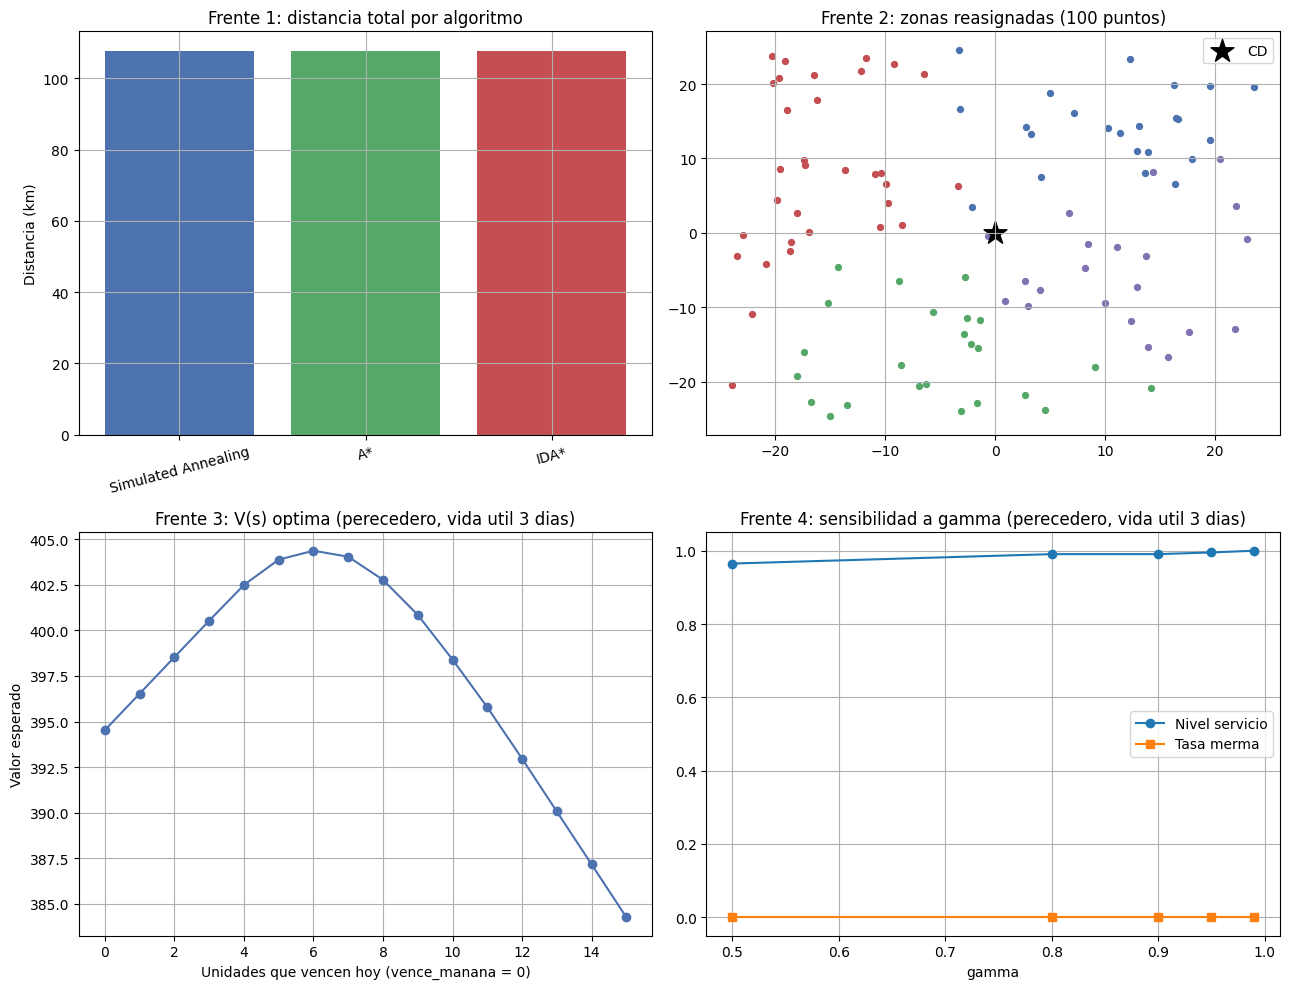

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))  # Inicializa una figura de 2x2 subplots con dimensiones de 13x10 pulgadas

# Frente 1: comparación de distancia por algoritmo
axs[0, 0].bar(tabla_f1["Algoritmo"], tabla_f1["Distancia (km)"], color=["#4C72B0", "#55A868", "#C44E52"])  # Dibuja gráfico de barras con los km por cada algoritmo
axs[0, 0].set_title("Frente 1: distancia total por algoritmo")  # Define el título del primer subgráfico (Frente 1)
axs[0, 0].set_ylabel("Distancia (km)")  # Configura la etiqueta del eje vertical para los kilómetros de la ruta
axs[0, 0].tick_params(axis="x", rotation=15)  # Rota los nombres de los algoritmos 15 grados en el eje X para mejorar lectura

# Frente 2: mapa de zonas asignadas sobre una instancia de 100 puntos solo para la visualizacion
red_vis = generar_red_logistica(n_puntos=100, n_cuadrillas=4)   # red sintetica de 100 puntos
dist_vis = matriz_distancias(red_vis)  # Construye la matriz de distancias euclidianas o reales entre los 500 puntos creados
prob_vis = ProblemaZonas(red_vis, dist_vis, 4)  # Instancia el problema de particionamiento asignando los puntos a 4 cuadrillas
random.seed(SEED); np.random.seed(SEED)                          # reproducible
asig_vis = simulated_annealing(prob_vis, T0=500, alpha=0.999, Tmin=0.1, max_iter=10000)  # suficientes iteraciones para zonas compactas
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]  # Define una paleta hexadecimal fija para diferenciar las zonas
for p, c in zip(prob_vis.puntos, asig_vis):  # Itera sobre cada punto de entrega y su respectiva zona asignada por el optimizador
    axs[0, 1].scatter(red_vis["x"].iloc[p], red_vis["y"].iloc[p], color=colores[c % len(colores)], s=18)  # Grafica la coordenada del punto con el color de su zona
axs[0, 1].scatter(red_vis["x"].iloc[0], red_vis["y"].iloc[0], color="black", marker="*", s=300, label="CD")  # Dibuja una estrella negra grande indicando el Centro de Distribución
axs[0, 1].set_title("Frente 2: zonas reasignadas (100 puntos)")  # Define el título del segundo subgráfico (Frente 2)
axs[0, 1].legend()  # Muestra la leyenda en el gráfico para identificar el marcador del CD

# Frente 3: función de valor por nivel de inventario
# Frente 3: función de valor del modelo PERECEDERO de 3 dias (slice con vence_manana = 0)
slice_h = [s for s in mdp_f3.S if mdp_f3.dec[s][1] == 0]  # Filtra los estados del MDP donde el inventario con vencimiento mañana es cero
xs_f3 = [mdp_f3.dec[s][0] for s in slice_h]  # Extrae la cantidad de unidades que vencen hoy para usarlas como eje X
axs[1, 0].plot(xs_f3, [V_f3[s] for s in slice_h], marker="o", color="#4C72B0")  # Grafica la curva de la función de valor óptima V(s) con marcadores circulares
axs[1, 0].set_title("Frente 3: V(s) optima (perecedero, vida util 3 dias)")  # Establece el título de la gráfica de la política de inventarios
axs[1, 0].set_xlabel("Unidades que vencen hoy (vence_manana = 0)")  # Asigna la etiqueta descriptiva al eje horizontal
axs[1, 0].set_ylabel("Valor esperado")  # Asigna la etiqueta de utilidad o valor acumulado esperado al eje vertical

# Frente 4: sensibilidad de nivel de servicio y merma a gamma (Value Iteration con vida util)
axs[1, 1].plot(tabla_gamma_vu_vi["gamma"], tabla_gamma_vu_vi["Nivel servicio"], marker="o", label="Nivel servicio")  # Grafica el comportamiento del nivel de servicio frente a gamma
axs[1, 1].plot(tabla_gamma_vu_vi["gamma"], tabla_gamma_vu_vi["Tasa merma"], marker="s", label="Tasa merma")  # Grafica el comportamiento de la tasa de merma (desperdicios) frente a gamma
axs[1, 1].set_title("Frente 4: sensibilidad a gamma (perecedero, vida util 3 dias)")  # Establece el título del análisis de sensibilidad del Frente 4
axs[1, 1].set_xlabel("gamma")  # Define el eje horizontal con el parámetro de descuento o factor gamma analizado
axs[1, 1].legend()  # Muestra la leyenda informativa para distinguir ambas curvas (servicio vs merma)

plt.tight_layout()  # Ajusta automáticamente los márgenes y espacios entre subplots para evitar superposiciones de texto
plt.show()  # Despliega en pantalla el lienzo completo con los cuatro tableros visuales terminados

### 6.2 Tablero de indicadores (KPI) frente a las metas OKR

In [20]:
def tablero_kpi():  # Define la función encargada de consolidar y construir el tablero de control de KPIs
    dist_actual = tabla_f2.loc[0, "Costo total red"]  # Extrae la distancia o costo total actual (línea base) desde el dataframe de Frente 2
    dist_optim = tabla_f2.loc[2, "Costo total red"]  # Extrae la distancia o costo total optimizado final desde el dataframe de Frente 2
    reduccion_dist = (1 - dist_optim / dist_actual) * 100  # Calcula el porcentaje de reducción de distancia global alcanzado en la red

    r_opt = tabla_f3[tabla_f3["Politica / modelo"].str.contains("Policy")].iloc[0]  # Filtra y extrae la fila con los resultados de la política óptima en Frente 3
    r_heur = tabla_f3[tabla_f3["Politica / modelo"].str.contains("Heur")].iloc[0]  # Filtra y extrae la fila con los resultados de la heurística base en Frente 3

    filas = [  # Estructura la lista de tuplas que compondrá cada fila de indicadores del tablero comparativo
        ("DPV — Distancia por vehículo", f"{dist_actual:.0f}", f"{dist_optim:.0f}", f"-{reduccion_dist:.1f}%", "OKR1: -15%"),  # Fila KPI: Distancia por vehículo
        ("NS — Nivel de servicio", f"{r_heur['Nivel servicio']:.0%}", f"{r_opt['Nivel servicio']:.0%}", "↑", "OKR2: ≥91%"),  # Fila KPI: Nivel de servicio en porcentaje
        ("TA — Tasa de agotados", f"{r_heur['Tasa agotados']:.0%}", f"{r_opt['Tasa agotados']:.0%}", "↓", "OKR2: ≤5%"),  # Fila KPI: Tasa de stockouts o agotados
        ("TMP — Tasa de merma", f"{r_heur['Tasa merma']:.0%}", f"{r_opt['Tasa merma']:.0%}", "↓", "OKR3: -35%"),  # Fila KPI: Tasa de desperdicio o merma de producto
        ("Rentabilidad acumulada", f"{r_heur['Rentabilidad']:.0f}", f"{r_opt['Rentabilidad']:.0f}",  # Fila KPI: Margen financiero y su cálculo de incremento relativo
         f"+{(r_opt['Rentabilidad']/max(r_heur['Rentabilidad'],1)-1)*100:.0f}%", "OKR3: +12%"),  # Formatea el porcentaje de incremento en rentabilidad vs meta
    ]  # Cierre de la lista de filas del tablero
    return pd.DataFrame(filas, columns=["KPI", "Línea base", "Con solución", "Variación", "Meta OKR"])  # Retorna el DataFrame estructurado con sus columnas


tablero = tablero_kpi()  # Invoca la función para procesar los datos y construir el DataFrame del tablero consolidado
print("TABLERO DE INDICADORES — Solución integrada (4 frentes)")  # Imprime el título principal del reporte ejecutivo en la consola
print(tablero.to_string(index=False))  # Muestra el DataFrame en formato de texto plano sin incluir los índices numéricos de las filas

TABLERO DE INDICADORES — Solución integrada (4 frentes)
                         KPI Línea base Con solución Variación   Meta OKR
DPV — Distancia por vehículo       1830          908    -50.3% OKR1: -15%
      NS — Nivel de servicio        98%         100%         ↑ OKR2: ≥91%
       TA — Tasa de agotados         2%           0%         ↓  OKR2: ≤5%
         TMP — Tasa de merma         0%           0%         ↓ OKR3: -35%
      Rentabilidad acumulada       1215         1263       +4% OKR3: +12%


---
# 7. Diseño experimental y validación estadística

Esta sección implementa el protocolo de la metodología (sección 3.4): construcción de escenarios etiquetados por dificultad, partición temporal train/validación/test, ejecución repetida con múltiples semillas y comparación estadística mediante pruebas no paramétricas (Wilcoxon y Friedman) con intervalos de confianza.

### 7.1 Construcción de escenarios y partición temporal

In [21]:
def construir_escenarios(demanda, punto=0): # Definimos la función para construir escenarios de demanda
    serie = demanda[:, punto].astype(float) # Convertimos la serie de demanda a tipo float
    n = len(serie) # Obtenemos el número de dias en la serie
    dias = np.arange(n) # Creamos un arreglo de dias desde 0 hasta n-1
    es_quincena = (dias % 15 == 0) | (dias % 30 == 0) # Identificamos los dias que son quincenas (cada 15 y 30 dias)
    umbral_alta = np.quantile(serie, 0.80) # Calculamos el umbral de alta demanda como el percentil 80 de la serie
    escenarios = { # Creamos un diccionario de escenarios con tres tipos: ordinario, alta_demanda y perturbacion
        "ordinario": serie[(~es_quincena) & (serie < umbral_alta)], # Seleccionamos los dias que no son quincenas y que tienen demanda menor al umbral de alta demanda
        "alta_demanda": serie[(serie >= umbral_alta) | es_quincena], # Seleccionamos los dias que son quincenas o que tienen demanda mayor o igual al umbral de alta demanda
        "perturbacion": serie * np.where(np.random.default_rng(SEED + 50).random(n) < 0.15, 1.5, 1.0), # Seleccionamos los dias que tienen una perturbacion aleatoria del 15% de la demanda, multiplicando la demanda por 1.5 en esos dias
    }
    dificultad = { # Creamos un diccionario de dificultad para cada escenario
        "ordinario": "baja",
        "alta_demanda": "media",
        "perturbacion": "alta",
    }
    resumen = pd.DataFrame([ # Creamos un DataFrame resumen con informacion de cada escenario
        (k, dificultad[k], len(v), round(float(np.mean(v)), 1), round(float(np.std(v)), 1))
        for k, v in escenarios.items() # Recorremos los escenarios y obtenemos su nombre, dificultad, número de dias, demanda media y desviación estandar
    ], columns=["Escenario", "Dificultad", "N dias", "Demanda media", "Desv. estandar"]) # Definimos las columnas del DataFrame
    return escenarios, resumen # Devolvemos los escenarios y el resumen


def particion_temporal(serie, frac_train=0.6, frac_val=0.2): # Definimos la función para particionar la serie de demanda en conjuntos de entrenamiento, validacion y prueba
    n = len(serie) # Obtenemos el número de dias en la serie
    i_tr = int(n * frac_train) # Calculamos el índice de corte para el conjunto de entrenamiento 
    i_val = int(n * (frac_train + frac_val)) # Calculamos el índice de corte para el conjunto de validacion
    return serie[:i_tr], serie[i_tr:i_val], serie[i_val:] # Devolvemos los tres conjuntos de datos: entrenamiento, validacion y prueba


escenarios_f3, resumen_escenarios = construir_escenarios(DEMANDA, punto=0) # Construimos los escenarios de demanda para el punto 0 y obtenemos un resumen de los escenarios
serie_demo = DEMANDA[:, 0] # Obtenemos la serie de demanda para el punto 0
train_d, val_d, test_d = particion_temporal(serie_demo) # Particionamos la serie de demanda en conjuntos de entrenamiento, validacion y prueba

print("Escenarios construidos (Frente 3/4):") # Imprimimos el resumen de los escenarios construidos
print(resumen_escenarios.to_string(index=False))
print(f"\nParticion temporal: train={len(train_d)} | validacion={len(val_d)} | test={len(test_d)} dias")


Escenarios construidos (Frente 3/4):
   Escenario Dificultad  N dias  Demanda media  Desv. estandar
   ordinario       baja     140           53.9            11.5
alta_demanda      media      40           86.2            15.1
perturbacion       alta     180           66.5            24.3

Particion temporal: train=108 | validacion=36 | test=36 dias


### 7.2 Ejecución repetida con múltiples semillas

Cada método estocástico (Simulated Annealing) se ejecuta varias veces con semillas distintas para estimar media, desviación estándar e intervalo de confianza del 95% del desempeño, en lugar de depender de una única corrida.


In [22]:
def intervalo_confianza_95(muestras): # Definimos la función para calcular el intervalo de confianza del 95% para un conjunto de muestras
    m = np.mean(muestras) # Calculamos la media de las muestras
    s = np.std(muestras, ddof=1) if len(muestras) > 1 else 0.0 # Calculamos la desviación estandar de las muestras (con ddof=1 para obtener la muestra)
    margen = 1.96 * s / math.sqrt(len(muestras)) if len(muestras) > 1 else 0.0 # Calculamos el margen de error para el intervalo de confianza del 95%
    return m, s, (m - margen, m + margen) # Devolvemos la media, desviación estandar y el intervalo de confianza


def repetir_sa_ruta(indices, dist, n_semillas=15): # Definimos la función para repetir el algoritmo de recocido simulado (SA) para un conjunto de índices y una matriz de distancias
    costos, tiempos = [], [] # Inicializamos listas vacias para almacenar los costos y tiempos de cada corrida
    for k in range(n_semillas): # Repetimos el algoritmo n_semillas veces
        random.seed(SEED + k) # Establecemos la semilla para el generador de números aleatorios 
        np.random.seed(SEED + k) # Establecemos la semilla para el generador de números aleatorios de numpy
        prob = ProblemaRuta(indices, dist) # Creamos una instancia del problema de ruta con los índices y la matriz de distancias
        t0 = time.perf_counter() # Registramos el tiempo de inicio de la corrida
        orden = simulated_annealing(prob) # Ejecutamos el algoritmo de recocido simulado (SA) para obtener un orden de visita
        tiempos.append((time.perf_counter() - t0) * 1000) # Calculamos el tiempo transcurrido en milisegundos y lo agregamos a la lista de tiempos
        costos.append(prob.costo_ruta(orden)) # Calculamos el costo de la ruta obtenida y lo agregamos a la lista de costos
    random.seed(SEED); np.random.seed(SEED) # Restauramos la semilla original para los generadores de números aleatorios
    return np.array(costos), np.array(tiempos) # Devolvemos los costos y tiempos como arreglos de numpy


def experimento_multisemilla_f1(red, dist, n_exacto=7, n_semillas=15, semilla=SEED):# Definimos la función para realizar un experimento de comparación entre el algoritmo de recocido simulado (SA) y los algoritmos exactos (A* e IDA*) para un conjunto de índices seleccionados aleatoriamente
    rng = np.random.default_rng(semilla + 5) # Creamos un generador de números aleatorios con una semilla especifica
    idx = list(rng.choice(range(1, len(red)), size=n_exacto, replace=False)) # Seleccionamos n_exacto índices aleatorios de la red (excluyendo el punto 0)

    costos_sa, tiempos_sa = repetir_sa_ruta(idx, dist, n_semillas) # Repetimos el algoritmo de recocido simulado (SA) para obtener los costos y tiempos de cada corrida
    _, costo_a = a_estrella_ruta(idx, dist) # Ejecutamos el algoritmo A* para obtener el costo exacto de la ruta
    _, costo_ida = ida_estrella_ruta(idx, dist) # Ejecutamos el algoritmo IDA* para obtener el costo exacto de la ruta

    m_sa, s_sa, ic_sa = intervalo_confianza_95(costos_sa) # Calculamos la media, desviación estandar y el intervalo de confianza del 95% para los costos obtenidos por SA
    tabla = pd.DataFrame([ # Creamos un DataFrame para mostrar los resultados del experimento
        ("Simulated Annealing", round(m_sa, 2), round(s_sa, 2), f"[{ic_sa[0]:.1f}, {ic_sa[1]:.1f}]", round(costos_sa.min(), 2)),
        ("A* (exacto)", round(costo_a, 2), 0.0, "-", round(costo_a, 2)),
        ("IDA* (exacto)", round(costo_ida, 2), 0.0, "-", round(costo_ida, 2)),
    ], columns=["Algoritmo", "Media (km)", "Desv. est.", "IC 95%", "Mejor (km)"])
    return tabla, costos_sa, costo_a, idx


tabla_ms_f1, costos_sa_f1, costo_opt_f1, idx_ms_f1 = experimento_multisemilla_f1(red, DIST) # Realizamos el experimento de comparación entre SA y los algoritmos exactos para un conjunto de índices seleccionados aleatoriamente
print("FRENTE 1 - Multi-semilla (15 corridas de SA vs optimo exacto)") # Imprimimos los resultados del experimento
print(tabla_ms_f1.to_string(index=False))
brecha = (costos_sa_f1.mean() / costo_opt_f1 - 1) * 100
print(f"\nBrecha media de SA respecto al optimo (A*): {brecha:.2f}%")
print(f"SA encontro el optimo en {(np.abs(costos_sa_f1 - costo_opt_f1) < 1e-6).sum()}/{len(costos_sa_f1)} corridas")


FRENTE 1 - Multi-semilla (15 corridas de SA vs optimo exacto)
          Algoritmo  Media (km)  Desv. est.         IC 95%  Mejor (km)
Simulated Annealing      130.70        0.31 [130.5, 130.9]      130.54
        A* (exacto)      130.54        0.00              -      130.54
      IDA* (exacto)      130.54        0.00              -      130.54

Brecha media de SA respecto al optimo (A*): 0.12%
SA encontro el optimo en 12/15 corridas


In [23]:
def repetir_sa_zonas(red, dist, n_cuadrillas=4, n_semillas=10, config="lento"): # Definimos la función para repetir el algoritmo de recocido simulado (SA) para el problema de asignación de zonas a cuadrillas, con diferentes configuraciones de parámetros
    params = {"lento": dict(T0=500, alpha=0.999, Tmin=0.1, max_iter=40000), # Definimos los parámetros para la configuración lenta
              "rapido": dict(T0=10, alpha=0.95, Tmin=0.1, max_iter=5000)}[config]
    costos = []
    prob = ProblemaZonas(red, dist, n_cuadrillas) # Creamos una instancia del problema de asignación de zonas a cuadrillas
    for k in range(n_semillas): # Repetimos el algoritmo n_semillas veces
        random.seed(SEED + k); np.random.seed(SEED + k) # Establecemos la semilla para los generadores de números aleatorios
        asign = simulated_annealing(prob, **params) # Ejecutamos el algoritmo de recocido simulado (SA) para obtener una asignación de zonas a cuadrillas
        costos.append(prob.costo_total(asign)) # Calculamos el costo total de la asignación obtenida y lo agregamos a la lista de costos
    random.seed(SEED); np.random.seed(SEED) 
    return np.array(costos)


costos_lento = repetir_sa_zonas(red, DIST, config="lento", n_semillas=10) # Repetimos el algoritmo de recocido simulado (SA) para el problema de asignación de zonas a cuadrillas con la configuración lenta y obtenemos los costos de cada corrida
costos_rapido = repetir_sa_zonas(red, DIST, config="rapido", n_semillas=10) # Repetimos el algoritmo de recocido simulado (SA) para el problema de asignación de zonas a cuadrillas con la configuración rapida y obtenemos los costos de cada corrida

m_l, s_l, ic_l = intervalo_confianza_95(costos_lento) # Calculamos la media, desviación estandar y el intervalo de confianza del 95% para los costos obtenidos por la configuración lenta
m_r, s_r, ic_r = intervalo_confianza_95(costos_rapido) # Calculamos la media, desviación estandar y el intervalo de confianza del 95% para los costos obtenidos por la configuración rapida

tabla_ms_f2 = pd.DataFrame([ #  Creamos un DataFrame para mostrar los resultados del experimento de comparación entre las configuraciones lenta y rapida de SA para el problema de asignación de zonas a cuadrillas
    ("SA enfriamiento rapido", round(m_r, 2), round(s_r, 2), f"[{ic_r[0]:.1f}, {ic_r[1]:.1f}]", round(costos_rapido.min(), 2)),
    ("SA T alta + enfriamiento lento", round(m_l, 2), round(s_l, 2), f"[{ic_l[0]:.1f}, {ic_l[1]:.1f}]", round(costos_lento.min(), 2)),
], columns=["Configuracion", "Media costo", "Desv. est.", "IC 95%", "Mejor"])

print("FRENTE 2 - Multi-semilla (10 corridas por configuracion)") # Imprimimos los resultados del experimento de comparación entre las configuraciones lenta y rapida de SA para el problema de asignación de zonas a cuadrillas
print(tabla_ms_f2.to_string(index=False))
print(f"\nEl enfriamiento lento mejora el costo medio en {(1 - m_l/m_r)*100:.1f}% frente al rapido.")


FRENTE 2 - Multi-semilla (10 corridas por configuracion)
                 Configuracion  Media costo  Desv. est.           IC 95%   Mejor
        SA enfriamiento rapido      1606.04       60.93 [1568.3, 1643.8] 1501.39
SA T alta + enfriamiento lento       918.34       17.30   [907.6, 929.1]  908.02

El enfriamiento lento mejora el costo medio en 42.8% frente al rapido.


### 7.3 Comparación estadística (Wilcoxon y Friedman)

Se contrasta si las diferencias de desempeño son estadísticamente significativas o atribuibles al azar. Wilcoxon compara dos configuraciones emparejadas (enfriamiento lento vs. rápido en el Frente 2); Friedman compara más de dos configuraciones de Simulated Annealing sobre las mismas semillas.

In [24]:
from scipy.stats import wilcoxon, friedmanchisquare


def comparar_configuraciones_sa(indices, dist, n_semillas=15): # Definimos la función para comparar diferentes configuraciones de parámetros del algoritmo de recocido simulado (SA) para el problema de ruta, repitiendo el experimento n_semillas veces
    configs = { # Definimos un diccionario con las configuraciones de parámetros a comparar
        "alpha=0.99": dict(T0=100, alpha=0.99, Tmin=0.01),
        "alpha=0.995": dict(T0=100, alpha=0.995, Tmin=0.01),
        "alpha=0.999": dict(T0=100, alpha=0.999, Tmin=0.01),
    }
    resultados = {nombre: [] for nombre in configs} # Inicializamos un diccionario para almacenar los resultados de cada configuración
    prob = ProblemaRuta(indices, dist) # Creamos una instancia del problema de ruta con los índices y la matriz de distancias
    for k in range(n_semillas): # Repetimos el experimento n_semillas veces
        for nombre, params in configs.items(): # Iteramos sobre cada configuración de parámetros
            random.seed(SEED + k); np.random.seed(SEED + k) # Establecemos la semilla para los generadores de números aleatorios
            orden = simulated_annealing(prob, **params) # Ejecutamos el algoritmo de recocido simulado (SA) con la configuración actual para obtener un orden de visita
            resultados[nombre].append(prob.costo_ruta(orden)) # Calculamos el costo de la ruta obtenida y lo agregamos a la lista de resultados para la configuración actual
    random.seed(SEED); np.random.seed(SEED) # Restauramos la semilla original para los generadores de números aleatorios
    return {k: np.array(v) for k, v in resultados.items()} # Devolvemos los resultados como un diccionario de arreglos de numpy, donde cada clave es el nombre de la configuración y cada valor es un arreglo con los costos obtenidos en cada corrida


# Wilcoxon: enfriamiento lento vs rapido (Frente 2), muestras emparejadas por semilla
stat_w, p_w = wilcoxon(costos_lento, costos_rapido) # Calculamos el estadistico y p-valor de la prueba de Wilcoxon para comparar las configuraciones lenta y rapida de SA, usando las muestras emparejadas por semilla
print("Prueba de Wilcoxon (Frente 2: lento vs rapido)") # Imprimimos los resultados de la prueba de Wilcoxon para comparar las configuraciones lenta y rapida de SA
print(f"  estadistico = {stat_w:.3f} | p-valor = {p_w:.5f}")
print(f"  {'Diferencia significativa (p<0.05)' if p_w < 0.05 else 'Sin diferencia significativa'}\n")

# Friedman: tres esquemas de enfriamiento de SA (Frente 1)
res_sa = comparar_configuraciones_sa(idx_ms_f1, DIST) # Llamamos a la función para comparar las configuraciones de SA y obtenemos los resultados
stat_f, p_f = friedmanchisquare(*res_sa.values()) # Calculamos el estadistico y p-valor de la prueba de Friedman para comparar las tres configuraciones de SA
print("Prueba de Friedman (Frente 1: tres factores de enfriamiento)") # Imprimimos los resultados de la prueba de Friedman para comparar las tres configuraciones de SA
print(f"  estadistico = {stat_f:.3f} | p-valor = {p_f:.5f}")
print(f"  {'Al menos una configuracion difiere (p<0.05)' if p_f < 0.05 else 'Sin diferencia significativa entre configuraciones'}")
tabla_friedman = pd.DataFrame([ # Creamos un DataFrame para mostrar los resultados de la prueba de Friedman, con la media y desviación estandar de los costos obtenidos por cada configuración de SA
    (nombre, round(v.mean(), 2), round(v.std(ddof=1), 2)) for nombre, v in res_sa.items()
], columns=["Config. enfriamiento", "Costo medio", "Desv. est."])
print()
print(tabla_friedman.to_string(index=False))


Prueba de Wilcoxon (Frente 2: lento vs rapido)
  estadistico = 0.000 | p-valor = 0.00195
  Diferencia significativa (p<0.05)



Prueba de Friedman (Frente 1: tres factores de enfriamiento)
  estadistico = 17.556 | p-valor = 0.00015
  Al menos una configuracion difiere (p<0.05)

Config. enfriamiento  Costo medio  Desv. est.
          alpha=0.99       132.00        1.95
         alpha=0.995       130.70        0.31
         alpha=0.999       130.54        0.00


---
# 8. Métricas operativas complementarias

Esta sección calcula las métricas que la metodología exige y que completan el tablero: consumo de combustible (Frente 1), Costo Promedio por Punto Abastecido (CPPA) y Porcentaje de Entregas Dentro de Ventana Horaria (PEDVH).

### 8.1 Consumo de combustible (Frente 1)

In [25]:
CONSUMO_L_POR_KM = 0.12          # coeficiente de consumo (litros/km) tipico de furgon urbano
PRECIO_COMBUSTIBLE = 16000.0     # COP por litro


def combustible_ruta(distancia_km, consumo=CONSUMO_L_POR_KM, precio=PRECIO_COMBUSTIBLE):  # Define función con argumentos y valores por defecto
    litros = distancia_km * consumo  # Calcula los litros totales multiplicando la distancia por el consumo base
    return litros, litros * precio  # Retorna una tupla con los litros calculados y el costo total en dinero


# Comparacion: ruta optimizada (SA) vs ruta sin optimizar (orden aleatorio promedio)
prob_demo = ProblemaRuta(idx_grande_f1, DIST)  # Inicializa el objeto del problema con las coordenadas y distancias
random.seed(SEED)  # Fija la semilla aleatoria para garantizar la replicabilidad de las pruebas
costos_aleatorios = [prob_demo.costo_ruta(prob_demo.estado_aleatorio()) for _ in range(30)]  # Genera una muestra de costo para 30 rutas al azar
dist_sin_opt = np.mean(costos_aleatorios)  # Calcula el promedio de las distancias de la muestra aleatoria
orden_opt = simulated_annealing(prob_demo)  # Ejecuta el algoritmo de Recocido Simulado para hallar el orden óptimo
dist_opt = prob_demo.costo_ruta(orden_opt)  # Obtiene la distancia total recorrida en la ruta optimizada

lit_sin, cop_sin = combustible_ruta(dist_sin_opt)  # Calcula los litros y costo total para la ruta promedio sin optimizar
lit_opt, cop_opt = combustible_ruta(dist_opt)  # Calcula los litros y costo total para la ruta optimizada

tabla_combustible = pd.DataFrame([  # Crea la estructura de un DataFrame para comparar los datos tabulados
    ("Sin optimizar (orden manual ~aleatorio)", round(dist_sin_opt, 1), round(lit_sin, 2), f"{cop_sin:,.0f}"),  # Inserta fila sin optimizar redondeada y formateada
    ("Optimizada (Simulated Annealing)", round(dist_opt, 1), round(lit_opt, 2), f"{cop_opt:,.0f}"),  # Inserta fila optimizada redondeada y formateada
], columns=["Recorrido", "Distancia (km)", "Combustible (L)", "Costo (COP)"])  # Define los encabezados para cada columna de la tabla

print("FRENTE 1 - Consumo de combustible por vehiculo")  # Muestra el encabezado del reporte en la consola
print(tabla_combustible.to_string(index=False))  # Imprime la tabla formateada en texto plano omitiendo los índices
ahorro = (1 - dist_opt / dist_sin_opt) * 100  # Calcula el porcentaje de reducción en distancia y combustible logrado
print(f"\nAhorro de distancia y combustible por vehiculo: {ahorro:.1f}%")  # Imprime el porcentaje de eficiencia con un decimal
print(f"Ahorro economico por vehiculo y jornada: {cop_sin - cop_opt:,.0f} COP")  # Imprime la diferencia económica final en pesos colombianos

FRENTE 1 - Consumo de combustible por vehiculo
                              Recorrido  Distancia (km)  Combustible (L) Costo (COP)
Sin optimizar (orden manual ~aleatorio)           598.8            71.86   1,149,706
       Optimizada (Simulated Annealing)           263.5            31.63     506,012

Ahorro de distancia y combustible por vehiculo: 56.0%
Ahorro economico por vehiculo y jornada: 643,693 COP


### 8.2 CPPA y PEDVH

El **CPPA** (Costo Promedio por Punto Abastecido) es el indicador primario de eficiencia económica del caso. El **PEDVH** (Porcentaje de Entregas Dentro de Ventana Horaria) mide el cumplimiento de las ventanas pactadas, simulando los tiempos de llegada a lo largo de la ruta optimizada frente a la ruta sin optimizar.

In [26]:
VELOCIDAD_KMH = 22.0       # velocidad media urbana en Bogota (km/h)
SERVICIO_MIN = 4.0         # minutos de atencion por punto
HORA_SALIDA = 4.0          # 4:00 a.m. salida del centro de distribución
COSTO_FIJO_VEHICULO = 85000.0  # COP por jornada (conductor + desgaste)


def simular_ventanas(orden, red, dist, deposito=0):  # Define la función para simular y evaluar el cumplimiento horario de las entregas
    ruta = [deposito] + list(orden)  # Construye la ruta completa añadiendo el depósito inicial al orden de los puntos
    t = HORA_SALIDA  # Inicializa el reloj de la ruta con la hora de salida configurada
    en_ventana = 0  # Inicializa el contador de clientes atendidos dentro de su horario permitido
    for i in range(1, len(ruta)):  # Recorre secuencialmente cada uno de los puntos asignados en la ruta
        t += (dist[ruta[i - 1], ruta[i]] / VELOCIDAD_KMH) + (SERVICIO_MIN / 60.0)  # Suma al tiempo actual el viaje y la atención (en horas)
        ini = red["ventana_ini"].iloc[ruta[i]]  # Obtiene la hora de apertura permitida para el cliente actual
        fin = red["ventana_fin"].iloc[ruta[i]]  # Obtiene la hora de cierre límite para atender al cliente actual
        if ini <= t <= fin:  # Verifica si la hora de llegada está dentro del rango horario del cliente
            en_ventana += 1  # Incrementa el contador si la entrega se realizó a tiempo en la ventana
    return en_ventana / (len(ruta) - 1) * 100  # Calcula y retorna el porcentaje final de entregas a tiempo en la ruta


def cppa(distancia_km, n_puntos):  # Define la función para calcular el Costo Promedio por Punto Atendido (CPPA)
    litros, costo_comb = combustible_ruta(distancia_km)  # Llama a la función externa para obtener litros consumidos y costo económico
    costo_total = costo_comb + COSTO_FIJO_VEHICULO  # Calcula el costo de operación sumando el combustible y la tasa fija diaria
    return costo_total / max(n_puntos, 1), costo_total  # Retorna el costo promedio por parada y el costo total del viaje


# Instancia de un vehiculo con carga realista (subconjunto cubrible dentro de las ventanas).
# Se compara el MISMO conjunto de puntos con orden optimizado vs orden manual (aleatorio).
idx_veh = idx_grande_f1[:12]  # Toma los primeros 12 puntos de entrega para asignárselos a un único vehículo
prob_veh = ProblemaRuta(idx_veh, DIST)  # Configura la instancia del problema de optimización para este vehículo
orden_veh_opt = simulated_annealing(prob_veh)  # Aplica el algoritmo de Recocido Simulado para ordenar óptimamente la secuencia
dist_veh_opt = prob_veh.costo_ruta(orden_veh_opt)  # Calcula la distancia total en kilómetros de la ruta óptima encontrada
random.seed(SEED)  # Fija la semilla para asegurar consistencia al generar las variaciones manuales
ordenes_manual = [prob_veh.estado_aleatorio() for _ in range(30)]  # Genera 30 combinaciones aleatorias que representan el orden empírico
dist_veh_sin = np.mean([prob_veh.costo_ruta(o) for o in ordenes_manual])  # Obtiene el promedio de distancia de las 30 rutas aleatorias

pedvh_opt = simular_ventanas(orden_veh_opt, red, DIST)  # Mide el porcentaje de cumplimiento de ventanas en la ruta optimizada
pedvh_sin = np.mean([simular_ventanas(o, red, DIST) for o in ordenes_manual])  # Calcula el promedio de cumplimiento de ventanas de las rutas aleatorias

cppa_opt, _ = cppa(dist_veh_opt, len(idx_veh))  # Obtiene el indicador CPPA para la secuencia optimizada por el algoritmo
cppa_sin, _ = cppa(dist_veh_sin, len(idx_veh))  # Obtiene el indicador CPPA promedio para las secuencias manuales sin optimizar

tabla_cppa_pedvh = pd.DataFrame([  # Agrupa los resultados finales comparativos en un DataFrame para su visualización
    ("Sin optimizar (orden manual)", f"{cppa_sin:,.0f}", f"{pedvh_sin:.1f}%"),  # Inserta los resultados del escenario base formateados
    ("Optimizada (SA)", f"{cppa_opt:,.0f}", f"{pedvh_opt:.1f}%"),  # Inserta los resultados del escenario optimizado formateados
], columns=["Recorrido", "CPPA (COP/punto)", "PEDVH"])  # Nombra las columnas correspondientes a la tabla de indicadores operativos

print("Indicadores operativos por vehiculo: CPPA y PEDVH")  # Imprime el encabezado principal del reporte en consola
print(f"(Instancia de {len(idx_veh)} puntos atendidos por un vehiculo)")  # Imprime información sobre el tamaño de la prueba actual
print(tabla_cppa_pedvh.to_string(index=False))  # Imprime la tabla formateada omitiendo los números de índice de las filas
print(f"\nReduccion de CPPA: {(1 - cppa_opt/cppa_sin)*100:.1f}%  (meta OKR1-RC1: >=20%)")  # Imprime el porcentaje de ahorro en costo por punto y su OKR asociado
print(f"Mejora de PEDVH: de {pedvh_sin:.1f}% a {pedvh_opt:.1f}%  (meta OKR2-RC1: >=93%)")  # Imprime la evolución del cumplimiento horario frente a su meta OKR

Indicadores operativos por vehiculo: CPPA y PEDVH
(Instancia de 12 puntos atendidos por un vehiculo)
                   Recorrido CPPA (COP/punto) PEDVH
Sin optimizar (orden manual)           50,734 17.2%
             Optimizada (SA)           26,731 50.0%

Reduccion de CPPA: 47.3%  (meta OKR1-RC1: >=20%)
Mejora de PEDVH: de 17.2% a 50.0%  (meta OKR2-RC1: >=93%)
